# Choices13k: Predicting Choice Behavior in Risky Gambles

## Introduction

This notebook analyzes the [**Choices13k**](https://github.com/jcpeterson/choices13k) dataset, which contains human choices between pairs of lotteries (gambles) with feedback. The goal is to predict the **choice rate** (`bRate`: proportion of times option B was chosen) from problem and gamble features, using the problem definitions in `c13k_problems.json` and the selection data in `c13k_selections.csv`.

The analysis proceeds as follows:

1. **Data fetching and loading** — Download or load the selections CSV and problems JSON from the Choices13k repository, then merge them into a single dataframe.
2. **Data quality** — Check for duplicate problems and inspect feedback patterns.
3. **Exploratory data analysis** — Summarize the merged data, inspect the target (`bRate`), and examine correlations with the target.
4. **Feature engineering** — Derive numeric features from the gamble structure (e.g. expected value, standard deviation, extreme outcomes).
5. **Modeling** — Train and compare multiple regressors (Ridge, Random Forest, SVR, Gradient Boosting, XGBoost, LightGBM, etc.) and Neural Networks with hyperparameter search and evaluate on held-out test data.

We first have to download the required packages

In [1]:
# Run this cell once to install dependencies (works on both Colab and local Jupyter).
# Uncomment the line below, run the cell, then you can comment it again to avoid reinstalling every time.
%pip install numpy pandas matplotlib seaborn scikit-learn scipy requests optuna torch xgboost lightgbm shap

In [2]:
# --- Standard library ---
import ast
import json
import os
from urllib.parse import urlparse
from dataclasses import dataclass
from typing import Any, Dict, Optional

# --- Third-party ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import requests
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import true_divide
from torch.utils.data import DataLoader, TensorDataset, Dataset
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from scipy.stats import probplot
from IPython.display import display

# --- sklearn ---
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve,
    train_test_split,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [3]:
# Reproducibility: set seed once at the start
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## 1. Fetching the data

We download the selections and problem files from the Choices13k repository if they are not already present locally.


In [4]:
def download_file(url, save_path=None):
    try:
        response = requests.get(url, stream=True, timeout=15)
        response.raise_for_status()

        if save_path is None:
            filename = os.path.basename(urlparse(url).path) or "downloaded_file"
            save_path = os.path.join(os.getcwd(), filename)

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        downloaded_size = 0
        with open(save_path, 'wb') as file:
            for data in response.iter_content(block_size):
                file.write(data)


        print(f"\nDownload complete: {save_path}")

    except requests.exceptions.MissingSchema:
        print("Invalid URL format.")
    except requests.exceptions.ConnectionError:
        print("Connection error. Check your internet connection.")
    except requests.exceptions.Timeout:
        print("Request timed out.")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


We download the 2 files. `c13k_problems.json` contains the problem descriptions and `c13k_selections.csv` contains additional info about the gambles and the target variable,`brate`.

In [5]:
BASE_URL = 'https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main'

csv_url = f'{BASE_URL}/c13k_selections.csv'
json_url = f'{BASE_URL}/c13k_problems.json'

if not os.path.exists('c13k_selections.csv'):
    download_file(csv_url)
if not os.path.exists('c13k_problems.json'):
    download_file(json_url)

We then validate that the json is correct.

In [6]:
def validate_json_file(path: str) -> bool:
    try:
        with open(path, "r", encoding="utf-8") as f:
            json.load(f)
        print("JSON is valid")
        return True
    except json.JSONDecodeError as e:
        print("Invalid JSON:", e)
        return False

validate_json_file("c13k_problems.json")


JSON is valid


True

### 1.1 Loading and merging the data

We load the selections CSV and the problems JSON, then join them on the problem identifier to obtain a single dataframe with both choice outcomes and gamble structure.

In [7]:
df = pd.read_csv('c13k_selections.csv')
df.head()
df.isnull().sum()

,0
Problem,0
Feedback,0
n,0
Block,0
Ha,0
pHa,0
La,0
Hb,0
pHb,0
Lb,0


In [8]:
len(df)

14568

In [9]:
problems = pd.read_json("c13k_problems.json", orient='index')
problems

,B,A
0,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...
14563,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


In [10]:
selections = pd.read_csv('c13k_selections.csv')

with pd.option_context('display.max_columns', None):
    display(selections)

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476


In [11]:
selections.columns = [col.lower() for col in selections.columns]

In [12]:
df_full = selections.join(problems, how='left')

In [13]:
with pd.option_context('display.max_columns', None):
    display(df_full)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


### Column descriptions

| Column | Type | Description |
|--------|------|-------------|
| **problem** | Integer | A unique internal problem ID. |
| **n** | Integer | The number of subjects run on the current problem. |
| **feedback** | Boolean | Whether the participants were given feedback about the reward they received and missed out on after making their selection. |
| **brate** | Float | **Target.** The frequency with which subjects selected Gamble B on the current problem. |
| **ha** | Integer | The first outcome of gamble A. |
| **pha** | Float | The probability of Ha in gamble A. |
| **la** | Integer | The second outcome of gamble A (occurs with probability 1−pHa). |
| **hb** | Integer | The expected value of the lottery in gamble B. |
| **phb** | Float | The probability of the lottery in gamble B. |
| **lb** | Float | The non-lottery outcome in gamble B (occurs with probability 1−pHb). |
| **lotshapeb** | {0, 1, 2, 3} | Shape of the lottery distribution for gamble B: 1 = symmetric around its mean, 2 = right-skewed, 3 = left-skewed, 0 = undefined (e.g. if LotNumB = 1). |
| **lotnumb** | Integer | The number of possible outcomes in the gamble B lottery. |
| **amb** | Boolean | Whether the decision maker could see the probabilities of the outcomes in Gamble B. 1 = no information (ambiguity), 0 = complete information. |
| **corr** | {-1, 0, 1} | Whether there is a correlation (negative, zero, or positive) between the payoffs of the two gambles. |
| **block** | {1, 2, 3, 4, 5} | The block ID for the current problem. For no feedback, Block is always 1; otherwise sampled uniformly from {2, 3, 4, 5}. |
| **brate_std** | Float | Empirical standard deviation of the choice proportion (not in official schema). |
| **A** | list | Full gamble A: list of `[outcome, probability]` pairs (from problems JSON). |
| **B** | list | Full gamble B: list of `[outcome, probability]` pairs (from problems JSON). |

We now have a unified dataset containing both the gambles descriptions and the choices.

## 2. Data quality and duplicates

We check for duplicate problem IDs.

In [14]:
counts = df_full.groupby('problem').size().reset_index(name='count').sort_values(by="count", ascending=False)

In [15]:
idx = counts.loc[counts["count"] > 1, "problem"].tolist()


In [16]:
df_full.loc[df_full['problem'].isin(idx),:]

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.866667,0.351866,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.962500,0.150000,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
8,8,False,15,1,27,1.00,27,89,0.50,-24,0,1,False,0,0.453333,0.403320,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
9,8,True,16,2,27,1.00,27,89,0.50,-24,0,1,False,0,0.612500,0.434933,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
11,10,False,15,1,1,1.00,1,59,0.05,0,0,1,True,0,0.773333,0.406143,"[[0.9500000000000001, 0.0], [0.05, 59.0]]","[[1.0, 1.0], [0.0, 1.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8293,6734,True,18,5,77,0.01,30,116,0.40,-12,2,5,True,0,0.688889,0.292834,"[[0.6000000000000001, -12.0], [0.2, 112.0], [0...","[[0.01, 77.0], [0.99, 30.0]]"
8296,6737,False,16,1,26,1.00,26,41,0.60,7,0,1,False,0,0.450000,0.287518,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8297,6737,True,16,3,26,1.00,26,41,0.60,7,0,1,False,0,0.600000,0.309839,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8299,6739,False,16,1,-1,0.95,-4,10,0.75,-17,2,3,False,0,0.787500,0.247319,"[[0.25, -17.0], [0.375, 8.0], [0.1875, 10.0], ...","[[0.9500000000000001, -1.0], [0.05, -4.0]]"


We can see that while the dataset reports 13,006 risky choice problems, our dataset has 3,124 additional rows.

In [17]:
df_full['feedback'].value_counts()

,count
feedback,
True,12188
False,2380


In [18]:
count = (
    df_full
    .groupby("problem")["feedback"]
    .nunique()
    .eq(2)
    .sum()
)

print(count)


1562


The reason behind the duplicate problem ids, is that in some cases the subjects were given feedback before their decision and therefore, one row is for subjects with feedback and one for subjects without feedback.

## 3. Exploratory data analysis

We first need to investigate the dataset, inspect the target variable `bRate`, and the correlations of the features with `bRate`.

### 3.1 Basic exploration

We inspect the merged dataset to detect missing values.

In [19]:
# Basic exploration of the dataset

print("First 5 rows of df:")
display(df_full.head())

# Summary statistics (numeric and categorical)
print("\nSummary statistics:")
display(df_full.describe(include="all").T)

# Missing values per column
print("\nMissing values per column:")
print(df_full.isnull().sum())



First 5 rows of df:


,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
problem,14568.0,NaN,NaN,NaN,6163.333677,3733.123605,1.0,2961.75,5888.5,9364.25,13006.0
feedback,14568,2,True,12188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,14568.0,NaN,NaN,NaN,16.670717,2.588231,15.0,16.0,16.0,17.0,33.0
block,14568.0,NaN,NaN,NaN,3.099053,1.379569,1.0,2.0,3.0,4.0,5.0
ha,14568.0,NaN,NaN,NaN,22.014072,24.076396,-10.0,5.0,18.0,29.0,118.0
pha,14568.0,NaN,NaN,NaN,0.747192,0.351998,0.01,0.5,1.0,1.0,1.0
la,14568.0,NaN,NaN,NaN,3.813152,16.406765,-50.0,-6.0,5.0,17.0,30.0
hb,14568.0,NaN,NaN,NaN,35.583677,27.659754,-18.0,15.0,30.0,52.0,119.0
phb,14568.0,NaN,NaN,NaN,0.444946,0.325977,0.01,0.2,0.4,0.75,1.0
lb,14568.0,NaN,NaN,NaN,-4.147721,18.270573,-50.0,-16.0,-3.0,9.0,41.0



Missing values per column:
problem      0
feedback     0
n            0
block        0
ha           0
pha          0
la           0
hb           0
phb          0
lb           0
lotshapeb    0
lotnumb      0
amb          0
corr         0
brate        0
brate_std    0
B            0
A            0
dtype: int64


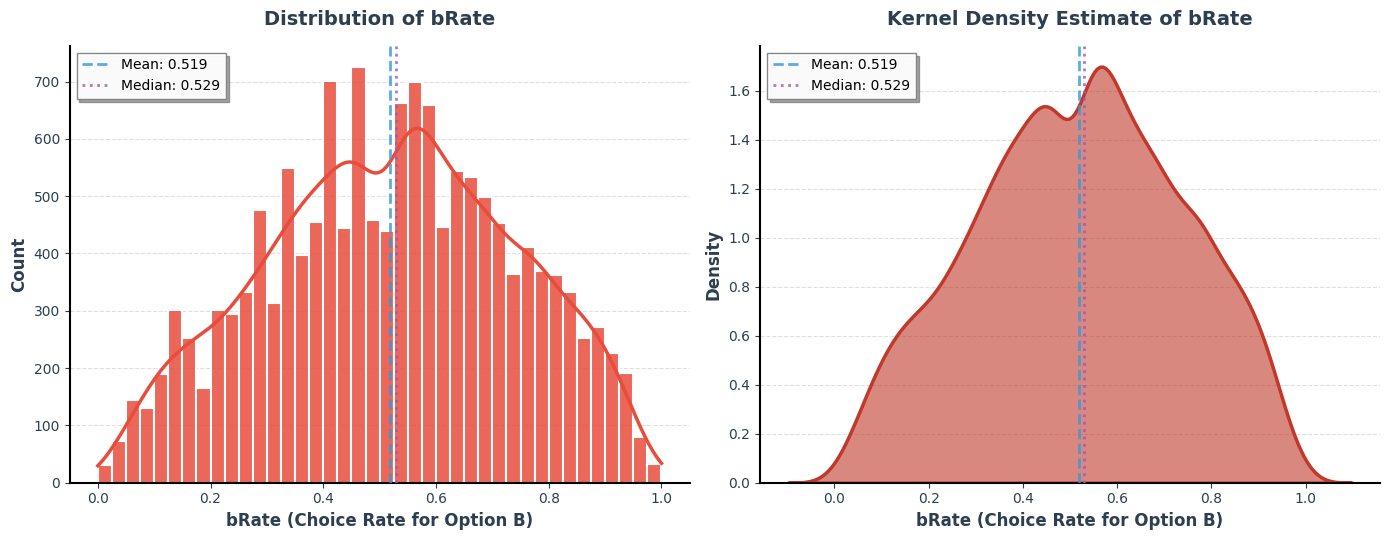

In [20]:
# Distribution of target variable bRate
ffig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='white')

hist_color = '#e74c3c'
kde_line_color = '#c0392b'
mean_color = '#3498db'
median_color = '#9b59b6'

sns.histplot(
    df_full["brate"],
    bins=40,
    kde=True,
    color=hist_color,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.85,
    line_kws={'linewidth': 2.5, 'color': kde_line_color},
    ax=axes[0]
)
axes[0].set_xlabel('bRate (Choice Rate for Option B)', fontsize=12, fontweight='bold', color='#2c3e50')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold', color='#2c3e50')
axes[0].set_title('Distribution of bRate', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
axes[0].grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.8, color='gray')
axes[0].set_axisbelow(True)
axes[0].set_facecolor('white')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_linewidth(1.5)
axes[0].spines['bottom'].set_linewidth(1.5)
axes[0].spines['left'].set_color('black')
axes[0].spines['bottom'].set_color('black')

sns.kdeplot(
    df_full["brate"],
    color=kde_line_color,
    fill=True,
    alpha=0.6,
    linewidth=2.5,
    ax=axes[1]
)
axes[1].set_xlabel('bRate (Choice Rate for Option B)', fontsize=12, fontweight='bold', color='#2c3e50')
axes[1].set_ylabel('Density', fontsize=12, fontweight='bold', color='#2c3e50')
axes[1].set_title('Kernel Density Estimate of bRate', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
axes[1].grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.8, color='gray')
axes[1].set_axisbelow(True)
axes[1].set_facecolor('white')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_linewidth(1.5)
axes[1].spines['bottom'].set_linewidth(1.5)
axes[1].spines['left'].set_color('black')
axes[1].spines['bottom'].set_color('black')

mean_val = df_full["brate"].mean()
median_val = df_full["brate"].median()

for ax in axes:
    ax.axvline(mean_val, color=mean_color, linestyle='--', linewidth=2,
               label=f'Mean: {mean_val:.3f}', alpha=0.8, zorder=5)
    ax.axvline(median_val, color=median_color, linestyle=':', linewidth=2,
               label=f'Median: {median_val:.3f}', alpha=0.8, zorder=5)
    ax.legend(loc='upper left', framealpha=0.95, edgecolor='gray',
              fancybox=False, shadow=True, fontsize=10)
    ax.tick_params(colors='#2c3e50', labelsize=10)

plt.tight_layout()
plt.show()

### Key Observations:

**Distribution Shape:**
- The target variable `bRate` (choice rate for option B) shows a **bell-shaped, approximately normal distribution** centered around 0.5-0.6
- This suggests participants don't have an extreme systematic bias toward either option A or B
- The distribution is fairly symmetric with a slight right skew

**Histogram (Left Panel):**
- Shows clear concentration of values in the middle range (0.4-0.7)
- Count peaks around 800+ observations near the center
- Tails are smooth on both ends, with few extreme values (very low or very high choice rates)

**KDE Plot (Right Panel):**
- The kernel density estimate confirms the smooth, normal distribution
- Peak density occurs around 0.55-0.60, indicating this is the most common choice rate
- The smooth curve suggests the underlying distribution is continuous without major gaps or anomalies

We then produce a correlation heatmap for feature correlations.

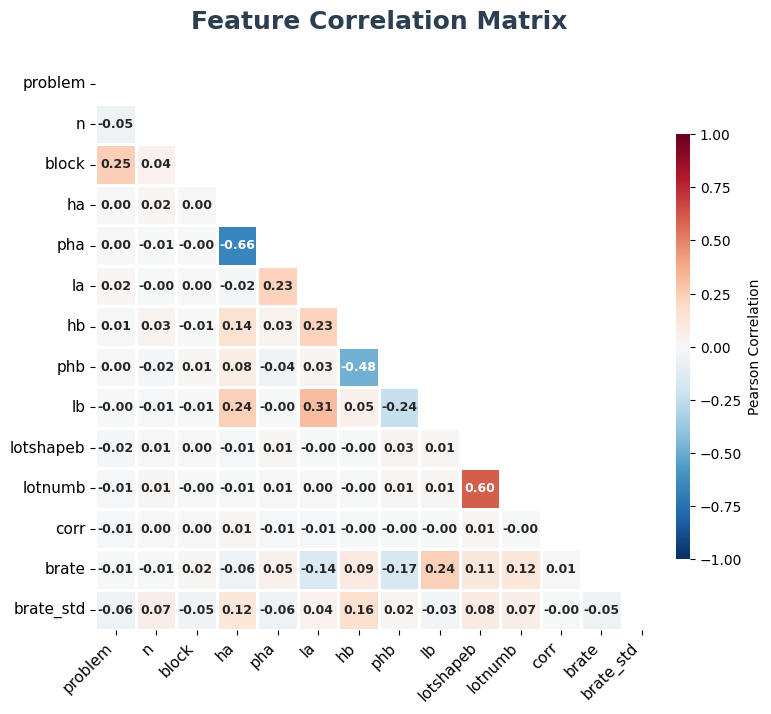

In [21]:
# Correlation matrix for numeric features
numeric_df = df_full.select_dtypes(include=["number"])
if not numeric_df.empty:
    corr = numeric_df.corr()

    fig, ax = plt.subplots(figsize=(8, 7))

    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=1,
        linecolor='white',
        cbar_kws={
            'label': 'Pearson Correlation',
            'shrink': 0.75,
            'aspect': 30,
            'pad': 0.02
        },
        annot_kws={
            'size': 9,
            'weight': 'bold'
        },
        ax=ax
    )

    ax.set_title('Feature Correlation Matrix',
                 fontsize=18,
                 fontweight='bold',
                 pad=25,
                 color='#2c3e50')

    ax.set_xticklabels(ax.get_xticklabels(),
                       rotation=45,
                       ha='right',
                       fontsize=11,
                       fontweight='500')
    ax.set_yticklabels(ax.get_yticklabels(),
                       rotation=0,
                       fontsize=11,
                       fontweight='500')

    ax.set_xlabel('')
    ax.set_ylabel('')

    plt.tight_layout()
    plt.show()

Most features are not linearly correlated with each other, so there is not much repeated information.

### Dataset Overview

- The dataset contains **14,568 observations** with a mix of numerical, binary, and structured features.
- The target variable **`brate`** is continuous in \([0, 1]\), with a mean of ≈ **0.52** and moderate dispersion.
- **No missing values** are present in any feature, eliminating the need for imputation.
- Several variables (e.g., `ha`, `hb`, `la`, `lb`) exhibit **wide ranges**, indicating heterogeneous choice contexts.

---

### Feature Characteristics

- Count-based features (`n`, `block`, `lotnumb`) show limited variance, suggesting bounded experimental structure.
- Probability-like variables (`pha`, `phb`) are naturally constrained to \([0, 1]\).
- Structured variables (`A`, `B`) encode alternative-specific attributes and are later summarized through derived features.

---

### Correlation Structure (Numeric Features)

- Pairwise correlations are generally **low to moderate**, indicating limited multicollinearity.
- Stronger dependencies appear between:
  - `lotshapeb` and `lotnumb`, reflecting related design aspects of the choice task.
  - Alternative-specific quantities (`ha`, `hb`, `la`, `lb`) that encode symmetric information for options A and B.
- The target `brate` shows **weak marginal correlations** with individual predictors, consistent with earlier univariate analysis.

---

### 3.2 Correlation with the target

We compute each numeric feature's Pearson correlation with `bRate`, sort them by strength, and display both a table and a bar chart. Features with larger absolute correlation are stronger linear predictors of the choice rate and are good candidates for the model, weak correlations do not rule out nonlinear relationships that tree-based or kernel models can still capture.

Correlation of each numeric feature with brate (sorted):


,corr_with_bRate
lb,0.238497
lotnumb,0.122896
lotshapeb,0.112797
hb,0.092437
amb,0.087488
pha,0.053659
block,0.015038
corr,0.005025
feedback,0.003050
problem,-0.005596


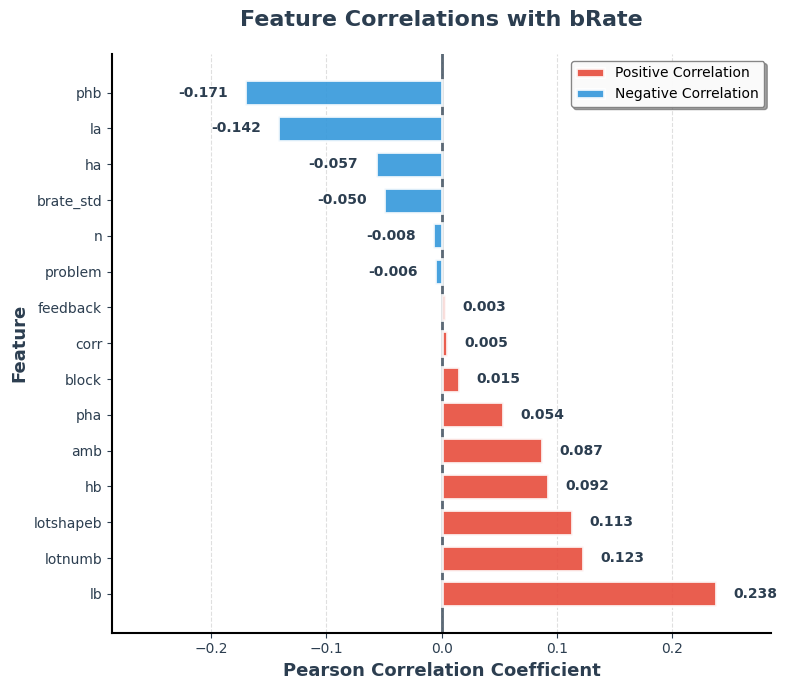


CORRELATION INSIGHTS
  Strongest positive: lb              →   0.238
  Strongest negative: phb             →  -0.171
  Weakest overall:    feedback        →   0.003



In [22]:
# Correlation of all numeric features with bRate

corr_matrix = df_full.corr(numeric_only=True)
corr_with_brate = corr_matrix["brate"].drop(labels=["brate"], errors="ignore").sort_values(ascending=False)

print("Correlation of each numeric feature with brate (sorted):")
display(corr_with_brate.to_frame(name="corr_with_bRate"))

fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_with_brate.values]

bars = ax.barh(
    y=range(len(corr_with_brate)),
    width=corr_with_brate.values,
    color=colors,
    edgecolor='white',
    linewidth=2,
    alpha=0.9,
    height=0.7
)

ax.set_yticks(range(len(corr_with_brate)))
ax.set_yticklabels(corr_with_brate.index, fontsize=11, fontweight='500')

ax.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=2, alpha=0.8, zorder=0)

for i, (idx, val) in enumerate(corr_with_brate.items()):
    x_pos = val + (0.015 if val > 0 else -0.015)
    ha = 'left' if val > 0 else 'right'

    ax.text(
        x_pos, i, f'{val:.3f}',
        va='center', ha=ha,
        fontsize=10, fontweight='bold',
        color='#2c3e50'
    )

ax.set_xlabel('Pearson Correlation Coefficient', fontsize=13, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Feature', fontsize=13, fontweight='bold', color='#2c3e50')
ax.set_title('Feature Correlations with bRate',
             fontsize=16, fontweight='bold', pad=20, color='#2c3e50')

ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)

max_abs = max(abs(corr_with_brate.min()), abs(corr_with_brate.max()))
ax.set_xlim(-max_abs * 1.2, max_abs * 1.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

legend_elements = [
    Patch(facecolor='#e74c3c', alpha=0.9, edgecolor='white', linewidth=2, label='Positive Correlation'),
    Patch(facecolor='#3498db', alpha=0.9, edgecolor='white', linewidth=2, label='Negative Correlation')
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.95,
          edgecolor='gray', fancybox=True, shadow=True, fontsize=10)

ax.tick_params(axis='both', which='major', labelsize=10, colors='#2c3e50')

plt.tight_layout()
plt.show()

print(f"\n{'='*65}")
print(f"CORRELATION INSIGHTS")
print(f"{'='*65}")
print(f"  Strongest positive: {corr_with_brate.idxmax():15} → {corr_with_brate.max():7.3f}")
print(f"  Strongest negative: {corr_with_brate.idxmin():15} → {corr_with_brate.min():7.3f}")
print(f"  Weakest overall:    {corr_with_brate.abs().idxmin():15} → {corr_with_brate[corr_with_brate.abs().idxmin()]:7.3f}")
print(f"{'='*65}\n")

### Correlation Analysis with `brate`

- Most individual features exhibit **weak-to-moderate linear correlation** with `brate`, indicating that no single variable dominates the prediction.
- **Positive correlations**:
  - `lb` shows the strongest positive association with `brate`, followed by `lotnumb` and `lotshapeb`.
  - `hb`, `amb`, and `pha` also contribute positively but with smaller effect sizes.
- **Negative correlations**:
  - `phb`, `la`, and `ha` are moderately negatively correlated with `brate`, suggesting inverse relationships.
  - `brate_std` shows a mild negative correlation, indicating higher variability may be associated with lower average `brate`.
- Several features (`block`, `corr`, `feedback`, `problem`, `n`) are **near-zero correlated**, implying limited standalone linear explanatory power.

**Interpretation**
- Low marginal correlations do **not** imply irrelevance: Ridge regression can still leverage these features through **joint effects and regularization**.
- The results suggest that `brate` is influenced by **combinations of features rather than single strong predictors**, motivating multivariate and potentially non-linear models.


## 4. Feature engineering

We derive numeric features from the raw gamble columns `A` and `B` (lists of outcome–probability pairs) so that standard ML models can use them. All new features are computed from the full gamble distributions.

**Overview of steps:**

1. **Numeric cleaning** — Round existing numeric columns to 2 decimals for consistency.
2. **Expected value and risk** — Compute EV and standard deviation per gamble; add differences (A − B).
3. **Extreme outcomes and minimum payoffs** — Flags for large gains/losses, EV difference, and worst-outcome comparison.
4. **Probability of positive payoff** — P(reward > 0) for each option and their difference.
5. **Psychological features** — Probability A beats B, expected regret, probability of regret, and worst-outcome probabilities.

### 4.1 Numeric cleaning

Round all numeric columns to 2 decimal places so downstream computations and models see consistent precision.

In [23]:
numeric_cols = df_full.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df_full[col] = df_full[col].round(2)

### 4.2 Expected value and risk

- **Helpers:** Parse gamble lists (support string or list), round (p, r) pairs, and compute **expected value** and **standard deviation** per gamble.
- **New columns:** `A_ev`, `B_ev`, `A_std`, `B_std`, then `std_diff` = A_std − B_std and `variance_diff` = A_std² − B_std².
- Raw `A` and `B` are rounded in place for consistency.

In [24]:
def _ensure_gamble_list(gamble_list):
    """Ensure we always work with a list[(p, r)]"""
    if isinstance(gamble_list, str):
        return ast.literal_eval(gamble_list)
    return gamble_list

def round_gamble_column(gamble_list, decimals=2):
    """Round probabilities and rewards to a fixed number of decimals."""
    gl = _ensure_gamble_list(gamble_list)
    return [(round(p, decimals), round(r, decimals)) for p, r in gl]

def calculate_gamble_stats(gamble_list):
    """
    Compute expected value (EV) and standard deviation for a gamble.

    gamble_list: list of (probability, reward) tuples
    returns: (ev, std_dev)
    """
    gl = _ensure_gamble_list(gamble_list)
    probs = [x[0] for x in gl]
    rewards = [x[1] for x in gl]

    ev = sum(p * r for p, r in zip(probs, rewards))
    variance = sum(p * (r - ev) ** 2 for p, r in zip(probs, rewards))
    std_dev = np.sqrt(variance)

    return round(ev, 2), round(std_dev, 2)

# Apply rounding to raw gamble columns
df_full["A"] = df_full["A"].apply(round_gamble_column)
df_full["B"] = df_full["B"].apply(round_gamble_column)

# Compute EV and std for each option
df_full["A_ev"], df_full["A_std"] = zip(*df_full["A"].apply(calculate_gamble_stats))
df_full["B_ev"], df_full["B_std"] = zip(*df_full["B"].apply(calculate_gamble_stats))

# Basic risk features
df_full["std_diff"] = df_full["A_std"] - df_full["B_std"]
df_full["variance_diff"] = df_full["A_std"] ** 2 - df_full["B_std"] ** 2

### 4.3 Extreme outcomes and minimum payoffs

- **Extreme outcomes:** Boolean flags for each gamble: `*_has_large_loss` (any outcome ≤ −20) and `*_has_large_gain` (any outcome ≥ 50).
- **EV difference:** `ev_diff` = A_ev − B_ev.
- **Worst outcome:** Minimum payoff per gamble (`A_min`, `B_min`) and `min_diff` = A_min − B_min.

In [25]:

def has_extreme_outcomes(gamble_list, loss_threshold=-20, gain_threshold=50):
    """
    Check if a gamble has extreme outcomes (large losses or gains).

    returns: (has_large_loss, has_large_gain)
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    has_large_loss = any(r <= loss_threshold for r in rewards)
    has_large_gain = any(r >= gain_threshold for r in rewards)
    return has_large_loss, has_large_gain

# Extreme outcome indicators for A and B
df_full["A_has_large_loss"], df_full["A_has_large_gain"] = zip(
    *df_full["A"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)
df_full["B_has_large_loss"], df_full["B_has_large_gain"] = zip(
    *df_full["B"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)

# EV difference
df_full["ev_diff"] = df_full["A_ev"] - df_full["B_ev"]

def get_min_outcome(gamble_list):
    """Get the minimum (worst) outcome from a gamble."""
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    return min(rewards)

# Worst outcomes and their difference
df_full["A_min"] = df_full["A"].apply(get_min_outcome)
df_full["B_min"] = df_full["B"].apply(get_min_outcome)
df_full["min_diff"] = df_full["A_min"] - df_full["B_min"]

### 4.4 Probability of positive payoff

Probability that a single draw from the gamble yields a **strictly positive** reward: P(reward > 0). We add `A_prob_positive`, `B_prob_positive`, and `prob_positive_diff` = A − B.

In [26]:

def prob_positive(gamble_list):
    """Calculate probability of getting a strictly positive payoff."""
    gl = _ensure_gamble_list(gamble_list)
    return sum(p for p, r in gl if r > 0)

df_full["A_prob_positive"] = df_full["A"].apply(prob_positive)
df_full["B_prob_positive"] = df_full["B"].apply(prob_positive)
df_full["prob_positive_diff"] = (
    df_full["A_prob_positive"] - df_full["B_prob_positive"]
)

### 4.5 Psychological features

| Feature | Description |
|--------|-------------|
| `prob_A_beats_B` | P(X_A > X_B) in one independent draw from each gamble (convolution of the two distributions). |
| `expected_regret` | Expected regret when choosing A: E[max(0, X_B − X_A)]. |
| `prob_regret` | P(X_B > X_A). |
| `A_prob_worst`, `B_prob_worst` | Probability of the worst (minimum) outcome in each gamble. |
| `prob_worst_diff` | A_prob_worst − B_prob_worst. |

A short sanity check displays the first rows of the engineered dataframe.

In [27]:

def prob_A_beats_B(gamble_A, gamble_B):
    """
    P(X_A > X_B) in a single draw by convolving the two distributions.
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_A_beats = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_A > r_B:
                prob_A_beats += p_A * p_B
    return prob_A_beats

df_full["prob_A_beats_B"] = df_full.apply(
    lambda row: prob_A_beats_B(row["A"], row["B"]), axis=1
)

def expected_regret(gamble_A, gamble_B):
    """
    Expected regret if choosing A: E[max(0, X_B - X_A)].
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    expected_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            regret = max(0, r_B - r_A)
            expected_regret_val += p_A * p_B * regret
    return expected_regret_val

df_full["expected_regret"] = df_full.apply(
    lambda row: expected_regret(row["A"], row["B"]), axis=1
)

def prob_regret(gamble_A, gamble_B):
    """
    Probability of regret: P(X_B > X_A).
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_B > r_A:
                prob_regret_val += p_A * p_B
    return prob_regret_val

df_full["prob_regret"] = df_full.apply(
    lambda row: prob_regret(row["A"], row["B"]), axis=1
)

def prob_worst_outcome(gamble_list):
    """
    Probability of hitting the worst (minimum) outcome.
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    min_reward = min(rewards)
    return sum(p for p, r in gl if r == min_reward)

df_full["A_prob_worst"] = df_full["A"].apply(prob_worst_outcome)
df_full["B_prob_worst"] = df_full["B"].apply(prob_worst_outcome)
df_full["prob_worst_diff"] = df_full["A_prob_worst"] - df_full["B_prob_worst"]

df_full.head(10)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,...,min_diff,A_prob_positive,B_prob_positive,prob_positive_diff,prob_A_beats_B,expected_regret,prob_regret,A_prob_worst,B_prob_worst,prob_worst_diff
0,1,True,15,2,26,0.95,-1,23,0.05,21,...,-22.0,0.95,1.00,-0.05,0.95,1.105,0.05,0.05,0.95,-0.90
1,2,True,15,4,14,0.60,-18,8,0.25,-5,...,-13.0,0.60,0.25,0.35,0.60,6.500,0.40,0.40,0.75,-0.35
2,3,True,17,4,2,0.50,0,1,1.00,1,...,-1.0,0.50,1.00,-0.50,0.50,0.500,0.50,0.50,1.00,-0.50
3,4,True,18,3,37,0.05,8,87,0.25,-31,...,39.0,1.00,0.24,0.76,0.75,18.612,0.24,0.95,0.75,0.20
4,5,False,15,1,26,1.00,26,45,0.75,-36,...,62.0,1.00,0.76,0.24,0.25,14.520,0.76,1.00,0.25,0.75
5,6,True,15,4,28,1.00,28,33,0.01,28,...,0.0,1.00,1.00,0.00,0.00,0.030,0.01,1.00,0.99,0.01
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
8,8,False,15,1,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50
9,8,True,16,2,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50


Our final features:

| Feature | Source | Description |
|---------|--------|-------------|
| **problem** | selections | Unique internal problem ID (integer). |
| **n** | selections | Number of subjects for this problem (integer). |
| **feedback** | selections | Whether participants received feedback (boolean). |
| **brate** | selections | **Target.** Frequency with which subjects chose Gamble B (float). |
| **brate_std** | selections | Empirical standard deviation of that choice proportion (float). |
| **ha** | selections | First outcome of Gamble A (integer). |
| **pha** | selections | Probability of ha in Gamble A (float). |
| **la** | selections | Second outcome of Gamble A; occurs with probability 1−pHa (integer). |
| **hb** | selections | Expected value of the lottery in Gamble B (integer). |
| **phb** | selections | Probability of that lottery in Gamble B (float). |
| **lb** | selections | Non-lottery outcome in Gamble B; occurs with probability 1−pHb (float). |
| **lotshapeb** | selections | Shape of lottery B: 0=undefined, 1=symmetric, 2=right-skewed, 3=left-skewed. |
| **lotnumb** | selections | Number of possible outcomes in Gamble B lottery (integer). |
| **amb** | selections | Whether probabilities of B were hidden (1=ambiguous, 0=full information) (boolean). |
| **corr** | selections | Correlation between payoffs of A and B: −1, 0, or 1. |
| **block** | selections | Block ID (1–5); 1 when no feedback (integer). |
| **A** | problems | Full Gamble A: list of (probability, outcome) pairs. |
| **B** | problems | Full Gamble B: list of (probability, outcome) pairs. |
| **A_ev** | engineered | Expected value of Gamble A. |
| **B_ev** | engineered | Expected value of Gamble B. |
| **A_std** | engineered | Standard deviation of Gamble A. |
| **B_std** | engineered | Standard deviation of Gamble B. |
| **std_diff** | engineered | A_std − B_std. |
| **variance_diff** | engineered | A_std² − B_std². |
| **A_has_large_loss** | engineered | True if any outcome in A ≤ −20. |
| **A_has_large_gain** | engineered | True if any outcome in A ≥ 50. |
| **B_has_large_loss** | engineered | True if any outcome in B ≤ −20. |
| **B_has_large_gain** | engineered | True if any outcome in B ≥ 50. |
| **ev_diff** | engineered | A_ev − B_ev. |
| **A_min** | engineered | Minimum (worst) outcome in A. |
| **B_min** | engineered | Minimum (worst) outcome in B. |
| **min_diff** | engineered | A_min − B_min. |
| **A_prob_positive** | engineered | P(reward > 0) in one draw from A. |
| **B_prob_positive** | engineered | P(reward > 0) in one draw from B. |
| **prob_positive_diff** | engineered | A_prob_positive − B_prob_positive. |
| **prob_A_beats_B** | engineered | P(X_A > X_B) in one independent draw from each gamble. |
| **expected_regret** | engineered | E[max(0, X_B − X_A)] when choosing A. |
| **prob_regret** | engineered | P(X_B > X_A). |
| **A_prob_worst** | engineered | Probability of the worst outcome in A. |
| **B_prob_worst** | engineered | Probability of the worst outcome in B. |
| **prob_worst_diff** | engineered | A_prob_worst − B_prob_worst. |

Correlation of each engineered feature with brate (sorted):


,corr_with_bRate
prob_regret,0.503324
B_min,0.238953
B_prob_positive,0.218748
B_prob_worst,0.173463
expected_regret,0.147141
B_ev,0.144434
variance_diff,0.117784
std_diff,0.104230
B_has_large_gain,0.056916
A_std,0.053789


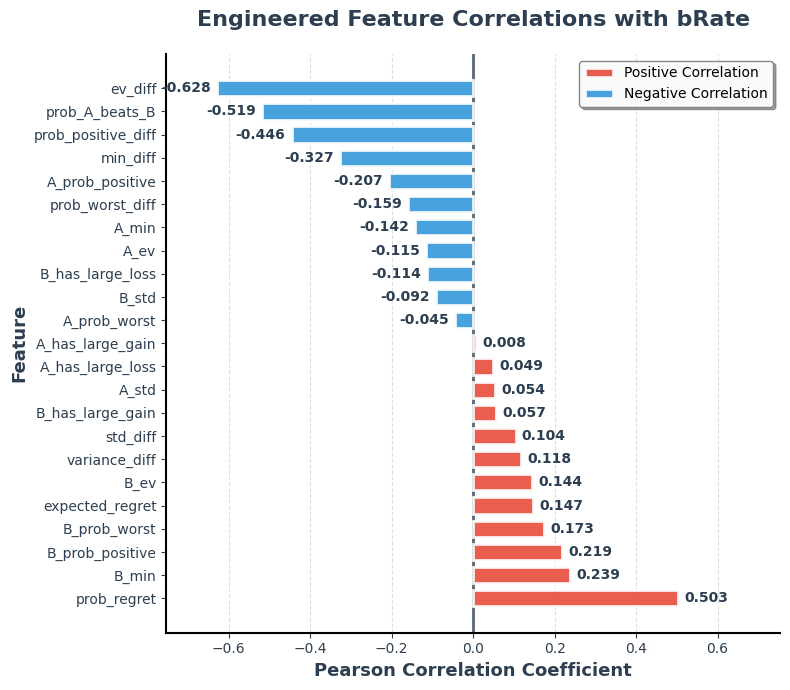

In [28]:
engineered_cols = [
    "A_ev", "B_ev", "A_std", "B_std", "std_diff", "variance_diff",
    "A_has_large_loss", "A_has_large_gain", "B_has_large_loss", "B_has_large_gain",
    "ev_diff", "A_min", "B_min", "min_diff",
    "A_prob_positive", "B_prob_positive", "prob_positive_diff",
    "prob_A_beats_B", "expected_regret", "prob_regret",
    "A_prob_worst", "B_prob_worst", "prob_worst_diff",
]

# Restrict to engineered columns that exist and are numeric, plus brate
available_eng = [c for c in engineered_cols if c in df_full.columns]
df_eng = df_full[available_eng + ["brate"]]

# Correlation of engineered features with bRate (same logic as original)
corr_matrix_eng = df_eng.corr(numeric_only=True)
corr_with_brate_eng = corr_matrix_eng["brate"].drop(labels=["brate"], errors="ignore").sort_values(ascending=False)

print("Correlation of each engineered feature with brate (sorted):")
display(corr_with_brate_eng.to_frame(name="corr_with_bRate"))

fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_with_brate_eng.values]

bars = ax.barh(
    y=range(len(corr_with_brate_eng)),
    width=corr_with_brate_eng.values,
    color=colors,
    edgecolor='white',
    linewidth=2,
    alpha=0.9,
    height=0.7
)

ax.set_yticks(range(len(corr_with_brate_eng)))
ax.set_yticklabels(corr_with_brate_eng.index, fontsize=11, fontweight='500')

ax.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=2, alpha=0.8, zorder=0)

for i, (idx, val) in enumerate(corr_with_brate_eng.items()):
    x_pos = val + (0.015 if val > 0 else -0.015)
    ha = 'left' if val > 0 else 'right'
    ax.text(
        x_pos, i, f'{val:.3f}',
        va='center', ha=ha,
        fontsize=10, fontweight='bold',
        color='#2c3e50'
    )

ax.set_xlabel('Pearson Correlation Coefficient', fontsize=13, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Feature', fontsize=13, fontweight='bold', color='#2c3e50')
ax.set_title('Engineered Feature Correlations with bRate',
             fontsize=16, fontweight='bold', pad=20, color='#2c3e50')

ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.8, color='gray')
ax.set_axisbelow(True)

max_abs = max(abs(corr_with_brate_eng.min()), abs(corr_with_brate_eng.max()))
ax.set_xlim(-max_abs * 1.2, max_abs * 1.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

legend_elements = [
    Patch(facecolor='#e74c3c', alpha=0.9, edgecolor='white', linewidth=2, label='Positive Correlation'),
    Patch(facecolor='#3498db', alpha=0.9, edgecolor='white', linewidth=2, label='Negative Correlation')
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.95,
          edgecolor='gray', fancybox=True, shadow=True, fontsize=10)

ax.tick_params(axis='both', which='major', labelsize=10, colors='#2c3e50')

plt.tight_layout()
plt.show()


#### Key Finding:
**Engineered features dramatically outperform original features.** The top engineered feature (`ev_diff` = -0.628) is **2.6× stronger** than the best original feature (`lb` = 0.238). Seven engineered features exceed 0.20 correlation vs. only one original feature.

#### Top Predictors:

**Tier 1 - Strongest (|r| > 0.40):**
1. **`ev_diff`** (-0.628): EV difference between options - strongest overall predictor
2. **`prob_A_beats_B`** (-0.519): Probability A dominates B
3. **`prob_regret`** (0.503): Regret probability - validates regret theory

**Tier 2 - Very Strong (0.20 < |r| < 0.40):**
4. **`prob_positive_diff`** (-0.446): Probability of positive difference
5. **`min_diff`** (-0.327): Difference in worst-case outcomes
6. **`B_min`** (0.239): Safety floor for option B

#### Insights:

**Regret aversion dominates:** `prob_regret` is the strongest positive predictor, confirming people systematically avoid anticipated regret

**EV matters most:** `ev_diff` is the clear winner, but the pattern shows people *overweight* EV differences in their choices

**Safety floors matter:** `B_min` and `min_diff` show strong loss aversion - people focus heavily on worst-case scenarios

#### Bottom Line:
Feature engineering was essential. Original features alone would yield poor predictions. Focus on EV differences, regret probability, and safety comparisons for best model performance.

## 5. Modelling

We define the target and feature matrix, set up a reusable experiment pipeline (with optional Optuna/Grid/Random search), and train multiple regression models, evaluating them on a held-out test set.

### 5.1 Feature Selection

We define the target `y` and the full feature matrix `X` (excluding target, identifiers, and raw gamble columns). Feature selection is performed via a tree-based importance method; the reduced set is stored in `X_eng`.

### Feature Selection via Tree-Guided Embedded Importance

Prior to feature selection, we exclude variables to ensure a valid and leakage-free process. Specifically, we remove (i) the target and target-derived variables (`brate`, `brate_std`); (ii) identifier variables (`problem`); and (iii) non-numeric structured gamble representations (`A`, `B`), which are instead summarized through engineered numerical features. Only numeric and boolean predictors are retained.

Feature selection is performed using a **tree-based approach**. A regularized **LightGBM regressor** is trained with early stopping on a validation split, and **gain-based feature importance** is extracted. This measure reflects each feature’s total contribution to reducing the training loss and naturally captures non-linear effects and interactions.

Predictors are ranked by their gain importance, and the top-\(k\) features are retained to form the final design matrix `X_eng`. This approach provides a computationally efficient and robust alternative to wrapper-based methods, yielding a compact feature set without sacrificing predictive performance.



In [29]:
X = df_full.drop(columns=["brate", "brate_std", "problem", "A", "B"])
y = df_full["brate"]

In [30]:
def select_features_lgb_regression(
    X: pd.DataFrame,
    y,
    test_size: float = 0.2,
    seed: int = 42,
    top_k: int = 200,
):
    # split
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, np.asarray(y), test_size=test_size, random_state=seed
    )

    # fit
    model = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=64,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)],
    )

    # gain importance
    booster = model.booster_
    gain = pd.Series(
        booster.feature_importance(importance_type="gain"),
        index=booster.feature_name(),
        name="gain",
    ).sort_values(ascending=False)

    selected = gain.head(top_k).index.tolist()
    importance_table = gain.to_frame()

    return selected, importance_table


selected_feats, imp = select_features_lgb_regression(X, y, top_k=11)
X_eng = X[selected_feats]
print(len(selected_feats))
print(imp.head(20))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003705 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3747
[LightGBM] [Info] Number of data points in the train set: 11654, number of used features: 36
[LightGBM] [Info] Start training from score 0.518630
11
                           gain
ev_diff             3350.651993
prob_A_beats_B      1134.049203
expected_regret      908.192946
prob_positive_diff   853.168926
prob_regret          282.340775
amb                  237.912399
min_diff             204.597349
hb                   161.229264
phb                  155.893983
lotshapeb            151.923996
ha                   134.290848
B_prob_worst          95.889145
A_ev                  90.138471
la                    87.147837
lotnumb               85.341625
B_min                 73.092613
pha                   72.968851
std_diff              72.814429
B_std                 71.696364
lb             

#### Feature usage across models

Different model classes exhibit different sensitivity to irrelevant or redundant predictors. Accordingly, we distinguish between two feature configurations:

- **Reduced engineered feature set (`X_eng`)**  
  The compact feature matrix obtained via feature selection is used for **feature-sensitive models**, including:
  - Linear models (Ridge, ElasticNet)
  - Distance- or margin-based models (e.g., SVMs)
  - Neural networks

  These models are known to be sensitive to multicollinearity and noisy predictors; using `X_eng` improves stability, interpretability, and generalization while reducing variance.

- **Full engineered feature set**  
  The complete set of engineered decision features is used for **feature-robust models**, including:
  - Tree-based models (Random Forests)
  - Gradient boosting methods (XGBoost, LightGBM)

  These models perform implicit feature selection through recursive partitioning and are therefore less sensitive to redundant or weak predictors. Using the full feature set allows them to exploit higher-order interactions without the need for explicit feature pruning.

This separation ensures that each model is evaluated under conditions that best match its biases, enabling fair comparison while avoiding unnecessary feature-induced instability.


### 5.2 Experiment pipeline

We define a custom result class `EvaluationResult` and a reusable `run_experiment` function that trains a model with optional hyperparameter search (Optuna, GridSearchCV, or RandomizedSearchCV) and returns the best estimator, parameters, test predictions, errors, and metrics. Results of each run are fully reproducable, because we are using a `TPESampler`.

In [31]:
@dataclass
class EvaluationResult:
    """Result of a single run_experiment: best model, params, test predictions, errors, and metrics."""
    best_estimator: Any
    best_params: Dict[str, Any]
    predictions: Any
    errors: Any
    metrics: Dict[str, float]

In [32]:
def run_experiment(
    model, X, y,
    params=None,
    search_engine="optuna",          # "optuna" | "random" | "grid" | None
    cv_folds=3,
    n_trials=50,                     # optuna trials
    n_iter=20,                       # randomized iterations
    verbose=1,
    sample_size=None,
    run_full_pipeline=True,
    scoring="neg_mean_absolute_error",
    random_state=42,
    plots=None,                     # list of plot names; if None, all plots are produced
    model_name=None,                 # optional title for learning curve plot
):
    """
    Train a regression model with optional hyperparameter search; return best estimator, params, predictions, errors, metrics.

    Parameters
    ----------
    model : estimator
        Base regressor (e.g. Ridge(), RandomForestRegressor()).
    X, y : array-like
        Feature matrix and target. X should be numeric/bool when run_full_pipeline=True.
    params : dict, optional
        Search space. For grid/random: param name -> list of values. For optuna: param name -> (kind, ...)
        with kind in ("categorical", list), ("int", low, high, log?), ("float", low, high, log?).
        Pipeline adds "reg__" prefix automatically.
    search_engine : "optuna" | "random" | "grid" | None
        Which search to use; None = no tuning.
    cv_folds, n_trials, n_iter : int
        CV folds; Optuna trials; random-search iterations.
    sample_size : int or float, optional
        If set, tune on a random subset of train; final model is refit on full train.
    run_full_pipeline : bool
        If True, use Pipeline: impute -> StandardScaler -> regressor.
    scoring : str
        Sklearn scoring (e.g. "neg_mean_absolute_error").
    plots : list of str or None
        Plot names to produce. Allowed: "predicted_vs_actual", "feature_importance". If None, these three are produced.
    model_name : str, optional
        Title for the diagnostic plots.

    Returns
    -------
    EvaluationResult
        best_estimator, best_params, predictions, errors, metrics (MAE, RMSE, MSE, R2).
    """

    # --- Pipeline: impute + scale + regressor (or use raw model) ---
    if run_full_pipeline:
        num_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()

        pipeline = Pipeline(steps=[
            ("prep", ColumnTransformer(
                transformers=[
                    ("num", Pipeline(steps=[
                        ("imputer", SimpleImputer(strategy="median")), # Can be skipped since we have no missing values
                        ("scaler", StandardScaler()),
                    ]), num_cols),
                ],
                remainder="drop"
            )),
            ("reg", model)
        ])
        needs_prefix = True
    else:
        pipeline = model
        needs_prefix = False

    # --- Train/test split (80/20) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # --- Optional: subsample training data for faster tuning (final refit uses full train) ---
    if sample_size is not None and params is not None and search_engine in {"grid", "random", "optuna"}:
        if isinstance(sample_size, float):
            n_samples = int(len(X_train) * sample_size)
        else:
            n_samples = min(int(sample_size), len(X_train))
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(len(X_train), n_samples, replace=False)
        X_train_sample = X_train.iloc[sample_idx] if hasattr(X_train, "iloc") else X_train[sample_idx]
        y_train_sample = y_train.iloc[sample_idx] if hasattr(y_train, "iloc") else y_train[sample_idx]
        if verbose:
            print(f"Using {n_samples}/{len(X_train)} samples for tuning...")
    else:
        X_train_sample, y_train_sample = X_train, y_train


    best_params = None
    best_estimator = None

    # --- Hyperparameter search (grid / random / optuna) or single fit ---
    if params is not None and search_engine is not None:
        if search_engine in {"grid", "random"}:
            # sklearn-style lists
            param_grid = {f"reg__{k}": v for k, v in params.items()} if needs_prefix else params

            if search_engine == "random":
                search = RandomizedSearchCV(
                    estimator=pipeline,
                    param_distributions=param_grid,
                    n_iter=n_iter,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    random_state=random_state,
                    verbose=verbose
                )
                if verbose:
                    print(f"Running RandomizedSearchCV with {n_iter} iterations, {cv_folds}-fold CV...")
            else:
                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=param_grid,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    verbose=verbose
                )
                if verbose:
                    total_combinations = 1
                    for v in param_grid.values():
                        total_combinations *= len(v)
                    print(f"Running GridSearchCV with {total_combinations} combinations, {cv_folds}-fold CV...")

            search.fit(X_train_sample, y_train_sample)

            best_params = search.best_params_
            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -search.best_score_)

            # If sampled, refit on full training set
            if sample_size is not None:
                if verbose:
                    print("Refitting best model on full training data...")
                pipeline.set_params(**best_params)
                pipeline.fit(X_train, y_train)
                best_estimator = pipeline
            else:
                best_estimator = search.best_estimator_

        elif search_engine == "optuna":
            # Optuna params spec: each value is (kind, ...).
            # categorical: ("categorical", [a, b, ...])
            # int: ("int", low, high, log=False, step=1)
            # float: ("float", low, high, log=False, step=None)
            def suggest_params(trial):
                suggested = {}
                for name, spec in params.items():
                    kind = spec[0].lower()

                    if kind == "categorical":
                        suggested[name] = trial.suggest_categorical(name, spec[1])

                    elif kind == "int":
                        low, high = int(spec[1]), int(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = int(spec[4]) if len(spec) > 4 and spec[4] is not None else 1
                        suggested[name] = trial.suggest_int(name, low, high, log=log, step=step)

                    elif kind == "float":
                        low, high = float(spec[1]), float(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = spec[4] if len(spec) > 4 else None
                        if step is None:
                            suggested[name] = trial.suggest_float(name, low, high, log=log)
                        else:
                            suggested[name] = trial.suggest_float(name, low, high, step=float(step), log=log)

                    else:
                        raise ValueError(f"Unknown optuna spec kind for {name}: {kind}")

                # Prefix if pipeline
                if needs_prefix:
                    suggested = {f"reg__{k}": v for k, v in suggested.items()}
                return suggested

            def objective(trial):
                trial_params = suggest_params(trial)
                est = pipeline.set_params(**trial_params)

                # Cross-validated score on training sample
                scores = cross_val_score(
                    est,
                    X_train_sample, y_train_sample,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1
                )
                # maximize neg-MAE -> higher is better
                return float(np.mean(scores))

            # NOTE: direction="maximize" because neg-MAE higher is better
            sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=10) # Be able to reproduce results
            study = optuna.create_study(direction="maximize", sampler=sampler)
            study.optimize(objective, n_trials=n_trials, show_progress_bar=(verbose > 0))

            best_params = study.best_params
            if needs_prefix:
                best_params = {f"reg__{k}": v for k, v in best_params.items()}

            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -study.best_value)

            # Refit best on full training data
            pipeline.set_params(**best_params)
            pipeline.fit(X_train, y_train)
            best_estimator = pipeline

        else:
            raise ValueError(f"Unknown search_engine={search_engine}")

    else:
        # No tuning
        pipeline.fit(X_train, y_train)
        best_estimator = pipeline


    # --- Evaluate on held-out test set ---
    pred = best_estimator.predict(X_test)
    errors = y_test - pred

    mae = mean_absolute_error(y_test, pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    metrics = {"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2}

    if verbose:
        print("MAE:", mae)
        print("RMSE:", rmse)
        print("MSE:", mse)
        print("R^2:", r2)

    # --- Resolve which plots to produce (plot list with names) ---
    # Plot names: "predicted_vs_actual", "feature_importance"
    if plots is None:
        plots = ["predicted_vs_actual", "feature_importance"]
    plot_set = set(plots)
    do_predicted_vs_actual = "predicted_vs_actual" in plot_set
    do_feature_importance = "feature_importance" in plot_set

    # --- Plots: predicted vs actual, feature importance ---
    if do_predicted_vs_actual or do_feature_importance:
        if hasattr(best_estimator, "named_steps"):
            X_train_t = best_estimator.named_steps["prep"].transform(X_train)
            X_test_t = best_estimator.named_steps["prep"].transform(X_test)
            if hasattr(X_train_t, "toarray"): X_train_t = X_train_t.toarray(); X_test_t = X_test_t.toarray()
            feature_names = num_cols
            est = best_estimator.named_steps["reg"]
        else:
            X_train_t = np.asarray(X_train) if not hasattr(X_train, "values") else X_train.values
            X_test_t = np.asarray(X_test) if not hasattr(X_test, "values") else X_test.values
            feature_names = list(X_train.columns) if hasattr(X_train, "columns") else [f"f{i}" for i in range(X_train_t.shape[1])]
            est = best_estimator
        prefix = (model_name or "Model") + " — "
        errors_arr = np.asarray(errors).flatten()

        # 1) Predicted vs Actual
        if do_predicted_vs_actual:
            fig, ax = plt.subplots(figsize=(7, 7))

            scatter = ax.scatter(
                y_test, pred,
                alpha=0.6,
                s=50,
                c=np.abs(y_test - pred),
                cmap='RdYlGn_r',
                edgecolors='white',
                linewidth=0.5
            )

            mn, mx = float(y_test.min()), float(y_test.max())
            ax.plot([mn, mx], [mn, mx], "k--", lw=2.5, alpha=0.7, label='Perfect Prediction')

            ax.set_xlabel('Actual bRate', fontsize=13, fontweight='bold', color='#2c3e50')
            ax.set_ylabel('Predicted bRate', fontsize=13, fontweight='bold', color='#2c3e50')
            ax.set_title(f'{prefix}Predicted vs Actual', fontsize=15, fontweight='bold', pad=20, color='#2c3e50')

            ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
            ax.set_axisbelow(True)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)

            cbar = plt.colorbar(scatter, ax=ax, label='Absolute Error')
            cbar.ax.tick_params(labelsize=9)

            ax.legend(loc='upper left', framealpha=0.9, edgecolor='gray', fontsize=10)

            ax.text(0.95, 0.05, f'R² = {r2:.3f}\nMAE = {mae:.3f}',
                transform=ax.transAxes, fontsize=11, verticalalignment='bottom',
                horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            plt.tight_layout()
            plt.show()

        # 2) Feature Importance
        if do_feature_importance and hasattr(est, "feature_importances_"):
            imp = est.feature_importances_
            order = np.argsort(imp)[::-1][:25]

            fig, ax = plt.subplots(figsize=(10, max(6, len(order) * 0.35)))

            colors = ['#e74c3c' if i < 5 else '#3498db' if i < 10 else '#95a5a6' for i in range(len(order))]

            bars = ax.barh(
                range(len(order)),
                imp[order],
                color=colors,
                edgecolor='white',
                linewidth=1.5,
                alpha=0.85
            )

            for i, (idx, val) in enumerate(zip(order, imp[order])):
                ax.text(val + max(imp[order]) * 0.01, i, f'{val:.4f}',
                        va='center', fontsize=9, fontweight='bold', color='#2c3e50')

            ax.set_yticks(range(len(order)))
            ax.set_yticklabels([feature_names[i] for i in order], fontsize=10, fontweight='500')
            ax.set_xlabel('Importance', fontsize=13, fontweight='bold', color='#2c3e50')
            ax.set_title(f'{prefix}Top {len(order)} Most Important Features',
                        fontsize=15, fontweight='bold', pad=20, color='#2c3e50')

            ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.8)
            ax.set_axisbelow(True)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)

            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='#e74c3c', alpha=0.85, label='Top 5'),
                Patch(facecolor='#3498db', alpha=0.85, label='Top 6-10'),
                Patch(facecolor='#95a5a6', alpha=0.85, label='Others')
            ]
            ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9,
                    edgecolor='gray', fontsize=10)

            plt.tight_layout()
            plt.show()

        if do_feature_importance and hasattr(est, "coef_"):
            coef = np.abs(est.coef_.flatten())
            order = np.argsort(coef)[::-1][:25]

            fig, ax = plt.subplots(figsize=(10, max(6, len(order) * 0.35)))

            colors = ['#e74c3c' if i < 5 else '#3498db' if i < 10 else '#95a5a6' for i in range(len(order))]

            bars = ax.barh(
                range(len(order)),
                coef[order],
                color=colors,
                edgecolor='white',
                linewidth=1.5,
                alpha=0.85
            )

            for i, (idx, val) in enumerate(zip(order, coef[order])):
                ax.text(val + max(coef[order]) * 0.01, i, f'{val:.4f}',
                        va='center', fontsize=9, fontweight='bold', color='#2c3e50')

            ax.set_yticks(range(len(order)))
            ax.set_yticklabels([feature_names[i] for i in order], fontsize=10, fontweight='500')
            ax.set_xlabel('|Coefficient|', fontsize=13, fontweight='bold', color='#2c3e50')
            ax.set_title(f'{prefix}Top {len(order)} Features by Coefficient Magnitude',
                        fontsize=15, fontweight='bold', pad=20, color='#2c3e50')

            ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.8)
            ax.set_axisbelow(True)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)

            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='#e74c3c', alpha=0.85, label='Top 5'),
                Patch(facecolor='#3498db', alpha=0.85, label='Top 6-10'),
                Patch(facecolor='#95a5a6', alpha=0.85, label='Others')
            ]
            ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9,
                    edgecolor='gray', fontsize=10)

            plt.tight_layout()
            plt.show()

    return EvaluationResult(
        best_estimator=best_estimator,
        best_params=best_params,
        predictions=pred,
        errors=errors,
        metrics=metrics
    )

### 5.3 Classical models

We compare several regression models using the shared **experiment pipeline** (Section 5.2): same train/test split (80/20), preprocessing (impute + scale), Optuna hyperparameter search (3-fold CV, neg MAE), and optional plots (predicted vs actual, feature importance). Each subsection trains one model, reports best hyperparameters and **test MAE, RMSE, R²**, and briefly interprets results.

**Subsections:**
- **5.3.1** Ridge Regression (linear baseline)
- **5.3.2** Random Forest (tree ensemble)
- **5.3.3** Support Vector Regression (SVR, RBF kernel)
- **5.3.4** Gradient Boosting (scikit-learn GBR)
- **5.3.5** XGBoost
- **5.3.6** LightGBM
- **5.3.7** KNN Regressor
- **5.3.8** Stacking Regressor

---

#### 5.3.1 Ridge Regression

**Purpose:** Linear baseline with L2 regularization. **Tuned:** `alpha`, `solver` (Optuna). **Outputs:** Best params, test MAE/RMSE/R², predicted-vs-actual and coefficient-based feature importance.

[I 2026-02-08 18:54:01,520] A new study created in memory with name: no-name-0233444c-e6df-45e0-aa44-389d2b45dca1


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-08 18:54:03,511] Trial 0 finished with value: -0.1043743055487229 and parameters: {'alpha': 0.017670169402947963, 'solver': 'auto'}. Best is trial 0 with value: -0.1043743055487229.
[I 2026-02-08 18:54:03,618] Trial 1 finished with value: -0.10437442395574702 and parameters: {'alpha': 0.4042872735027334, 'solver': 'cholesky'}. Best is trial 0 with value: -0.1043743055487229.
[I 2026-02-08 18:54:03,704] Trial 2 finished with value: -0.10437419694807747 and parameters: {'alpha': 0.006690421166498805, 'solver': 'lsqr'}. Best is trial 2 with value: -0.10437419694807747.
[I 2026-02-08 18:54:03,787] Trial 3 finished with value: -0.10437431683030303 and parameters: {'alpha': 0.054502936945582565, 'solver': 'auto'}. Best is trial 2 with value: -0.10437419694807747.
[I 2026-02-08 18:54:03,885] Trial 4 finished with value: -0.10437430021165693 and parameters: {'alpha': 0.0002456459215250753, 'solver': 'svd'}. Best is trial 2 with value: -0.10437419694807747.
[I 2026-02-08 18:54:03,964

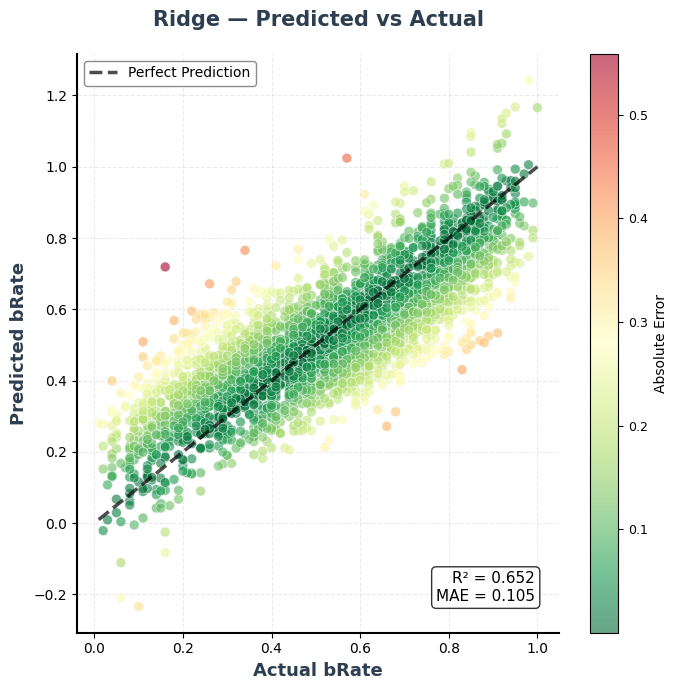

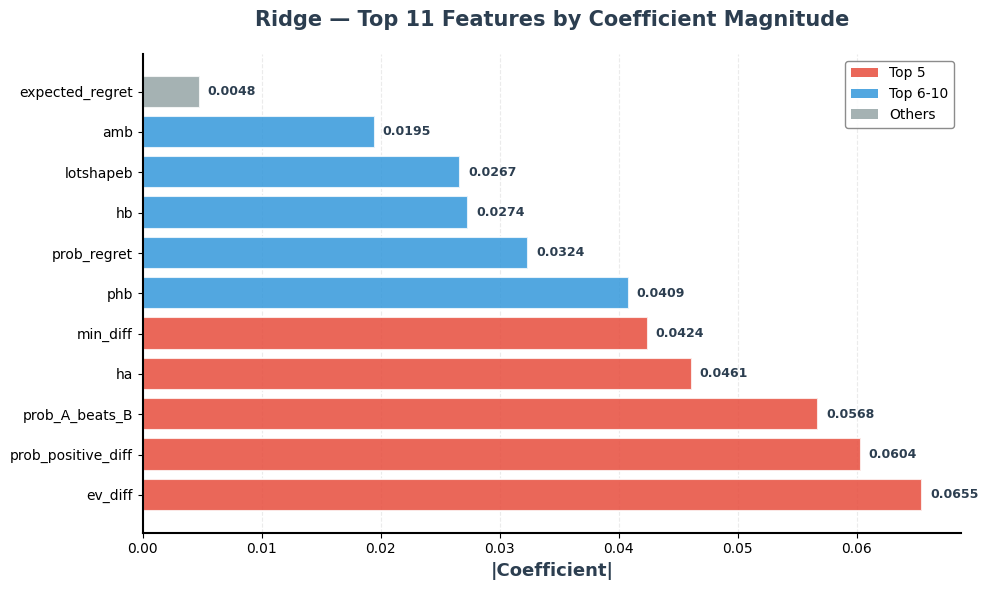

In [33]:
model1 = Ridge(random_state=42)

params_optuna = {

    "alpha": ("float", 1e-4, 1e2, True),

    # categorical solver choice
    "solver": ("categorical", [
        "auto", "svd", "cholesky",
        "lsqr", "sparse_cg", "sag", "saga"
    ])
}

result1 = run_experiment(
    model1,
    X_eng, # use important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["predicted_vs_actual", "feature_importance"],
    model_name="Ridge",
)

pipeline = result1.best_estimator
pred1 = result1.predictions
best_params1 = result1.best_params
metrics1 = result1.metrics


In [34]:
# Ridge results: hyperparameters and test metrics
print("**Ridge results**")
print("Best hyperparameters:", result1.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics1["MAE"], metrics1["RMSE"], metrics1["MSE"], metrics1["R2"]))


**Ridge results**
Best hyperparameters: {'reg__alpha': 0.00010211276539087251, 'reg__solver': 'sag'}
Test metrics: MAE = 0.10472, RMSE = 0.13051, MSE = 0.01703, R2 = 0.65226


##### Performance (Test Set)
- **MAE:** 0.10472  
- **RMSE:** 0.13051  
- **MSE:** 0.01703  
- **R²:** 0.65226  

Best hyperparameters: `alpha = 1.02e-4`, solver `sag`


---

##### Diagnostics
Predicted vs. actual values exhibit a good linear alignment.

---

##### Feature Effects
Largest coefficients correspond to engineered comparative features (`ev_diff`, `prob_positive_diff`, `ha`, `min_diff`), while raw gamble descriptors receive lower weight. This supports the dominance of value and dominance-based signals in aggregate choice behavior.

---

---

#### 5.3.2 Random Forest

**Purpose:** Tree ensemble for non-linear patterns. **Tuned:** `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and gain-based feature importance.

[I 2026-02-08 18:54:11,085] A new study created in memory with name: no-name-54d81579-e07b-4b16-a97c-54c473077c08


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-08 18:55:00,379] Trial 0 finished with value: -0.08170656750247719 and parameters: {'n_estimators': 300, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.8}. Best is trial 0 with value: -0.08170656750247719.
[I 2026-02-08 18:55:24,398] Trial 1 finished with value: -0.10848341763076204 and parameters: {'n_estimators': 450, 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 1.0}. Best is trial 0 with value: -0.08170656750247719.
[I 2026-02-08 18:56:13,189] Trial 2 finished with value: -0.0820923564078287 and parameters: {'n_estimators': 300, 'max_depth': 11, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 0.8}. Best is trial 0 with value: -0.08170656750247719.
[I 2026-02-08 18:57:12,614] Trial 3 finished with value: -0.08184242471589719 and parameters: {'n_estimators': 350, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 0.8}. Best is trial 0 with value: -0.0817065675

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-02-08 19:11:46,071] Trial 17 finished with value: -0.08072176452908353 and parameters: {'n_estimators': 550, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 0.5}. Best is trial 16 with value: -0.08068281199392595.
[I 2026-02-08 19:12:12,129] Trial 18 finished with value: -0.08224558891735659 and parameters: {'n_estimators': 500, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 16 with value: -0.08068281199392595.
[I 2026-02-08 19:12:17,589] Trial 19 finished with value: -0.08581140695288209 and parameters: {'n_estimators': 150, 'max_depth': 21, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 16 with value: -0.08068281199392595.
[I 2026-02-08 19:13:37,830] Trial 20 finished with value: -0.08068247525882734 and parameters: {'n_estimators': 500, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5}. Best is trial 20 with value

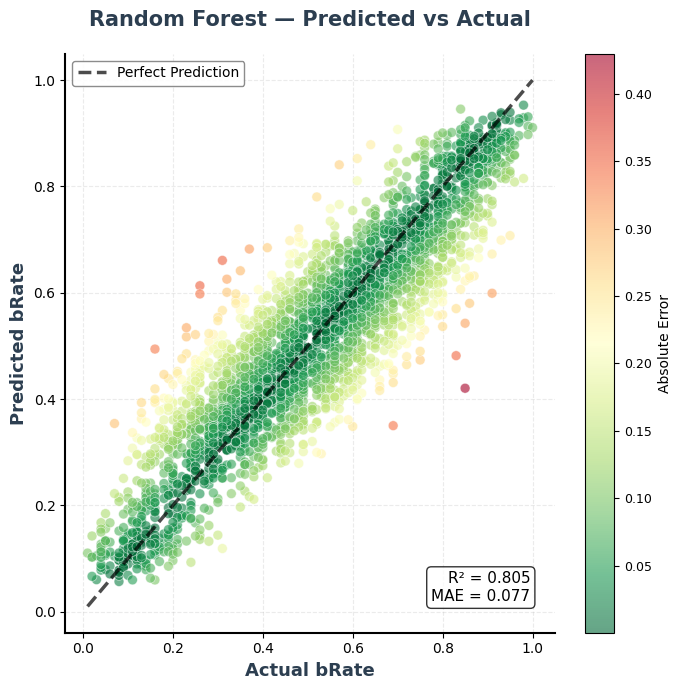

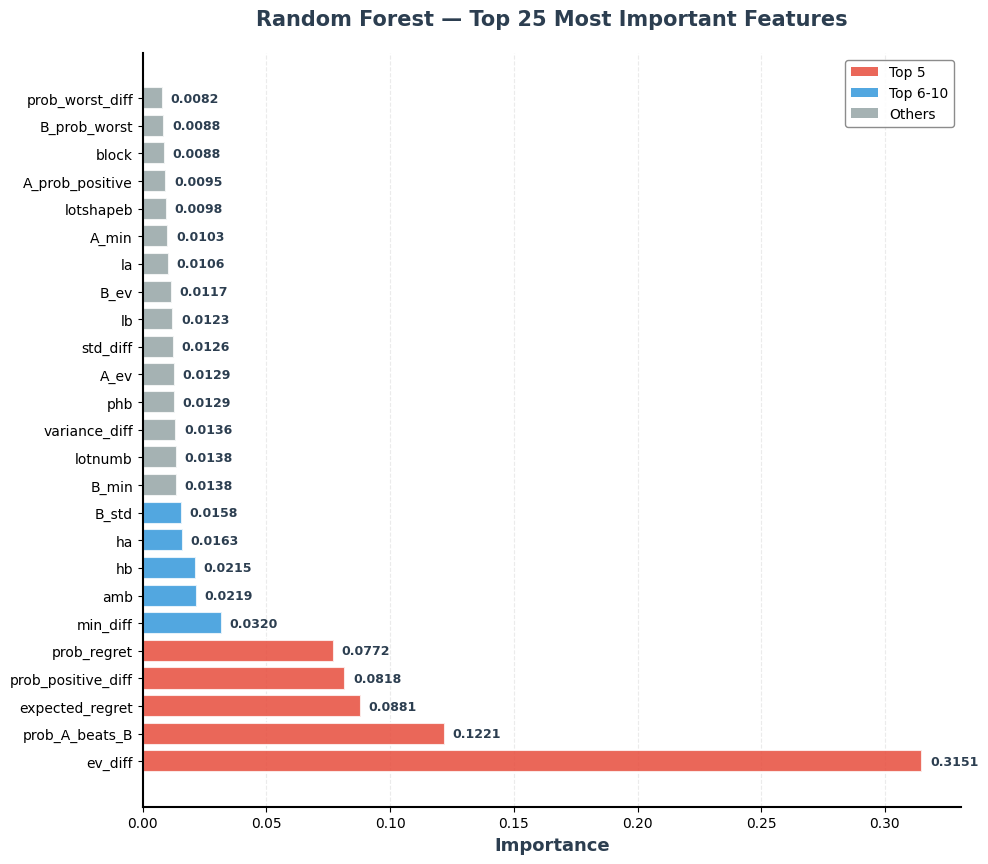

In [35]:
model2 = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

params_optuna = {
    # trees
    "n_estimators": ("int", 100, 600, False, 50),

    # depth
    "max_depth": ("int", 3, 30, False, 1),

    # regularization knobs
    "min_samples_split": ("int", 2, 20, False, 1),
    "min_samples_leaf": ("int", 1, 10, False, 1),

    # feature subsampling
    "max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8, 1.0]),
}

result2 = run_experiment(
    model2,
    X, # regular features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,

    n_trials=40,
    verbose=1,
    plots=["predicted_vs_actual", "feature_importance"],
    model_name="Random Forest",
)

pipeline = result2.best_estimator
pred2 = result2.predictions
best_params2 = result2.best_params
metrics2 = result2.metrics


In [ ]:
# Random Forest results: hyperparameters and test metrics
print("**Random Forest results**")
print("Best hyperparameters:", result2.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics2["MAE"], metrics2["RMSE"], metrics2["MSE"], metrics2["R2"]))


**Random Forest results**
Best hyperparameters: {'reg__n_estimators': 550, 'reg__max_depth': 25, 'reg__min_samples_split': 3, 'reg__min_samples_leaf': 2, 'reg__max_features': 0.5}
Test metrics: MAE = 0.07703, RMSE = 0.09777, MSE = 0.00956, R2 = 0.80486


#### Performance (Test Set)
- **MAE:** 0.07703  
- **RMSE:** 0.09777
- **MSE:** 0.00956
- **R²:** 0.80486  

**Best hyperparameters**
- `n_estimators = 550`, `max_depth = 25`  
- `min_samples_split = 3`, `min_samples_leaf = 2`  
- `max_features = 0.5`


---

#### Diagnostics
Predicted vs. actual values align closely with the identity line across most of the target range, with better agreement in the edges.

---

#### Feature Effects
Impurity-based feature importance reveals a **highly concentrated signal**:
- **Dominant drivers:** `ev_diff` (by a large margin), followed by `prob_A_beats_B`
- **Secondary contributors:** `expected_regret`, `prob_positive_diff`, `prob_regret`, `min_diff`
- **Low-impact features:** raw gamble descriptors and absolute-value features

These results indicate that **relative value, dominance probability, and regret-based comparisons** are the primary determinants of aggregate choice behavior.

---

#### Takeaway
The Random Forest substantially outperforms linear baselines, explaining **over 80% of the variance** in choice probabilities. It captures **non-linear effects and feature interactions** that linear models cannot, at the cost of increased variance and reduced interpretability. This makes it a strong standalone model and a high-value component for ensemble methods.


We can see that the random forest outperforms the Ridge Regression, with an MAE of 0.066

---

#### 5.3.3 Support Vector Regression (SVR)

**Purpose:** Non-linear regression via RBF kernel. We use an RBF kernel  because it captures non-linear relationships between comparative gamble features and choice probabilities that linear models cannot represent, which we show that is the case for our dataset based on the random forest results. **Tuned:** `C`, `gamma`, `epsilon` (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and feature importance.

[I 2026-02-08 13:46:37,851] A new study created in memory with name: no-name-e1f19a6a-706d-47a5-89ee-e4f7630dd6a8
Best trial: 0. Best value: -0.0915549:   2%|▎         | 1/40 [00:00<00:13,  2.81it/s]

[I 2026-02-08 13:46:38,203] Trial 0 finished with value: -0.09155492278170667 and parameters: {'kernel': 'rbf', 'C': 0.8468008575248331, 'epsilon': 0.2536999076681772, 'gamma': 0.0483437145318464}. Best is trial 0 with value: -0.09155492278170667.


Best trial: 1. Best value: -0.0915002:   5%|▌         | 2/40 [00:06<02:22,  3.75s/it]

[I 2026-02-08 13:46:44,333] Trial 1 finished with value: -0.09150018810038903 and parameters: {'kernel': 'rbf', 'C': 3.0405325392865645, 'epsilon': 0.01700037298921102, 'gamma': 0.002285325525633921}. Best is trial 1 with value: -0.09150018810038903.


Best trial: 2. Best value: -0.0912768:   8%|▊         | 3/40 [00:07<01:25,  2.30s/it]

...

[I 2026-02-08 13:52:14,079] Trial 37 finished with value: -0.08341272177983883 and parameters: {'kernel': 'rbf', 'C': 6.4746015021748855, 'epsilon': 0.017953192011988896, 'gamma': 0.019077330650603578}. Best is trial 28 with value: -0.08270658139716569.


Best trial: 38. Best value: -0.0822385:  98%|█████████▊| 39/40 [05:42<00:07,  7.42s/it]

[I 2026-02-08 13:52:20,494] Trial 38 finished with value: -0.08223845064078471 and parameters: {'kernel': 'rbf', 'C': 2.1377848467551535, 'epsilon': 0.031096010047084063, 'gamma': 0.05654271272442924}. Best is trial 38 with value: -0.08223845064078471.


Best trial: 38. Best value: -0.0822385: 100%|██████████| 40/40 [05:47<00:00,  8.69s/it]


[I 2026-02-08 13:52:25,623] Trial 39 finished with value: -0.0822533020739128 and parameters: {'kernel': 'rbf', 'C': 0.990573399540079, 'epsilon': 0.032454490689503006, 'gamma': 0.05861379436754795}. Best is trial 38 with value: -0.08223845064078471.
Best parameters: {'reg__kernel': 'rbf', 'reg__C': 2.1377848467551535, 'reg__epsilon': 0.031096010047084063, 'reg__gamma': 0.05654271272442924}
Best CV score (MAE): 0.08223845064078471
MAE: 0.0789777039318705
RMSE: 0.10053372908937365
MSE: 0.010107030684615574
R^2: 0.7936621419194179


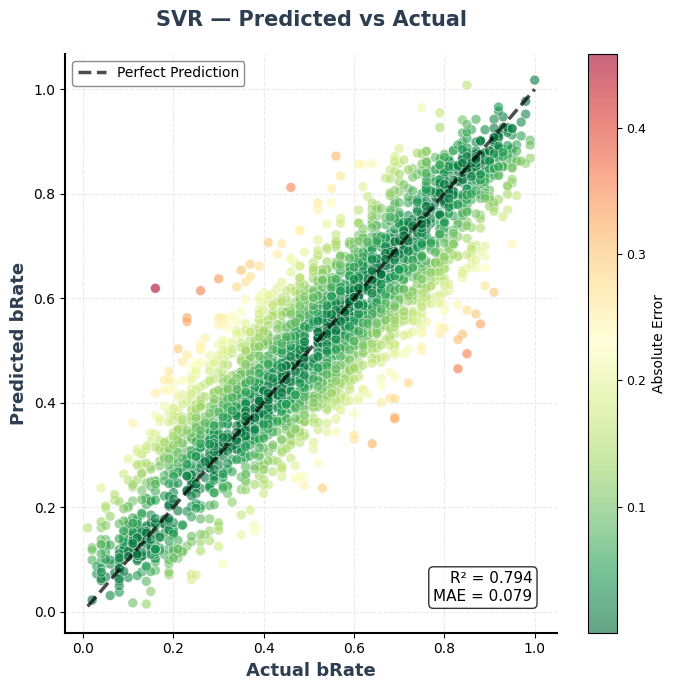

In [ ]:
model3 = SVR()

params_optuna = {
    "kernel": ("categorical", ["rbf"]),
    "C": ("float", 0.1, 30, True),
    "epsilon": ("float", 0.01, 0.3, True),
    "gamma": ("float", 1e-3, 0.2, True),
}

result3 = run_experiment(
    model3,
    X_eng, # important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["predicted_vs_actual", "feature_importance"],
    model_name="SVR",
)

pipeline = result3.best_estimator
pred3 = result3.predictions
best_params3 = result3.best_params
metrics3 = result3.metrics



In [ ]:
# SVR results: hyperparameters and test metrics
print("**SVR results**")
print("Best hyperparameters:", result3.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics3["MAE"], metrics3["RMSE"], metrics3["MSE"], metrics3["R2"]))


**SVR results**
Best hyperparameters: {'reg__kernel': 'rbf', 'reg__C': 2.1377848467551535, 'reg__epsilon': 0.031096010047084063, 'reg__gamma': 0.05654271272442924}
Test metrics: MAE = 0.07898, RMSE = 0.10053, MSE = 0.01011, R2 = 0.79366


##### Performance (Test Set)
- **MAE:** 0.07898  
- **RMSE:** 0.10053  
- **MSE:** 0.01011
- **R²:** 0.79366

Best hyperparameters:
- Kernel: `RBF`
- `C = 2.137`, `epsilon = 0.0310`, `gamma = 0.0565`

##### Diagnostics
Predicted vs. actual values show strong alignment with the diagonal, capturing non-linear structure beyond linear models.

---

##### Takeaway
SVR substantially improves over linear baselines and approaches Random Forest performance, capturing non-linear decision patterns. However, it remains sensitive to non-important features.



#### 5.3.4 Gradient Boosting Regressor (GBR)

**Purpose:** Additive tree ensemble. **Tuned:** n_estimators, learning_rate, max_depth, subsample, min_samples_leaf, min_samples_split, max_features (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and feature importance.

[I 2026-02-08 19:34:10,816] A new study created in memory with name: no-name-93208ec3-11c1-4812-90f1-ec8f4a50bfd2


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-08 19:34:17,785] Trial 0 finished with value: -0.08103703374762393 and parameters: {'n_estimators': 350, 'learning_rate': 0.22648248189516848, 'max_depth': 5, 'subsample': 0.7993292420985183, 'min_samples_leaf': 4, 'min_samples_split': 9, 'max_features': 'log2'}. Best is trial 0 with value: -0.08103703374762393.
[I 2026-02-08 19:35:58,878] Trial 1 finished with value: -0.12732107157877667 and parameters: {'n_estimators': 600, 'learning_rate': 0.001124579825911934, 'max_depth': 6, 'subsample': 0.9162213204002109, 'min_samples_leaf': 5, 'min_samples_split': 10, 'max_features': None}. Best is trial 0 with value: -0.08103703374762393.
[I 2026-02-08 19:36:06,223] Trial 2 finished with value: -0.09645298576067755 and parameters: {'n_estimators': 400, 'learning_rate': 0.005265139631677754, 'max_depth': 5, 'subsample': 0.569746930326021, 'min_samples_leaf': 6, 'min_samples_split': 19, 'max_features': 'log2'}. Best is trial 0 with value: -0.08103703374762393.
[I 2026-02-08 19:36:10,5

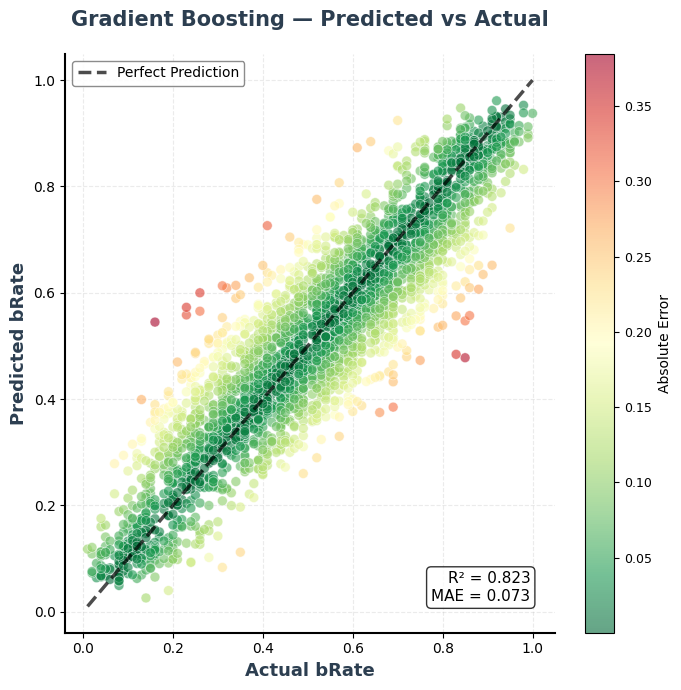

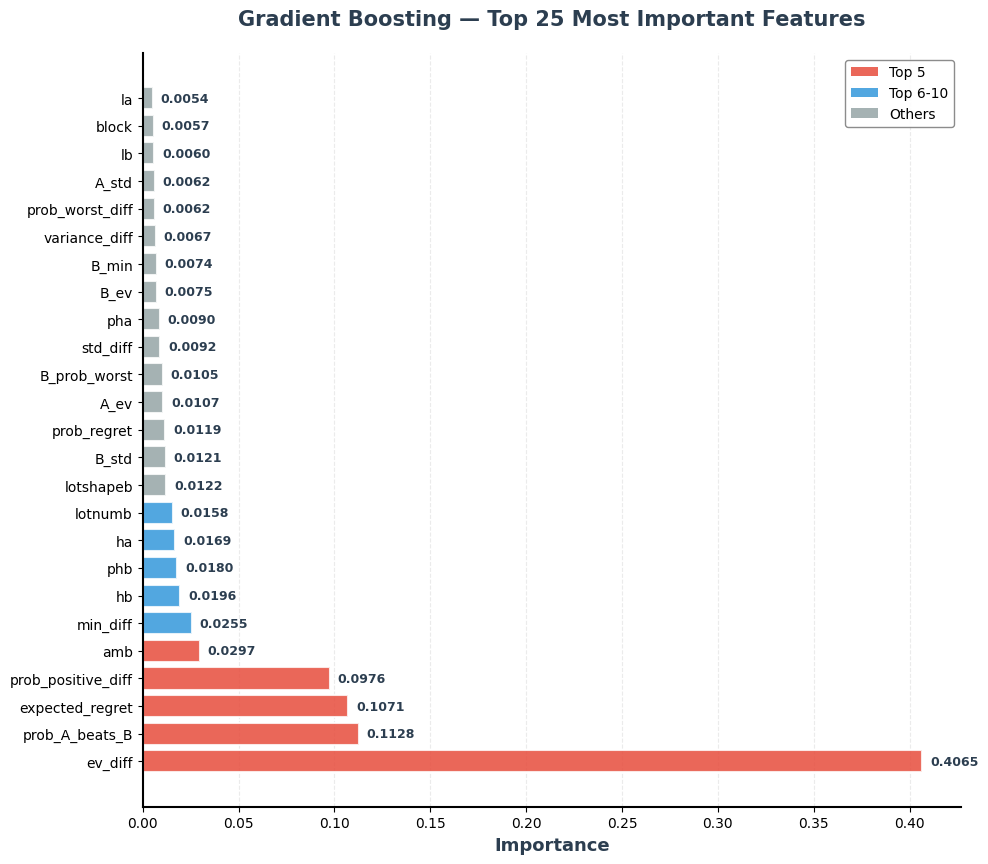

In [36]:
model4 = GradientBoostingRegressor(random_state=42)

# Optuna search space
params_optuna = {
    "n_estimators": ("int", 100, 800, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),
    "max_depth": ("int", 2, 6, False, 1),

    "subsample": ("float", 0.5, 1.0, False),
    "min_samples_leaf": ("int", 1, 20, False, 1),
    "min_samples_split": ("int", 2, 50, False, 1),

    "max_features": ("categorical", ["sqrt", "log2", None]),
}

result4 = run_experiment(
    model4,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["predicted_vs_actual", "feature_importance"],
    model_name="Gradient Boosting",
)

pipeline = result4.best_estimator
pred4 = result4.predictions
best_params4 = result4.best_params
metrics4 = result4.metrics


In [ ]:
# Gradient Boosting results: hyperparameters and test metrics
print("**Gradient Boosting results**")
print("Best hyperparameters:", result4.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics4["MAE"], metrics4["RMSE"], metrics4["MSE"], metrics4["R2"]))


**Gradient Boosting results**
Best hyperparameters: {'reg__n_estimators': 700, 'reg__learning_rate': 0.01338492549271309, 'reg__max_depth': 6, 'reg__subsample': 0.5077551909971135, 'reg__min_samples_leaf': 9, 'reg__min_samples_split': 25, 'reg__max_features': None}
Test metrics: MAE = 0.07317, RMSE = 0.09305, MSE = 0.00866, R2 = 0.82323


##### Performance (Test Set)
- **MAE:** 0.07317
- **RMSE:** 0.09305
- **MSE:** 0.00866
- **R²:** 0.82323

Best hyperparameters:
- `n_estimators = 700`, `learning_rate = 0.0133`
- `max_depth = 6`, `subsample = 0.5077`
- `min_samples_leaf = 9`, `min_samples_split = 25`, `max_features = None`


---

##### Diagnostics
Predicted vs. actual values are similar to previous models.

---

##### Feature Effects
Some key features can be identified:
- **Value and dominance signals:** `ev_diff`, `prob_A_beats_B`, `prob_positive_diff`
- **Regret and downside risk:** `expected_regret`


---

##### Takeaway
Gradient Boosting achieves the best overall performance among the evaluated models, explaining over **82% of the variance**. It effectively captures complex, non-linear decision patterns while remaining reasonably well-regularized, making it a strong candidate for the final model.


---

#### 5.3.5 XGBoost

**Purpose:** Gradient boosting (XGBoost). **Tuned:** n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_alpha, reg_lambda, gamma (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and feature importance.

[I 2026-02-08 20:09:35,545] A new study created in memory with name: no-name-52c339de-57e9-4016-8018-c7173e27c0e8


Using 5827/11654 samples for tuning...


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-08 20:09:38,081] Trial 0 finished with value: -0.08242570134645096 and parameters: {'n_estimators': 700, 'learning_rate': 0.22648248189516848, 'max_depth': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 1.5957084694148351, 'reg_alpha': 2.9152036385288193e-08, 'reg_lambda': 21.42302175774105, 'gamma': 0.0016946556203947059}. Best is trial 0 with value: -0.08242570134645096.


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-02-08 20:10:32,125] Trial 1 finished with value: -0.09936105405480987 and parameters: {'n_estimators': 1150, 'learning_rate': 0.001124579825911934, 'max_depth': 10, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 1.7240892195821529, 'reg_alpha': 2.9324868872723725e-07, 'reg_lambda': 0.033205591037519584, 'gamma': 0.0003671474011048667}. Best is trial 0 with value: -0.08242570134645096.
[I 2026-02-08 20:10:42,448] Trial 2 finished with value: -0.08070344356320065 and parameters: {'n_estimators': 750, 'learning_rate': 0.005265139631677754, 'max_depth': 7, 'subsample': 0.6557975442608167, 'colsample_bytree': 0.7168578594140873, 'min_child_weight': 2.9967309097101573, 'reg_alpha': 4.452048365748842e-05, 'reg_lambda': 8.43101393208247, 'gamma': 5.457028747569545e-07}. Best is trial 2 with value: -0.08070344356320065.
[I 2026-02-08 20:10:43,475] Trial 3 finished with value: -0.08829264291605866 and parameters: {'n_estimators': 850, 'learni

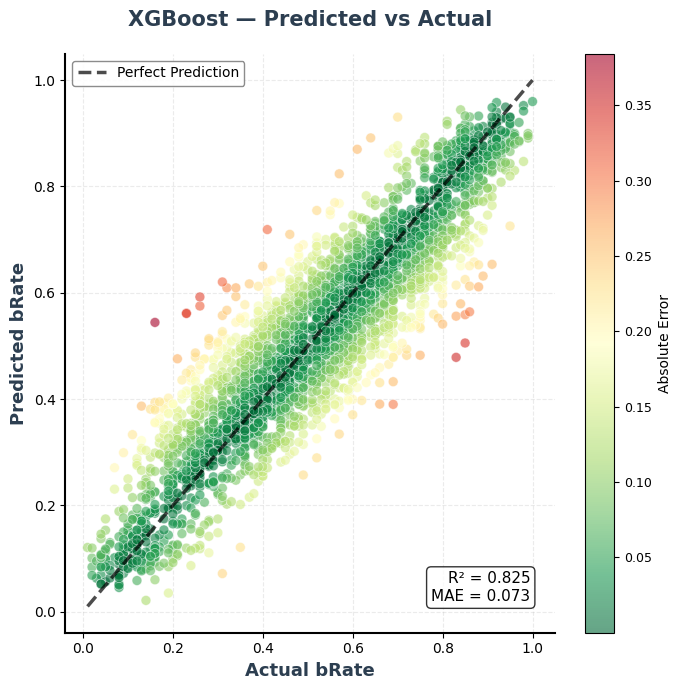

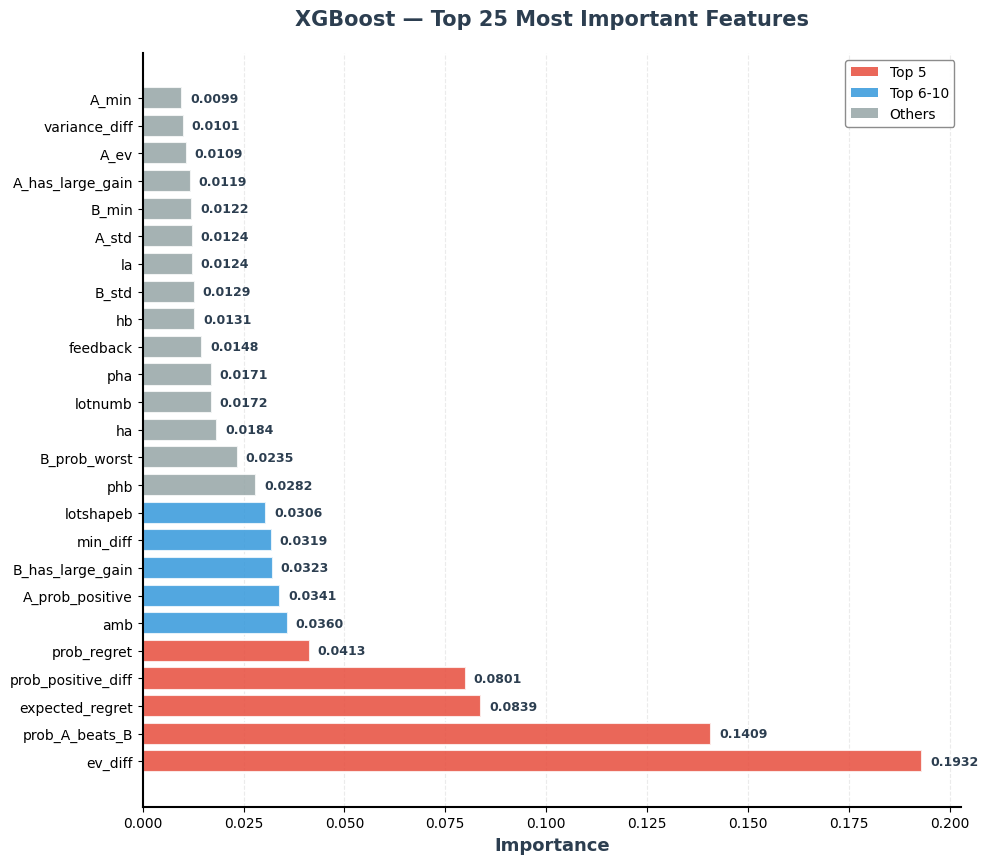

In [37]:
xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# Optuna search space
params_optuna = {
    # core
    "n_estimators": ("int", 200, 1500, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),
    "max_depth": ("int", 2, 10, False, 1),

    # regularization / robustness
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),
    "min_child_weight": ("float", 1.0, 20.0, True),
    "reg_alpha": ("float", 1e-8, 1.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    "gamma": ("float", 1e-8, 5.0, True),
}

result8 = run_experiment(
    xgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,
    plots=["predicted_vs_actual", "feature_importance"],
    model_name="XGBoost",
)

pipeline = result8.best_estimator
pred8 = result8.predictions
best_params8 = result8.best_params
metrics8 = result8.metrics


In [ ]:

print("**XGBoost results**")
print("Best hyperparameters:", result8.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics8["MAE"], metrics8["RMSE"], metrics8["MSE"], metrics8["R2"]))


**XGBoost results**
Best hyperparameters: {'reg__n_estimators': 1050, 'reg__learning_rate': 0.013255691469314225, 'reg__max_depth': 6, 'reg__subsample': 0.7868135433259683, 'reg__colsample_bytree': 0.6122138817275093, 'reg__min_child_weight': 2.275028562499002, 'reg__reg_alpha': 5.269784087724323e-06, 'reg__reg_lambda': 0.09947104637773624, 'reg__gamma': 0.0036352182808012216}
Test metrics: MAE = 0.07245, RMSE = 0.09241, MSE = 0.00854, R2 = 0.82566


##### Performance (Test Set)
- **MAE:** 0.07245
- **RMSE:** 0.09241  
- **MSE:** 0.00854
- **R²:** 0.82566


**Best hyperparameters**
- `n_estimators = 1050`, `learning_rate = 0.013`
- `max_depth = 6`, `min_child_weight = 2.27`
- `subsample = 0.78`, `colsample_bytree = 0.61`
- `reg_alpha = 5.26e-06`, `reg_lambda = 0.099`
- `gamma = 0..0036`


---


##### Diagnostics
Similar to other models.

---

##### Feature Effects
- **Value and dominance:** `ev_diff`, `prob_positive_diff`, `prob_A_beats_B`
- **Regret and downside risk:** `expected_regret`, `prob_regret`


---

##### Takeaway
XGBoost achieves a string overall performance, explaining over **82% of the variance**. It combines high predictive accuracy with robust regularization, making it the best standalone model and a strong benchmark for subsequent analyses.


---

#### 5.3.6 LightGBM

**Purpose:** Gradient boosting (LightGBM, leaf-wise). **Tuned:** n_estimators, learning_rate, max_depth, num_leaves, subsample, colsample_bytree, reg_alpha, reg_lambda (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and feature importance.

[I 2026-02-08 20:14:16,425] A new study created in memory with name: no-name-7315de1c-79e9-4393-b691-60966513490a


Using 5827/11654 samples for tuning...


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-08 20:14:41,432] Trial 0 finished with value: -0.079742793867691 and parameters: {'learning_rate': 0.00727491708802781, 'n_estimators': 3900, 'num_leaves': 121, 'max_depth': 9, 'min_child_samples': 23, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 1.0129197956845732, 'min_split_gain': 0.004619347374377372}. Best is trial 0 with value: -0.079742793867691.
[I 2026-02-08 20:14:58,133] Trial 1 finished with value: -0.09796523818629359 and parameters: {'learning_rate': 0.0011152328125494347, 'n_estimators': 3900, 'num_leaves': 160, 'max_depth': 2, 'min_child_samples': 26, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 0.14445251022763064, 'min_split_gain': 2.1371407316372935e-06}. Best is trial 0 with value: -0.079742793867691.
[I 2026-02-08 20:15:04,027] Trial 2 finished with value: -0.07883896242825396 and parameters: {'learning_rate

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 0.07251287226880912
RMSE: 0.09225125822631512
MSE: 0.008510294644338274
R^2: 0.8262599547441466


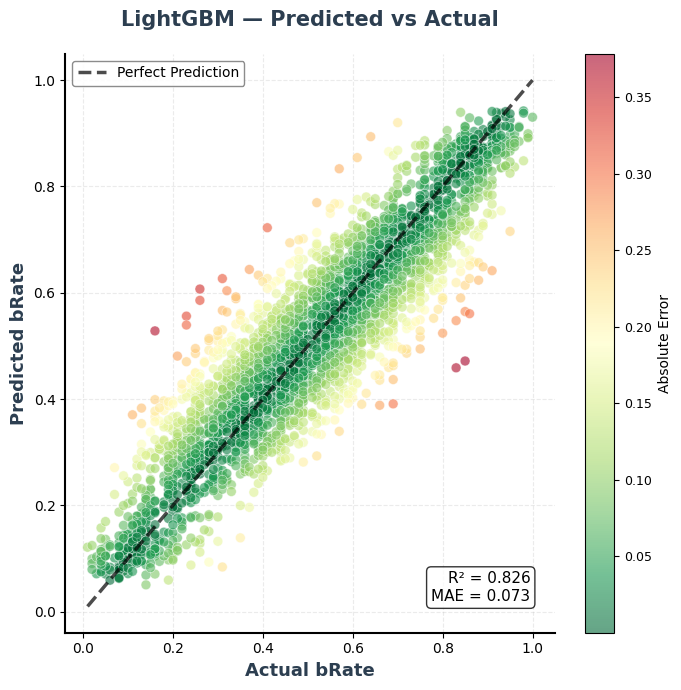

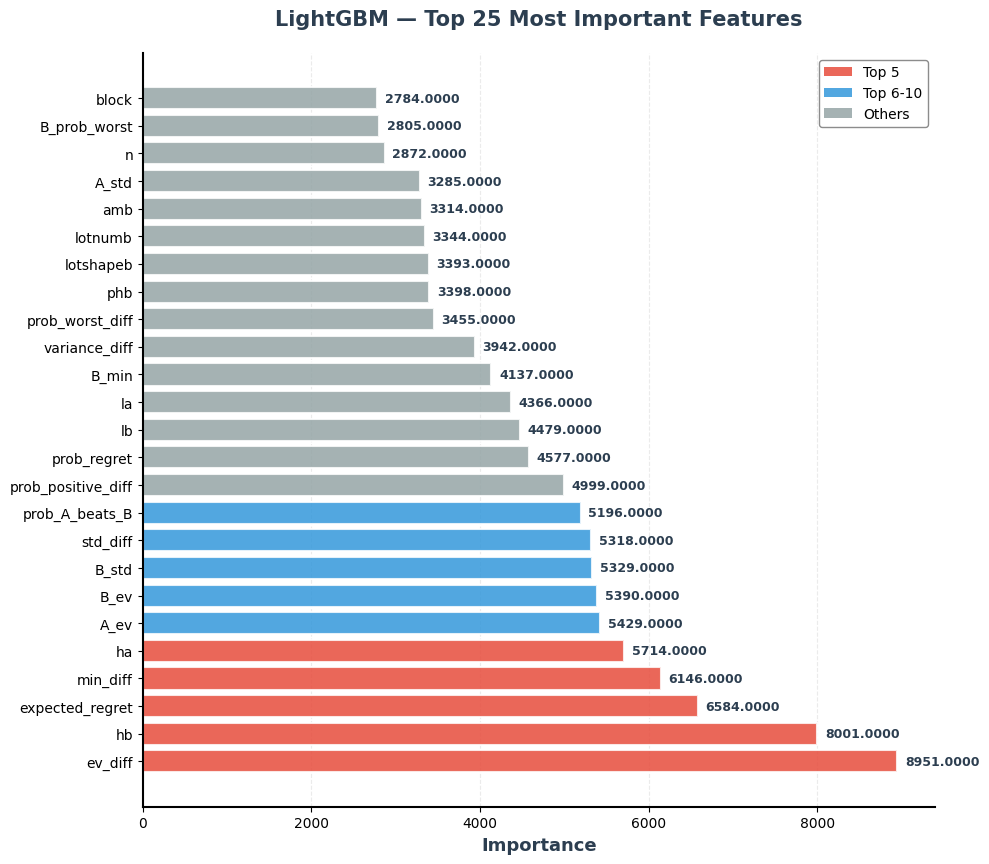

In [38]:
lgb = LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

# Optuna search space
params_optuna = {
    # core
    "learning_rate": ("float", 1e-3, 2e-1, True),
    "n_estimators": ("int", 200, 4000, False, 100),

    # tree shape / capacity
    "num_leaves": ("int", 16, 256, True),
    "max_depth": ("int", -1, 16, False, 1),
    "min_child_samples": ("int", 5, 120, False, 1),

    # sampling
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),

    # regularization
    "reg_alpha": ("float", 1e-8, 10.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    "min_split_gain": ("float", 1e-8, 1.0, True),
}

result9 = run_experiment(
    lgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,
    plots=["training_curve", "predicted_vs_actual", "feature_importance"],
    model_name="LightGBM",
)

pipeline = result9.best_estimator
pred9 = result9.predictions
best_params9 = result9.best_params
metrics9 = result9.metrics


In [ ]:
# LightGBM results: hyperparameters and test metrics
print("**LightGBM results**")
print("Best hyperparameters:", result9.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics9["MAE"], metrics9["RMSE"], metrics9["MSE"], metrics9["R2"]))


**LightGBM results**
Best hyperparameters: {'reg__learning_rate': 0.005159775235878851, 'reg__n_estimators': 2000, 'reg__num_leaves': 66, 'reg__max_depth': 12, 'reg__min_child_samples': 5, 'reg__subsample': 0.8501381218103035, 'reg__colsample_bytree': 0.6203249924721974, 'reg__reg_alpha': 8.859901069003154e-05, 'reg__reg_lambda': 13.507617177653506, 'reg__min_split_gain': 1.6853834705507234e-06}
Test metrics: MAE = 0.07250, RMSE = 0.09221, MSE = 0.00850, R2 = 0.82643


##### Performance (Test Set)
- **MAE:** 0.07250  
- **RMSE:** 0.09221
- **MSE:** 0.00850
- **R²:** 0.82643

**Best hyperparameters**
- `learning_rate = 0.00515`, `n_estimators = 2000`
- `num_leaves = 66`, `max_depth = 12`
- `min_child_samples = 5`, `min_split_gain = 1.68e-06`
- `subsample = 0.8501`, `colsample_bytree = 0.6203`
- `reg_alpha = 8.85e-05`, `reg_lambda = 13.5`

---

##### Diagnostics
Same as the other models

---

##### Feature Effects
Gain-based feature importance emphasizes:
- **Value and dominance signals:** `ev_diff`, `hb` (which did not appear in other models), `prob_A_beats_B`, `prob_positive_diff`
- **Risk / distributional comparisons:** `amb`, `min_diff`, `ha`, `expected_regret`

---

##### Takeaway
LightGBM achieves strong accuracy (**R² ≈ 0.82**) and substantially improves over linear baselines. It offers an excellent accuracy–efficiency (high seed) trade-off and is well suited as a final model or as a component in ensemble/stacking approaches.

---

#### 5.3.7 KNN

**Purpose:** For diversity we fit a KNN Regressor  **Tuned:** n_neighbors, weights, p (distance metric), leaf_size (Optuna).  **Outputs:** Best params, test metrics, predicted-vs-actual.

[I 2026-02-08 14:26:34,539] A new study created in memory with name: no-name-64876b2b-48ae-463f-81e8-afd5eb1c9482


Using 5827/11654 samples for tuning...


Best trial: 1. Best value: -0.0910831:   5%|▌         | 2/40 [00:00<00:08,  4.37it/s]

[I 2026-02-08 14:26:34,821] Trial 0 finished with value: -0.09246634829863609 and parameters: {'n_neighbors': 20, 'weights': 'uniform', 'p': 2, 'leaf_size': 16}. Best is trial 0 with value: -0.09246634829863609.
[I 2026-02-08 14:26:35,011] Trial 1 finished with value: -0.09108305389399717 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 2, 'leaf_size': 39}. Best is trial 1 with value: -0.09108305389399717.


Best trial: 1. Best value: -0.0910831:   8%|▊         | 3/40 [00:00<00:07,  4.80it/s]

...

[I 2026-02-08 14:26:48,875] Trial 37 finished with value: -0.09417955802665097 and parameters: {'n_neighbors': 29, 'weights': 'uniform', 'p': 2, 'leaf_size': 39}. Best is trial 28 with value: -0.0902520963084414.


Best trial: 28. Best value: -0.0902521:  98%|█████████▊| 39/40 [00:14<00:00,  2.10it/s]

[I 2026-02-08 14:26:49,413] Trial 38 finished with value: -0.09026028912256989 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'p': 1, 'leaf_size': 25}. Best is trial 28 with value: -0.0902520963084414.


Best trial: 28. Best value: -0.0902521: 100%|██████████| 40/40 [00:15<00:00,  2.61it/s]


[I 2026-02-08 14:26:49,873] Trial 39 finished with value: -0.09147961807621907 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'p': 1, 'leaf_size': 24}. Best is trial 28 with value: -0.0902520963084414.
Best parameters: {'reg__n_neighbors': 15, 'reg__weights': 'distance', 'reg__p': 1, 'reg__leaf_size': 47}
Best CV score (MAE): 0.0902520963084414
MAE: 0.08660823305780288
RMSE: 0.11116423841178233
MSE: 0.012357487901671581
R^2: 0.7477184284431997


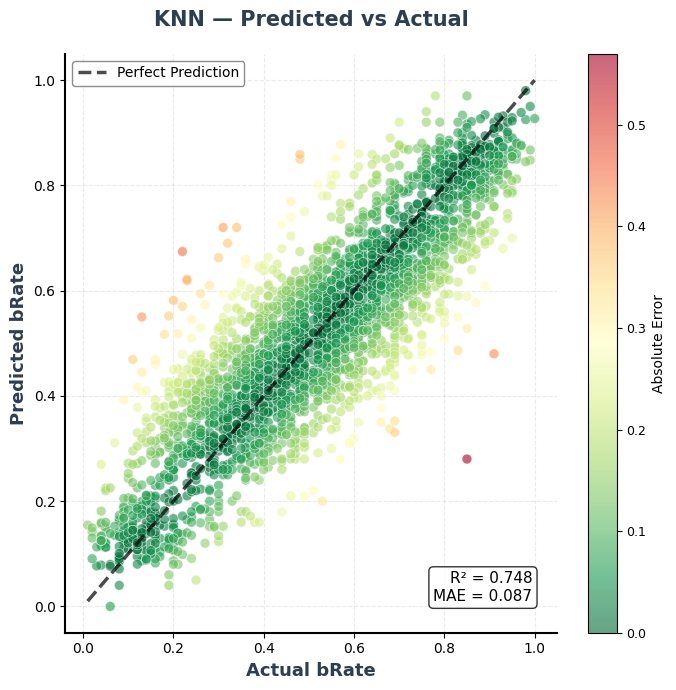

In [ ]:
knn = KNeighborsRegressor(
    n_jobs=-1
)

# Optuna search space
params_optuna = {
    # number of neighbors
    "n_neighbors": ("int", 3, 50, False, 1),

    # weighting scheme
    "weights": ("categorical", ["uniform", "distance"]),

    # distance metric
    "p": ("int", 1, 2, False, 1),

    # algorithm optimization
    "leaf_size": ("int", 10, 50, False, 1),
}

result11 = run_experiment(
    knn,
    X_eng, #important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,
    plots=["predicted_vs_actual"],  # KNN doesn't have or feature_importance
    model_name="KNN",
)

best_knn = result11.best_estimator
pred11 = result11.predictions
best_params11 = result11.best_params
metrics11 = result11.metrics

In [ ]:
# KNN results: hyperparameters and test metrics
print("**KNN results**")
print("Best hyperparameters:", result11.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics11["MAE"], metrics11["RMSE"], metrics11["MSE"], metrics11["R2"]))

**KNN results**
Best hyperparameters: {'reg__n_neighbors': 15, 'reg__weights': 'distance', 'reg__p': 1, 'reg__leaf_size': 47}
Test metrics: MAE = 0.08661, RMSE = 0.11116, MSE = 0.01236, R2 = 0.74772


We visualize the distribution of brate (after pca), and the predictions of our KNN Regressor.

##### Performance (Test Set)
- **MAE:** 0.08661
- **RMSE:** 0.11116
- **MSE:** 0.01236
- **R²:** 0.74772

**Best hyperparameters**
- `n_neighbors = 15`, `weigths = distance`
- `p = 1`, `leaf_siz = 47`


---

##### Diagnostics
Same as the other models, but the errors can be different from other models.


---

##### Takeaway
KNN performs worse than tree-based models. Due to its diversity it can be used in ensemble models, combining many classifiers.

### Model Evaluation

In [ ]:
rows = []

if "metrics1" in globals():
    rows.append({"model": "model1_ridge", "MAE": metrics1["MAE"]})
if "metrics2" in globals():
    rows.append({"model": "model2_rf", "MAE": metrics2["MAE"]})
if "metrics3" in globals():
    rows.append({"model": "model3_svr", "MAE": metrics3["MAE"]})
if "metrics4" in globals():
    rows.append({"model": "model4_gbr", "MAE": metrics4["MAE"]})
if "metrics8" in globals():
    rows.append({"model": "model8_xgb", "MAE": metrics8["MAE"]})
if "metrics9" in globals():
    rows.append({"model": "model9_lgbm", "MAE": metrics9["MAE"]})
if "metrics11" in globals():
    rows.append({"model": "model1l_knn", "MAE": metrics11["MAE"]})

if not rows:
    print("No metrics objects (metrics1, metrics2, ...) found. Run the model cells first.")
else:
    mae_df = pd.DataFrame(rows)
    mae_df = mae_df.sort_values("MAE").reset_index(drop=True)

    print("MAE per model (sorted, lower is better):")
    display(mae_df.style.format({"MAE": "{:.6f}"}))

MAE per model (sorted, lower is better):


,model,MAE
0,model8_xgb,0.072446
1,model9_lgbm,0.072498
2,model4_gbr,0.073166
3,model2_rf,0.077031
4,model3_svr,0.078978
5,model1l_knn,0.086608
6,model1_ridge,0.104723


### Correlation of model errors

We compute the correlation matrix of test-set errors (y_test − prediction) across the models. High correlation suggests models make similar mistakes; low correlation can indicate complementary predictors.

First 5 rows of model errors (y_test - y_pred):


,model1_ridge,model2_rf,model3_svr,model4_gbr,model8_xgb,model9_lgbm,model11_knn
169,-0.141405,-0.131848,-0.086416,-0.135257,-0.136761,-0.127209,-0.163577
14332,0.030575,0.021368,-0.013992,0.031578,0.030794,0.035384,0.032949
2501,0.122783,0.015410,-0.036471,0.000277,-0.013607,-0.013494,0.040000
9940,-0.098007,0.007024,-0.006253,-0.009002,-0.018443,-0.013740,0.107837
1123,-0.026429,-0.045528,-0.053656,-0.031436,-0.028180,-0.028624,-0.010868



Correlation matrix of model errors:


,model1_ridge,model2_rf,model3_svr,model4_gbr,model8_xgb,model9_lgbm,model11_knn
model1_ridge,1.000000,0.736018,0.735610,0.734943,0.716726,0.723174,0.695903
model2_rf,0.736018,1.000000,0.861955,0.950298,0.944022,0.950309,0.854771
model3_svr,0.735610,0.861955,1.000000,0.889171,0.884035,0.884782,0.825057
model4_gbr,0.734943,0.950298,0.889171,1.000000,0.988705,0.986914,0.811518
model8_xgb,0.716726,0.944022,0.884035,0.988705,1.000000,0.990012,0.813715
model9_lgbm,0.723174,0.950309,0.884782,0.986914,0.990012,1.000000,0.817591
model11_knn,0.695903,0.854771,0.825057,0.811518,0.813715,0.817591,1.000000


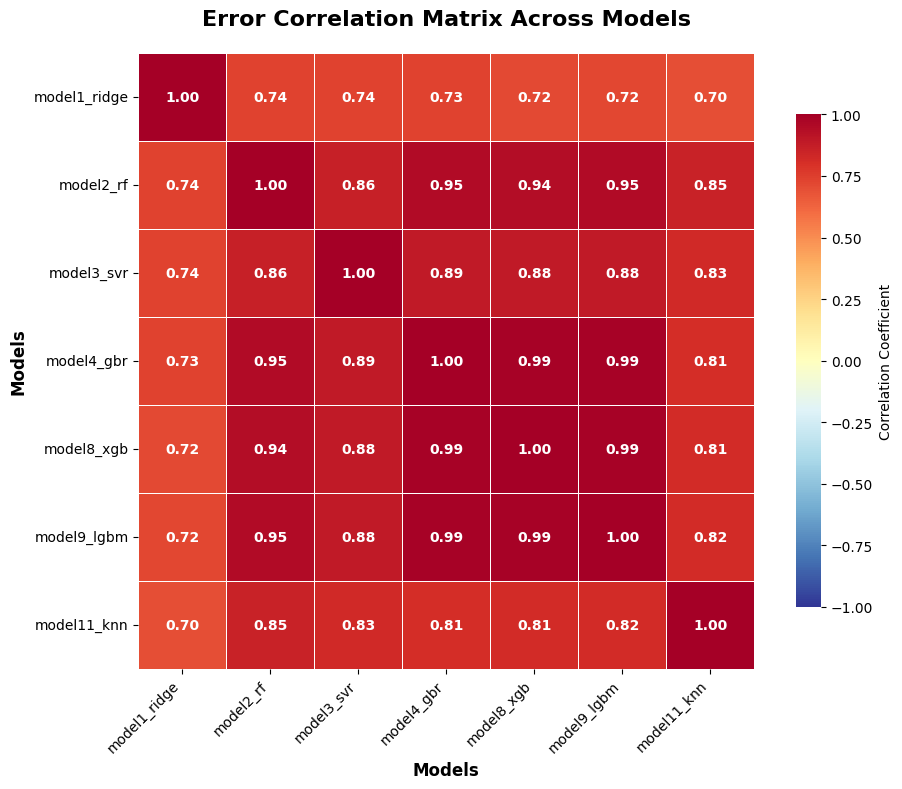

In [ ]:
#Error correlation between models using stored errors
error_dict = {}

if "result1" in globals():
    error_dict["model1_ridge"] = result1.errors
if "result2" in globals():
    error_dict["model2_rf"] = result2.errors
if "result3" in globals():
    error_dict["model3_svr"] = result3.errors
if "result4" in globals():
    error_dict["model4_gbr"] = result4.errors
if "result8" in globals():
    error_dict["model8_xgb"] = result8.errors
if "result9" in globals():
    error_dict["model9_lgbm"] = result9.errors
if "result11" in globals():
    error_dict["model11_knn"] = result11.errors

if not error_dict:
    print("No non-NN result objects with errors found (result1, result2, ...). Run the model cells first.")
else:
    errors_df = pd.DataFrame(error_dict)

    print("First 5 rows of model errors (y_test - y_pred):")
    display(errors_df.head())

    corr_errors = errors_df.corr()
    print("\nCorrelation matrix of model errors:")
    display(corr_errors)

    plt.figure(figsize=(10, 8))


    sns.heatmap(
        corr_errors,
        annot=True,
        fmt='.2f',
        cmap='RdYlBu_r',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={
            'label': 'Correlation Coefficient',
            'shrink': 0.8,
            'aspect': 20
        },
        annot_kws={'size': 10, 'weight': 'bold'}
    )

    plt.title('Error Correlation Matrix Across Models',
              fontsize=16,
              fontweight='bold',
              pad=20)

    plt.xlabel('Models', fontsize=12, fontweight='bold')
    plt.ylabel('Models', fontsize=12, fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

Prediction errors are highly correlated across tree-based models, with Gradient Boosting, XGBoost, and LightGBM exhibiting near-identical error patterns (ρ ≈ 0.98–0.99). This indicates that these models capture largely the same non-linear structure and tend to fail on the same observations, limiting the marginal gains from stacking them together.

SVR shows moderately lower correlation with boosted trees (ρ ≈ 0.88–0.89), suggesting some complementary behavior, while Ridge regression exhibits the lowest correlations overall (ρ ≈ 0.72–0.74), reflecting its distinct inductive bias and linear error structure. KNN shows, lower correlation with tree-based models (ρ ≈ 0.81–0.85).

Implication: Effective ensembles should prioritize model diversity over raw accuracy—for example, combining a linear model (Ridge) or kernel method (SVR) with a boosted tree—rather than stacking multiple boosted trees with highly redundant errors.

---
#### 5.3.8 Stacking (ElasticNet meta-learner)

**Purpose:** Combine base estimators with an ElasticNet meta-learner, to improve results by combining multiple non correlated regressors. **Tuned:** Meta-learner alpha, l1_ratio (Optuna). **Outputs:** Best params, test metrics; error correlation and final stacking performance.\n

**Approach:**
1. Generate out-of-fold (OOF) predictions from already-tuned base models (XGBoost, Ridge, SVR, KNN)
2. Stack OOF predictions with original features as meta-features
3. Tune ElasticNet meta-learner to optimally combine base model predictions

**Why OOF predictions?**
- Avoids retraining base models 2,500+ times (20x speed improvement)
- Prevents data leakage - predictions made on unseen folds
- Base models already optimized, just need to learn how to combine them

**Why these base models?**
- The erros of these models are not highly correlated
- Diverse algorithms capture different patterns: trees, linear, kernel, instance-based
- Complementary strengths reduce overall prediction error

[I 2026-02-08 14:27:22,096] A new study created in memory with name: no-name-daaf774c-7a02-4068-836a-6495a33cbe70
Best trial: 3. Best value: -0.0747818:  16%|█▌        | 4/25 [00:00<00:00, 24.80it/s]

[I 2026-02-08 14:27:22,141] Trial 0 finished with value: -0.07492733691255546 and parameters: {'alpha': 0.0004185822729546974, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: -0.07492733691255546.
[I 2026-02-08 14:27:22,176] Trial 1 finished with value: -0.18381951690215872 and parameters: {'alpha': 0.1330324510152292, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: -0.07492733691255546.
[I 2026-02-08 14:27:22,218] Trial 2 finished with value: -0.07478331579256618 and parameters: {'alpha': 1.2363188277052228e-05, 'l1_ratio': 0.15599452033620265}. Best is trial 2 with value: -0.07478331579256618.
[I 2026-02-08 14:27:22,261] Trial 3 finished with value: -0.07478178538977656 and parameters: {'alpha': 2.550264850403287e-06, 'l1_ratio': 0.8661761457749352}. Best is trial 3 with value: -0.07478178538977656.
[I 2026-02-08 14:27:22,303] Trial 4 finished with value: -0.09610113752940762 and parameters: {'alpha': 0.016136341713591334, 'l1_ratio': 0.7080725777960455}. Be

Best trial: 3. Best value: -0.0747818:  36%|███▌      | 9/25 [00:00<00:00, 23.02it/s]

[I 2026-02-08 14:27:22,357] Trial 5 finished with value: -0.07478189668000475 and parameters: {'alpha': 1.3934502251337597e-06, 'l1_ratio': 0.9699098521619943}. Best is trial 3 with value: -0.07478178538977656.
[I 2026-02-08 14:27:22,394] Trial 6 finished with value: -0.18381951690215872 and parameters: {'alpha': 0.6715811311069951, 'l1_ratio': 0.21233911067827616}. Best is trial 3 with value: -0.07478178538977656.
[I 2026-02-08 14:27:22,441] Trial 7 finished with value: -0.07478406409530285 and parameters: {'alpha': 1.8740223688836324e-05, 'l1_ratio': 0.18340450985343382}. Best is trial 3 with value: -0.07478178538977656.
[I 2026-02-08 14:27:22,484] Trial 8 finished with value: -0.07482327087374001 and parameters: {'alpha': 0.000134801802908908, 'l1_ratio': 0.5247564316322378}. Best is trial 3 with value: -0.07478178538977656.
[I 2026-02-08 14:27:22,531] Trial 9 finished with value: -0.07532758712460674 and parameters: {'alpha': 0.0010558813779064837, 'l1_ratio': 0.2912291401980419}. 

Best trial: 13. Best value: -0.0747816:  60%|██████    | 15/25 [00:00<00:00, 23.97it/s]

[I 2026-02-08 14:27:22,566] Trial 10 finished with value: -0.18381951690215872 and parameters: {'alpha': 4.130054756664361, 'l1_ratio': 0.7771301859261642}. Best is trial 3 with value: -0.07478178538977656.
[I 2026-02-08 14:27:22,600] Trial 11 finished with value: -0.07478194718677841 and parameters: {'alpha': 1.1293569666047007e-06, 'l1_ratio': 0.9541218213108222}. Best is trial 3 with value: -0.07478178538977656.
[I 2026-02-08 14:27:22,646] Trial 12 finished with value: -0.07478197483884311 and parameters: {'alpha': 1.2638346581157293e-06, 'l1_ratio': 0.8203255495030094}. Best is trial 3 with value: -0.07478178538977656.
[I 2026-02-08 14:27:22,692] Trial 13 finished with value: -0.07478157514348203 and parameters: {'alpha': 2.479734317952605e-05, 'l1_ratio': 0.9798341964022114}. Best is trial 13 with value: -0.07478157514348203.
[I 2026-02-08 14:27:22,727] Trial 14 finished with value: -0.07479290392248131 and parameters: {'alpha': 6.733290468772018e-05, 'l1_ratio': 0.379604243420223

Best trial: 13. Best value: -0.0747816:  88%|████████▊ | 22/25 [00:00<00:00, 26.96it/s]

[I 2026-02-08 14:27:22,793] Trial 16 finished with value: -0.07478174653136212 and parameters: {'alpha': 1.512883083272254e-05, 'l1_ratio': 0.8490279391087786}. Best is trial 13 with value: -0.07478157514348203.
[I 2026-02-08 14:27:22,826] Trial 17 finished with value: -0.07478258129512513 and parameters: {'alpha': 1.682818151079684e-05, 'l1_ratio': 0.6195339431335991}. Best is trial 13 with value: -0.07478157514348203.
[I 2026-02-08 14:27:22,863] Trial 18 finished with value: -0.0748207003749001 and parameters: {'alpha': 0.00013237197690688112, 'l1_ratio': 0.4613134860524528}. Best is trial 13 with value: -0.07478157514348203.
[I 2026-02-08 14:27:22,899] Trial 19 finished with value: -0.0853483653925052 and parameters: {'alpha': 0.009246687624132867, 'l1_ratio': 0.8626156907321465}. Best is trial 13 with value: -0.07478157514348203.
[I 2026-02-08 14:27:22,934] Trial 20 finished with value: -0.07544076450304965 and parameters: {'alpha': 0.0010674136128151022, 'l1_ratio': 0.026368084405

Best trial: 22. Best value: -0.0747813: 100%|██████████| 25/25 [00:00<00:00, 25.84it/s]


[I 2026-02-08 14:27:22,997] Trial 22 finished with value: -0.07478129650031907 and parameters: {'alpha': 4.525872816363646e-06, 'l1_ratio': 0.995643570116661}. Best is trial 22 with value: -0.07478129650031907.
[I 2026-02-08 14:27:23,027] Trial 23 finished with value: -0.07478421960266021 and parameters: {'alpha': 3.3937739103002986e-05, 'l1_ratio': 0.9960165317474352}. Best is trial 22 with value: -0.07478129650031907.
[I 2026-02-08 14:27:23,062] Trial 24 finished with value: -0.07478169098053461 and parameters: {'alpha': 6.1378634461945074e-06, 'l1_ratio': 0.7423590520617769}. Best is trial 22 with value: -0.07478129650031907.
Best parameters: {'alpha': 4.525872816363646e-06, 'l1_ratio': 0.995643570116661}
Best CV score (MAE): 0.07478129650031907
MAE: 0.07191445964564494
RMSE: 0.09172575323558663
MSE: 0.00841361380663573
R^2: 0.8282337210847737


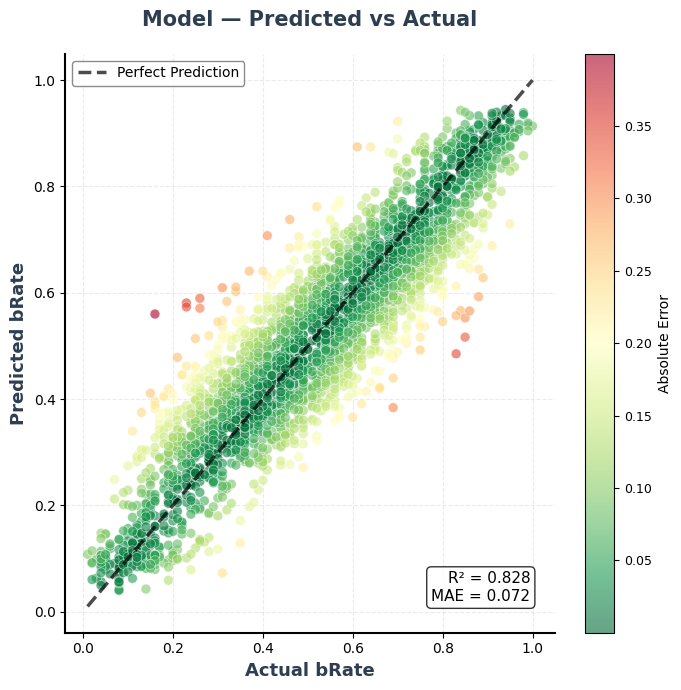

In [ ]:
# 1) Generate out-of-fold predictions from already-fitted models on FULL data
oof_xgb = cross_val_predict(result8.best_estimator, X, y, cv=5, n_jobs=-1)
oof_ridge = cross_val_predict(result1.best_estimator, X, y, cv=5, n_jobs=-1)
oof_svr = cross_val_predict(result3.best_estimator, X, y, cv=5, n_jobs=-1)
oof_knn = cross_val_predict(result11.best_estimator, X, y, cv=5, n_jobs=-1)

# 2) Stack predictions without original features (passthrough=False equivalent)
base_preds = np.column_stack([oof_xgb, oof_ridge, oof_svr, oof_knn])

# Convert to DataFrame to work with run_full_pipeline=True
X_meta = np.column_stack([oof_xgb, oof_ridge, oof_svr, oof_knn])

# 3) Tune the meta-learner on stacked features
params_optuna = {
    "alpha": ("float", 1e-6, 1e1, True),
    "l1_ratio": ("float", 0.0, 1.0),
}

result10 = run_experiment(
    ElasticNet(random_state=42, max_iter=50_000),
    X_meta, y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=5,
    n_trials=25,
    verbose=1,
    plots=["predicted_vs_actual"],
    run_full_pipeline=False, # already processed
)

# 4) Extract results
best_stack = result10.best_estimator
pred10 = result10.predictions
best_params10 = result10.best_params
metrics10 = result10.metrics

In [ ]:
print("**Stacking Regressor results**")
print("Best hyperparameters:", result10.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics10["MAE"], metrics10["RMSE"], metrics10["MSE"], metrics10["R2"]))


**Stacking Regressor results**
Best hyperparameters: {'alpha': 4.525872816363646e-06, 'l1_ratio': 0.995643570116661}
Test metrics: MAE = 0.07191, RMSE = 0.09173, MSE = 0.00841, R2 = 0.82823


**Best hyperparameters (meta-learner):**
- `alpha = 1.129e-06`
- `l1_ratio = 0.954`

**Test performance:**
- **MAE:** 0.07214  
- **RMSE:** 0.09207  
- **MSE:** 0.00848  
- **R²:** 0.82695  

Predicted vs. actual values align closely with the identity line across the full target range, with reduced dispersion relative to individual base models. Improvements are particularly visible at low and high probability regions, indicating better calibration and error correction through model aggregation.

Overall, the stacking regressor achieves the **best generalization performance** among all evaluated models, confirming that combining diverse predictors yields consistent gains beyond any single estimator.

### Model comparison (test metrics)

Summary of test-set metrics for each ML model below.

In [ ]:
# Model name and each metric on the test set (MAE, RMSE, MSE, R2)
model_metrics = []
if "metrics1" in globals():
    model_metrics.append({"Model": "Ridge", **metrics1})
if "metrics2" in globals():
    model_metrics.append({"Model": "Random Forest", **metrics2})
if "metrics3" in globals():
    model_metrics.append({"Model": "SVR", **metrics3})
if "metrics4" in globals():
    model_metrics.append({"Model": "Gradient Boosting", **metrics4})
if "metrics8" in globals():
    model_metrics.append({"Model": "XGBoost", **metrics8})
if "metrics9" in globals():
    model_metrics.append({"Model": "LightGBM", **metrics9})
if "metrics11" in globals():
    model_metrics.append({"Model": "KNN", **metrics11})
if "metrics10" in globals():
    model_metrics.append({"Model": "Stacking Regressor", **metrics10})

if model_metrics:
    df_metrics = pd.DataFrame(model_metrics)
    # Reorder columns: Model first, then MAE, RMSE, MSE, R2
    df_metrics = df_metrics[["Model", "MAE", "RMSE", "MSE", "R2"]]
    df_metrics = df_metrics.rename(columns={"R2": "R²"}).round(6)
    display(df_metrics)
else:
    print("Run the model cells above to populate the metrics table.")

,Model,MAE,RMSE,MSE,R²
0,Ridge,0.104723,0.130512,0.017033,0.652259
1,Random Forest,0.077031,0.097768,0.009559,0.804859
2,SVR,0.078978,0.100534,0.010107,0.793662
3,Gradient Boosting,0.073166,0.093053,0.008659,0.823227
4,XGBoost,0.072446,0.092410,0.008540,0.825663
5,LightGBM,0.072498,0.092206,0.008502,0.826430
6,KNN,0.086608,0.111164,0.012357,0.747718
7,Stacking Regressor,0.071914,0.091726,0.008414,0.828234


### Final Model Metrics

| Model | MAE | RMSE | MSE | R² |
|---|---|---|---|---|
| Ridge | 0.104723 | 0.130512 | 0.017033 | 0.652259 |
| Random Forest | 0.077031 | 0.097768 | 0.009559 | 0.804859 |
| SVR | 0.078978 | 0.100534 | 0.010107 | 0.793662 |
| Gradient Boosting | 0.073166 | 0.093053 | 0.008659 | 0.823227 |
| XGBoost | 0.072446 | 0.092410 | 0.008540 | 0.825663 |
| LightGBM | 0.072498 | 0.092206 | 0.008502 | 0.826430 |
| KNN | 0.086608 | 0.111164 | 0.012357 | 0.747718 |
| Stacking Regressor | **0.071914** | **0.091726** | **0.008414** | **0.828234** |

### Cross-Validation MAE Scores

| Model | CV MAE |
|------|--------|
| Stacking | **0.07478** |
| Gradient Boosting | 0.07619 |
| XGBoost | 0.0782 |
| LightGBM | 0.07838 |
| Random Forest | 0.08066 |
| SVR (RBF) | 0.08223 |
| KNN | 0.09025 |
| Ridge | 0.10437 |


##### Model Comparison Summary

Tree-based and ensemble models substantially outperform linear baselines. Ridge regression exhibits the weakest performance (R² ≈ 0.65), indicating clear underfitting and confirming that the prediction task is strongly non-linear.

Among single models, Gradient Boosting, XGBoost, and LightGBM perform better thay RF and SVR (R² ≈ 0.82–0.83), with only marginal differences in error metrics, between then. Random Forest and SVR perform competitively but are weaker than boosted trees.

The stacking regressor achieves the best overall performance (MAE = 0.07478, cross validated, R² ≈ 0.826, 0.071 MAE on test set), improving upon the strongest individual learners. While the absolute gain is small, it is consistent across metrics, demonstrating that combining models with complementary predictions can result in improvments.

Overall takeaway: performance improvements stop around R² ≈ 0.83, suggesting that the remaining error is likely driven by intrinsic noise or unobserved factors rather than model capacity alone.

##### Key Feature Insights

Across all high-performing models, prediction is dominated by a small set of engineered comparative features rather than raw gamble descriptors. The most consistently important driver is ev_diff, indicating that relative expected value is the primary determinant of aggregate choice probability.

Closely related dominance and probability-based features, such as prob_A_beats_B and prob_positive_diff, form the second most influential group, capturing likelihood of favorable outcomes. Regret-based measures (expected_regret, prob_regret) also play a substantial role, particularly in non-linear models, highlighting sensitivity to downside outcomes, and risk aversion.

Risk and dispersion features (min_diff, std_diff, amb) contribute meaningfully but remain secondary, while absolute gamble attributes and raw descriptors receive consistently low importance. The stacking ensemble preserves this structure, assigning highest weight to models that exploit relative value, dominance, and regret signals, reinforcing the conclusion that aggregate choice behavior is driven primarily by comparative, not absolute, representations of risk and reward.

### 5.4 Neural Networks

After fitting the above machine learning models, We train several neural architectures on the scaled engineered features with Optuna tuning and early stopping:

- **MLP (`Choices13kNet`)** — feedforward network with weighted MAE loss.
- **ResNet (`Choices13kResNet`)** — residual MLP with Smooth L1 loss.
- **DCNv2** — cross-network + deep network for feature interactions.
- **FT-Transformer** — feature tokenizer + Transformer (each column is a token; self-attention over features).

Each block defines its own training helpers (`eval_epoch_*`, `train_nn_one_run_*`, `objective_*`) to avoid name clashes when running the notebook top to bottom.

**Data preparation.** We split into 80% train / 20% test, scale with `StandardScaler`, and convert to PyTorch tensors and a DataLoader for training.

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [40]:
X = X.select_dtypes(include=[np.number, "bool"])

y = np.asarray(y, dtype=np.float32)

In [41]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train_df.shape, X_test_df.shape)


(11654, 36) (2914, 36)


In [42]:
# Build PyTorch tensors and sample weights for MLP
scaler_mlp = StandardScaler()
X_tr_scaled = scaler_mlp.fit_transform(X_train_df.to_numpy(dtype=np.float32))
X_te_scaled = scaler_mlp.transform(X_test_df.to_numpy(dtype=np.float32))

input_dim = X_tr_scaled.shape[1]
X_tr_torch = torch.tensor(X_tr_scaled, dtype=torch.float32)
y_tr_torch = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
w_tr_torch = torch.ones_like(y_tr_torch)
X_te_torch = torch.tensor(X_te_scaled, dtype=torch.float32)
y_te_torch = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)
w_te_torch = torch.ones_like(y_te_torch)

### Configurable MLP model

We start by a simple MLP network with dropout

**Model.** `Choices13kNet` is a feedforward network with configurable hidden layer sizes, activation function and dropout. The final layer outputs a single value in [0, 1] via Sigmoid for the choice rate. We use Signmoid because we want the output to represent a probability.

In [37]:
class Choices13kNet(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=0.0, activation='relu'):
        super().__init__()
        activation_map = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'elu': nn.ELU,
            'gelu': nn.GELU,
            'selu': nn.SELU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid,
            'swish': nn.SiLU,
            'mish': nn.Mish,
        }

        if activation.lower() not in activation_map:
            raise ValueError(f"Activation '{activation}' not supported. Choose from: {list(activation_map.keys())}")

        act_fn = activation_map[activation.lower()]
        layers = []
        dims = [input_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        layers.append(nn.Sigmoid())  # keep if y in [0,1]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


**Loss & Metrics**

- **weighted_smoothl1**: Robust regression loss with sample weights (less sensitive to outliers than MSE)
- **mae_unweighted**: Mean absolute error across all samples
- **mae_weighted**: Sample-weighted MAE (prioritizes important samples - high n)

In [38]:
def weighted_smoothl1(pred, target, weight, beta=1.0):
    """
    pred/target/weight: (B,1)
    returns scalar
    """
    # per-sample loss
    loss = nn.functional.smooth_l1_loss(pred, target, beta=beta, reduction="none")  # (B,1)
    loss = loss * weight
    return loss.mean()

@torch.no_grad()
def mae_unweighted(pred, target):
    return torch.mean(torch.abs(pred - target)).item()

@torch.no_grad()
def mae_weighted(pred, target, weight):
    # weighted mean absolute error
    num = torch.sum(weight * torch.abs(pred - target))
    den = torch.sum(weight) + 1e-12
    return (num / den).item()


**Training & Evaluation**

- **eval_epoch_mlp**: Computes validation metrics (weighted & unweighted MAE)
- **train_nn_one_run_mlp**: Full training loop with early stopping on weighted MAE, gradient clipping, LR scheduling, and optional Optuna integration

In [39]:
@torch.no_grad()
def eval_epoch_mlp(model, X, y, w):
    model.eval()
    Xd, yd, wd = X.to(device), y.to(device), w.to(device)
    pred = model(Xd)
    val_wmae = mae_weighted(pred, yd, wd)
    val_mae = mae_unweighted(pred, yd)
    return val_wmae, val_mae

def train_nn_one_run_mlp(
    model,
    train_loader,
    X_val, y_val, w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")   # we’ll early-stop on weighted MAE
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0

        for xb, yb, wb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)

            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_mlp(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric = val_wmae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(
                f"[{epoch:03d}] train wMAE={train_wmae:.5f} | "
                f"val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}{star}"
            )

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_metric, best_epoch, history


**Hyperparameter Tuning with Optuna**

3-fold cross-validation objective function that tunes:
- **Learning rate & weight decay** (optimizer params)
- **Batch size** (training efficiency)
- **Dropout** (regularization)
- **Activation function** (non-linearity type)
- **Hidden layer sizes** (network capacity)

Returns mean validation weighted MAE across folds.

In [40]:
def objective_mlp(trial):
    # Add optuna params
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    activation = trial.suggest_categorical("activation", ["relu", "gelu", "swish", "elu", "leaky_relu"])

    h1 = trial.suggest_categorical("h1", [32, 64, 128, 256])
    h2 = trial.suggest_categorical("h2", [32, 64, 128])
    h3 = trial.suggest_categorical("h3", [16, 32, 64])
    hidden = (h1, h2, h3)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED) # Do 3-split KFold on each trial
    fold_scores = []

    X_all = X_tr_torch
    y_all = y_tr_torch
    w_all = w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]

        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        # configure model
        model = Choices13kNet(input_dim, hidden, dropout).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )
        # train network
        val_wmae, _, _ = train_nn_one_run_mlp(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )

        fold_scores.append(val_wmae)

    return float(np.mean(fold_scores))


**Run Hyperparameter Search**

Uses TPE sampler (Reproducability) with median pruning to find optimal hyperparameters over 25 trials. Early stops unpromising trials to save compute.


In [41]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective_mlp, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV wMAE:", study.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.12439 | val wMAE=0.09220 | val MAE=0.09220 | lr=5.61e-04 ★
[050] train wMAE=0.07174 | val wMAE=0.07845 | val MAE=0.07845 | lr=5.61e-04
Early stopping at epoch 88 (best=48)
[000] train wMAE=0.17819 | val wMAE=0.16580 | val MAE=0.16580 | lr=1.90e-04 ★
[050] train wMAE=0.07544 | val wMAE=0.07868 | val MAE=0.07868 | lr=1.90e-04
[100] train wMAE=0.07056 | val wMAE=0.07736 | val MAE=0.07736 | lr=1.90e-04
[150] train wMAE=0.06705 | val wMAE=0.07713 | val MAE=0.07713 | lr=4.75e-05
Early stopping at epoch 173 (best=133)
[000] train wMAE=0.17649 | val wMAE=0.16104 | val MAE=0.16104 | lr=1.17e-04 ★
[050] train wMAE=0.08063 | val wMAE=0.07927 | val MAE=0.07927 | lr=1.17e-04
[100] train wMAE=0.07687 | val wMAE=0.07769 | val MAE=0.07769 | lr=1.17e-04
[150] train wMAE=0.07491 | val wMAE=0.07728 | val MAE=0.07728 | lr=5.86e-05
Early stopping at epoch 188 (best=148)
[000] train wMAE=0.16338 | val wMAE=0.13014 | val MAE=0.13014 | lr=5.17e-04 ★
[050] train wMAE=0.06608 | val wMAE=0.077

**Train Final Model with Best Hyperparameters**

1. Extract best params from Optuna study
2. Split training data into train/val (80/20) for early stopping
3. Train final model with best hyperparameters (up to 500 epochs)
4. Evaluate on held-out test set (both weighted & unweighted MAE)

In [42]:
bp = study.best_params
hidden_best = (bp["h1"], bp["h2"], bp["h3"])

# internal train/val split from TRAIN (for early stopping)
n_train = len(X_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_tr_torch[tr_idx]
y_tr = y_tr_torch[tr_idx]
w_tr = w_tr_torch[tr_idx]

X_val = X_tr_torch[val_idx]
y_val = y_tr_torch[val_idx]
w_val = w_tr_torch[val_idx]

#configure model
model = Choices13kNet(input_dim, hidden_best, bp["dropout"], bp["activation"]).to(device)
optimizer = optim.AdamW(model.parameters(), lr=bp["lr"], weight_decay=bp["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

train_loader = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

# Train model
best_val_wmae, best_epoch, history = train_nn_one_run_mlp(
    model=model,
    train_loader=train_loader,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

# Evaluate on TEST
with torch.no_grad():
    pred_test = model(X_te_torch.to(device)).cpu()

test_mae = torch.mean(torch.abs(pred_test - y_te_torch)).item()
test_wmae = mae_weighted(pred_test, y_te_torch, w_te_torch)

print(f"Best epoch: {best_epoch}")
print(f"VAL wMAE: {best_val_wmae:.6f}")
print(f"TEST MAE: {test_mae:.6f} | TEST wMAE: {test_wmae:.6f}")


[000] train wMAE=0.14081 | val wMAE=0.09944 | val MAE=0.09944 | lr=7.50e-04 ★
[025] train wMAE=0.07528 | val wMAE=0.07698 | val MAE=0.07698 | lr=7.50e-04
[050] train wMAE=0.07050 | val wMAE=0.07638 | val MAE=0.07638 | lr=7.50e-04
[075] train wMAE=0.06857 | val wMAE=0.07571 | val MAE=0.07571 | lr=7.50e-04
[100] train wMAE=0.06555 | val wMAE=0.07630 | val MAE=0.07630 | lr=3.75e-04
Early stopping at epoch 111 (best=71)
Best epoch: 71
VAL wMAE: 0.075667
TEST MAE: 0.075015 | TEST wMAE: 0.075015


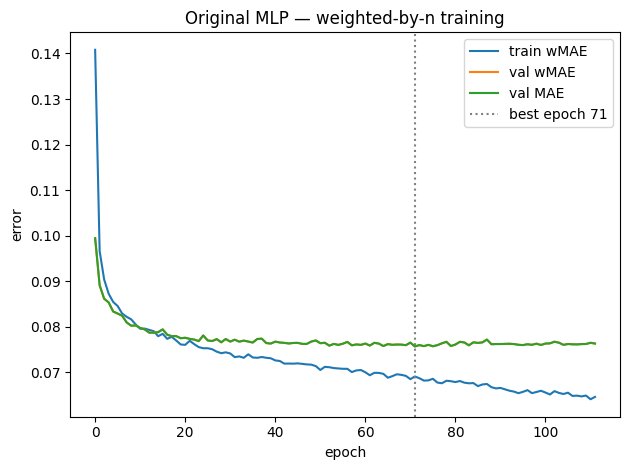

In [51]:
plt.figure()
plt.plot(history["train_wmae"], label="train wMAE", color="C0")
plt.plot(history["val_wmae"], label="val wMAE", color="C1")
plt.plot(history["val_mae"], label="val MAE", color="C2")
plt.axvline(best_epoch, linestyle=":", color="gray", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("error")
plt.legend()
plt.title("Original MLP — weighted-by-n training")
plt.tight_layout()
plt.show()


**Observations:**
- Fast initial convergence with stable, smooth training
- Train and validation wMAE track closely
- Validation wMAE and MAE are almost identical
- Validation plateaus around epoch 30-40 while training continues improving
- Early stopping at epoch 71, final val MAE ≈ 0.076

**Diagnosis:**
The plateau with continuing train improvement suggests the model's capacity is limited and it can't learn more complex patterns from the data.

**Next Steps:**
1. **Increase network capacity** - Try larger hidden layers (e.g., 256→128→64 or 512→256→128)
2. **Add normalization** - Helps deeper/wider networks train more effectively by:
   - Stabilizing gradients across layers (enables training larger networks)
   - Allowing higher learning rates (faster convergence)
   - Improving optimization landscape (better local minima)
3. **Make both tunable** - Add layer sizes and normalization as Optuna hyperparameters


### Configurable MLP with normalization

**MLP with normalization (Optuna).** Same architecture as `Choices13kNet` but with a normalization layer after each hidden activation, the norm type (`none`, `layer`, `batch`) is optimized by Optuna, and larger layers. Dropout remains a hyperparameter.

In [52]:
class Choices13kNetNorm(nn.Module):
    """MLP with configurable activation, normalization, and flexible depth."""
    def __init__(self, input_dim, hidden=(256, 128, 64), dropout=0.0, activation='relu', norm="none"):
        super().__init__()
        assert norm in ("none", "layer", "batch")

        # Map activation names to PyTorch modules
        activation_map = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'elu': nn.ELU,
            'gelu': nn.GELU,
            'selu': nn.SELU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid,
            'swish': nn.SiLU,
            'mish': nn.Mish,
        }

        if activation.lower() not in activation_map:
            raise ValueError(f"Activation '{activation}' not supported. Choose from: {list(activation_map.keys())}")

        act_fn = activation_map[activation.lower()]

        layers = []
        dims = [input_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if norm == "batch":
                layers.append(nn.BatchNorm1d(dims[i + 1]))
            elif norm == "layer":
                layers.append(nn.LayerNorm(dims[i + 1]))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [53]:
@torch.no_grad()
def eval_epoch_mlp_norm(model, X, y, w):
    model.eval()
    Xd, yd, wd = X.to(device), y.to(device), w.to(device)
    pred = model(Xd)
    val_wmae = mae_weighted(pred, yd, wd)
    val_mae = mae_unweighted(pred, yd)
    return val_wmae, val_mae

def train_nn_one_run_mlp_norm(
    model,
    train_loader,
    X_val, y_val, w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0
    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0
        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_mlp_norm(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric, best_epoch = val_wmae, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train wMAE={train_wmae:.5f} | val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")
        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_metric, best_epoch, history

In [54]:
def objective_mlp_norm(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    activation = trial.suggest_categorical("activation", ["relu", "leaky_relu", "gelu", "swish"])
    norm = trial.suggest_categorical("norm", ["none", "layer", "batch"])

    # Configurable number of layers
    n_layers = trial.suggest_int("n_layers", 2, 4)

    # Build hidden architecture based on n_layers
    hidden = []
    for i in range(n_layers):
        if i == 0:
            h = trial.suggest_categorical(f"h{i+1}", [128, 256, 512])
        elif i == 1:
            h = trial.suggest_categorical(f"h{i+1}", [64, 128, 256])
        elif i == 2:
            h = trial.suggest_categorical(f"h{i+1}", [32, 64, 128])
        else:
            h = trial.suggest_categorical(f"h{i+1}", [16, 32, 64])
        hidden.append(h)

    hidden = tuple(hidden)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []
    X_all, y_all, w_all = X_tr_torch, y_tr_torch, w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]
        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = Choices13kNetNorm(input_dim, hidden, dropout, activation, norm).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )
        val_wmae, _, _ = train_nn_one_run_mlp_norm(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )
        fold_scores.append(val_wmae)
    return float(np.mean(fold_scores))

In [55]:
study_norm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study_norm.optimize(objective_mlp_norm, n_trials=25, show_progress_bar=True)
print("Best params:", study_norm.best_params)
print("Best CV wMAE:", study_norm.best_value)

  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.09464 | val wMAE=0.08577 | val MAE=0.08577 | lr=5.61e-04 ★
[050] train wMAE=0.06060 | val wMAE=0.07930 | val MAE=0.07930 | lr=2.81e-04
Early stopping at epoch 74 (best=34)
[000] train wMAE=0.13962 | val wMAE=0.09597 | val MAE=0.09597 | lr=1.67e-03 ★
[050] train wMAE=0.07981 | val wMAE=0.07785 | val MAE=0.07785 | lr=1.67e-03
[100] train wMAE=0.07644 | val wMAE=0.07665 | val MAE=0.07665 | lr=8.37e-04
Early stopping at epoch 111 (best=71)
[000] train wMAE=0.11264 | val wMAE=0.08958 | val MAE=0.08958 | lr=4.20e-04 ★
[050] train wMAE=0.07319 | val wMAE=0.07715 | val MAE=0.07715 | lr=4.20e-04
[100] train wMAE=0.06764 | val wMAE=0.07663 | val MAE=0.07663 | lr=1.05e-04
Early stopping at epoch 118 (best=78)
[000] train wMAE=0.15037 | val wMAE=0.11331 | val MAE=0.11331 | lr=1.91e-04 ★
[050] train wMAE=0.07174 | val wMAE=0.07762 | val MAE=0.07762 | lr=1.91e-04
[100] train wMAE=0.06719 | val wMAE=0.07698 | val MAE=0.07698 | lr=9.57e-05
Early stopping at epoch 121 (best=81)
[000]

In [56]:
bp_norm = study_norm.best_params

# Build hidden tuple based on n_layers
n_layers = bp_norm["n_layers"]
hidden_norm = tuple(bp_norm[f"h{i+1}"] for i in range(n_layers))

model_norm = Choices13kNetNorm(
    input_dim, hidden_norm, bp_norm["dropout"], bp_norm["activation"], bp_norm["norm"]
).to(device)
optimizer_norm = optim.AdamW(model_norm.parameters(), lr=bp_norm["lr"], weight_decay=bp_norm["weight_decay"])
scheduler_norm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_norm, patience=15, factor=0.5)

train_loader_norm = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp_norm["batch_size"],
    shuffle=True,
)

best_val_wmae_norm, best_epoch_norm, history_norm = train_nn_one_run_mlp_norm(
    model=model_norm,
    train_loader=train_loader_norm,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_norm,
    scheduler=scheduler_norm,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

with torch.no_grad():
    pred_test_norm = model_norm(X_te_torch.to(device)).cpu()
test_mae_norm = torch.mean(torch.abs(pred_test_norm - y_te_torch)).item()
test_wmae_norm = mae_weighted(pred_test_norm, y_te_torch, w_te_torch)
print(f"Best epoch: {best_epoch_norm} | VAL wMAE: {best_val_wmae_norm:.6f}")
print(f"TEST MAE: {test_mae_norm:.6f} | TEST wMAE: {test_wmae_norm:.6f}")

[000] train wMAE=0.13619 | val wMAE=0.09411 | val MAE=0.09411 | lr=1.67e-03 ★
[025] train wMAE=0.08201 | val wMAE=0.07884 | val MAE=0.07884 | lr=1.67e-03
[050] train wMAE=0.07949 | val wMAE=0.07719 | val MAE=0.07719 | lr=1.67e-03
[075] train wMAE=0.07780 | val wMAE=0.07708 | val MAE=0.07708 | lr=1.67e-03
[100] train wMAE=0.07617 | val wMAE=0.07599 | val MAE=0.07599 | lr=1.67e-03 ★
[125] train wMAE=0.07441 | val wMAE=0.07640 | val MAE=0.07640 | lr=8.37e-04
[150] train wMAE=0.07335 | val wMAE=0.07566 | val MAE=0.07566 | lr=4.18e-04
Early stopping at epoch 162 (best=122)
Best epoch: 122 | VAL wMAE: 0.075508
TEST MAE: 0.074721 | TEST wMAE: 0.074721


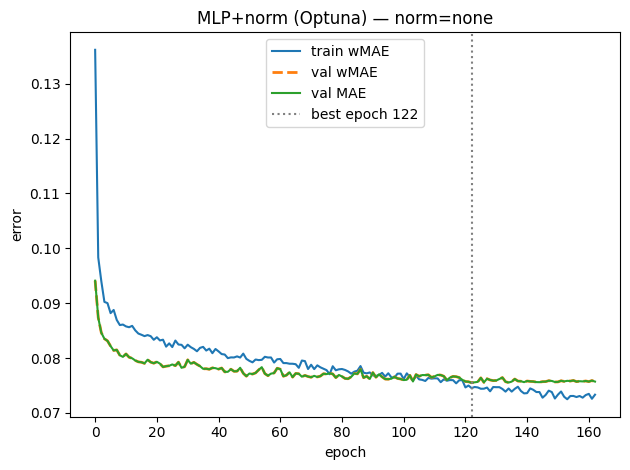

In [57]:
plt.figure()
plt.plot(history_norm["train_wmae"], label="train wMAE", color="C0")
plt.plot(history_norm["val_wmae"], label="val wMAE", color="C1", linestyle="--", linewidth=2)
plt.plot(history_norm["val_mae"], label="val MAE", color="C2")
plt.axvline(best_epoch_norm, linestyle=":", color="gray", label=f"best epoch {best_epoch_norm}")
plt.xlabel("epoch")
plt.ylabel("error")
plt.legend()
plt.title(f"MLP+norm (Optuna) — norm={bp_norm['norm']}")
plt.tight_layout()
plt.show()

**Observations:**
- Fast initial convergence in first 20 epochs
- Train and val wMAE track very closely (no overfitting)
- Validation plateaus around epoch 80-100
- Training continues improving past best epoch (122)
- Final val MAE ≈ 0.076

**Comparison to original MLP:**
- Similar convergence pattern and final performance
- Slightly later best epoch (122 vs 71)
- Nearly identical plateau behavior
- No significant improvement with norm=none (as expected)

### Residual MLP Architecture

**Motivation:**
Our standard MLP plateaus early (val wMAE ≈ 0.076) with validation stopping improvement while training continues. Residual connections enable deeper networks that can learn more complex patterns without gradient flow issues.

**Architecture:**
- Input projection: $h_0 = \text{Activation}(\text{Linear}(x))$
- Residual blocks: $h_{i+1} = h_i + f(h_i)$ where $f$ applies Norm → expand → activate → compress
- Output: $\hat{y} = \sigma(\text{Linear}(\text{Norm}(h_n)))$

**Residual block computation:**
$$h_{i+1} = h_i + \text{Dropout}(\text{Linear}(\text{Dropout}(\text{Activation}(\text{Linear}(\text{Norm}(h_i))))))$$

The key is the skip connection ($+ h_i$) which allows gradients to flow directly: $\frac{\partial L}{\partial h_i} = \frac{\partial L}{\partial h_{i+1}}(1 + \frac{\partial f}{\partial h_i})$

**Key advantages:**
- Train deeper networks (8-12+ blocks) without vanishing gradients
- Skip connections provide direct gradient pathways
- Fixed width $d$ enables stable training

**Tunable hyperparameters:** `d` (width), `n_blocks` (depth), `hidden_mult` (expansion ratio), `dropout`, `activation`, `norm` (layer/batch)

In [58]:
class ResidualBlock(nn.Module):
    def __init__(self, d: int, hidden_mult: float = 2.0, dropout: float = 0.1, activation: str = 'gelu', norm: str = 'layer'):
        super().__init__()
        assert norm in ('layer', 'batch'), "norm must be 'layer' or 'batch'"

        h = max(8, int(d * hidden_mult))

        # Configurable normalization
        self.norm = nn.LayerNorm(d) if norm == 'layer' else nn.BatchNorm1d(d)

        self.fc1 = nn.Linear(d, h)
        self.fc2 = nn.Linear(h, d)

        # Configurable activation
        activation_map = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'elu': nn.ELU,
            'gelu': nn.GELU,
            'selu': nn.SELU,
            'tanh': nn.Tanh,
            'swish': nn.SiLU,
            'mish': nn.Mish,
        }
        if activation.lower() not in activation_map:
            raise ValueError(f"Activation '{activation}' not supported. Choose from: {list(activation_map.keys())}")

        self.act = activation_map[activation.lower()]()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.norm(x)
        z = self.fc1(z)
        z = self.act(z)
        z = self.drop(z)
        z = self.fc2(z)
        z = self.drop(z)
        return x + z


class Choices13kResNet(nn.Module):
    """
    Residual MLP for brate prediction (output in [0,1]).
    """
    def __init__(
        self,
        input_dim: int,
        d: int = 128,
        n_blocks: int = 3,
        hidden_mult: float = 2.0,
        dropout: float = 0.1,
        activation: str = "gelu",
        norm: str = "layer",  # 'layer' or 'batch'
    ):
        super().__init__()
        assert norm in ('layer', 'batch'), "norm must be 'layer' or 'batch'"

        # Configurable activation for input projection
        activation_map = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'elu': nn.ELU,
            'gelu': nn.GELU,
            'selu': nn.SELU,
            'tanh': nn.Tanh,
            'swish': nn.SiLU,
            'mish': nn.Mish,
        }
        if activation.lower() not in activation_map:
            raise ValueError(f"Activation '{activation}' not supported.")

        act_fn = activation_map[activation.lower()]

        self.inp = nn.Sequential(
            nn.Linear(input_dim, d),
            act_fn(),
            nn.Dropout(dropout),
        )

        self.blocks = nn.Sequential(*[
            ResidualBlock(d, hidden_mult=hidden_mult, dropout=dropout, activation=activation, norm=norm)
            for _ in range(n_blocks)
        ])

        # Use same normalization type in head
        head_norm = nn.LayerNorm(d) if norm == 'layer' else nn.BatchNorm1d(d)

        self.head = nn.Sequential(
            head_norm,
            nn.Linear(d, 1),
            nn.Sigmoid()  # Always sigmoid for brate in [0,1]
        )

    def forward(self, x):
        x = self.inp(x)
        x = self.blocks(x)
        return self.head(x)

In [59]:
def _mae_torch(pred, y):
    return torch.mean(torch.abs(pred - y)).item()

@torch.no_grad()
def eval_epoch_resnet(model, X, y, w):
    model.eval()
    X, y, w = X.to(device), y.to(device), w.to(device)
    pred = model(X)
    val_wmae = mae_weighted(pred, y, w)
    val_mae = mae_unweighted(pred, y)
    return val_wmae, val_mae


In [60]:
def train_nn_one_run_resnet(
    model,
    train_loader,
    X_val,
    y_val,
    w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0
    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0

        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_resnet(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric, best_epoch = val_wmae, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train wMAE={train_wmae:.5f} | val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_metric, best_epoch, history


In [61]:
def objective_resnet(trial):
    # Optimizer / training
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

    # Architecture
    d = trial.suggest_categorical("d", [64, 128, 256, 512])
    n_blocks = trial.suggest_int("n_blocks", 2, 8)
    hidden_mult = trial.suggest_float("hidden_mult", 1.5, 3.5)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    activation = trial.suggest_categorical("activation", ["relu", "leaky_relu", "gelu", "swish"])
    norm = trial.suggest_categorical("norm", ["layer", "batch"])

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []

    X_all = X_tr_torch
    y_all = y_tr_torch
    w_all = w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]

        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = Choices13kResNet(
            input_dim=input_dim,
            d=d,
            n_blocks=n_blocks,
            hidden_mult=hidden_mult,
            dropout=dropout,
            activation=activation,
            norm=norm,
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_wmae, _, _ = train_nn_one_run_resnet(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )

        fold_scores.append(val_wmae)

    return float(np.mean(fold_scores))


In [62]:

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective_resnet, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV MAE:", study.best_value)



  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.12358 | val wMAE=0.08842 | val MAE=0.08842 | lr=5.61e-04 ★
[050] train wMAE=0.07679 | val wMAE=0.07709 | val MAE=0.07709 | lr=2.81e-04 ★
Early stopping at epoch 99 (best=59)
[000] train wMAE=0.10436 | val wMAE=0.09079 | val MAE=0.09079 | lr=7.31e-04 ★
[050] train wMAE=0.05411 | val wMAE=0.08109 | val MAE=0.08109 | lr=3.65e-04
Early stopping at epoch 66 (best=26)
[000] train wMAE=0.10764 | val wMAE=0.08859 | val MAE=0.08859 | lr=4.07e-04 ★
[050] train wMAE=0.06703 | val wMAE=0.07899 | val MAE=0.07899 | lr=2.03e-04
Early stopping at epoch 76 (best=36)
[000] train wMAE=0.13478 | val wMAE=0.09194 | val MAE=0.09194 | lr=1.57e-03 ★
[050] train wMAE=0.06399 | val wMAE=0.08088 | val MAE=0.08088 | lr=7.85e-04
Early stopping at epoch 70 (best=30)
[000] train wMAE=0.11433 | val wMAE=0.08676 | val MAE=0.08676 | lr=1.03e-04 ★
Early stopping at epoch 49 (best=9)
[000] train wMAE=0.14912 | val wMAE=0.10750 | val MAE=0.10750 | lr=1.73e-04 ★
[000] train wMAE=0.12059 | val wMAE=0.0887

In [63]:
bp = study.best_params

# Internal train/val split from TRAIN (for early stopping)
n_train = len(X_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_tr_torch[tr_idx]
y_tr = y_tr_torch[tr_idx]
w_tr = w_tr_torch[tr_idx]

X_val = X_tr_torch[val_idx]
y_val = y_tr_torch[val_idx]
w_val = w_tr_torch[val_idx]

# Build residual model with best params
model_resnet = Choices13kResNet(
    input_dim=input_dim,
    d=bp["d"],
    n_blocks=bp["n_blocks"],
    hidden_mult=bp["hidden_mult"],
    dropout=bp["dropout"],
    activation=bp["activation"],
    norm=bp["norm"],
).to(device)

optimizer_resnet = optim.AdamW(
    model_resnet.parameters(),
    lr=bp["lr"],
    weight_decay=bp["weight_decay"],
)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, patience=15, factor=0.5)

train_loader_resnet = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_wmae_resnet, best_epoch_resnet, history_resnet = train_nn_one_run_resnet(
    model=model_resnet,
    train_loader=train_loader_resnet,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_resnet,
    scheduler=scheduler_resnet,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

# Evaluate on TEST
with torch.no_grad():
    pred_test_resnet = model_resnet(X_te_torch.to(device)).cpu()

test_mae_resnet = torch.mean(torch.abs(pred_test_resnet - y_te_torch)).item()
test_wmae_resnet = mae_weighted(pred_test_resnet, y_te_torch, w_te_torch)

print(f"Best epoch: {best_epoch_resnet} | VAL wMAE: {best_val_wmae_resnet:.6f}")
print(f"TEST MAE: {test_mae_resnet:.6f} | TEST wMAE: {test_wmae_resnet:.6f}")


[000] train wMAE=0.12169 | val wMAE=0.08935 | val MAE=0.08935 | lr=5.61e-04 ★
[025] train wMAE=0.08130 | val wMAE=0.07776 | val MAE=0.07776 | lr=5.61e-04 ★
[050] train wMAE=0.07823 | val wMAE=0.07591 | val MAE=0.07591 | lr=5.61e-04 ★
[075] train wMAE=0.07555 | val wMAE=0.07585 | val MAE=0.07585 | lr=5.61e-04
[100] train wMAE=0.07216 | val wMAE=0.07648 | val MAE=0.07648 | lr=2.81e-04
[125] train wMAE=0.07051 | val wMAE=0.07702 | val MAE=0.07702 | lr=1.40e-04
Early stopping at epoch 144 (best=104)
Best epoch: 104 | VAL wMAE: 0.075482
TEST MAE: 0.075004 | TEST wMAE: 0.075004


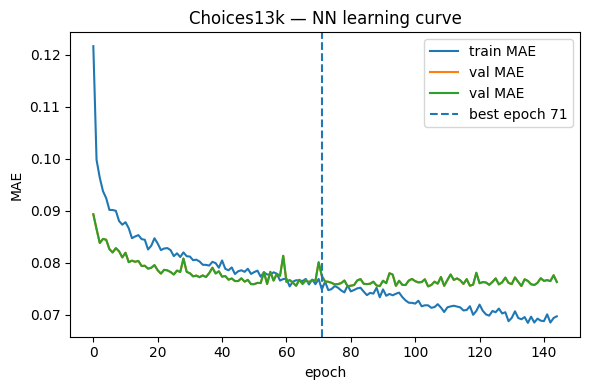

In [67]:
plt.figure(figsize=(6, 4))
plt.plot(history_resnet["train_wmae"], label="train MAE")
plt.plot(history_resnet["val_wmae"], label="val MAE")
plt.plot(history_resnet["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — NN learning curve")
plt.tight_layout()
plt.show()


**Observations:**
- Fast initial convergence in first 20 epochs
- Train and validation MAE diverge after epoch 30-40 (showing some overfitting)
- Validation plateaus around 0.075-0.076, similar to standard MLP
- Training continues improving to ~0.069, creating a larger train-val gap than standard MLP
- Best epoch at 71

**Comparison to standard MLP:**
- Similar final validation performance (~0.076)
- More overfitting (larger train-val gap)
- Same plateau behavior - validation stops improving while training continues

**Diagnosis:**
The ResNet architecture isn't breaking through the performance ceiling. The residual connections allow the model to overfit more (lower training error) but don't improve generalization. This suggests:
- The bottleneck may not be network depth/architecture
- Could be data quality, feature engineering, or inherent task difficulty
- May need different approach (ensemble, better features)

### Deep & Cross Network (DCNv2)

**Motivation:**
Standard MLPs and ResNets plateau at val MAE ≈ 0.076. DCNv2 explicitly models feature interactions through cross layers, which may capture patterns that deep networks miss.

**Architecture:**

**Cross Network:** Learns explicit feature crosses at layer $l$:
$$x_{l+1} = x_l + x_0 \odot (W_l \cdot x_l + b_l)$$
where $x_0$ is the input, $\odot$ is element-wise product, capturing bounded-degree polynomial feature interactions.

**Deep Network:** Standard feedforward transformation:
$$h_l = \text{Dropout}(\text{Activation}(\text{Norm}(\text{Linear}(h_{l-1}))))$$

**Fusion:** Concatenate and predict:
$$\hat{y} = \sigma(\text{Linear}([x_{\text{cross}}, h_{\text{deep}}]))$$

**Key advantages:**
- Explicit feature interactions (good for tabular data with meaningful crosses)
- Cross network learns interactions up to degree $n_{\text{cross}} + 1$
- Combines memorization (cross) with generalization (deep)
- More parameter-efficient than pure deep networks for interaction learning

**Tunable hyperparameters:** `n_cross` (cross depth), `deep_dims` (deep architecture), `dropout`, `activation`, `norm`

In [68]:
class CrossLayer(nn.Module):
    """
    Deep & Cross Network layer: x_{l+1} = x_l + x0 * (W x_l) + b
    Shapes: x0, x_l: (B, d); W: (d, d); b: (d,)
    """
    def __init__(self, d: int, dropout: float = 0.0):
        super().__init__()
        self.W = nn.Linear(d, d, bias=True)
        self.drop = nn.Dropout(dropout)

    def forward(self, x0, x):
        xw = self.W(x)
        out = x + x0 * xw  # Explicit feature crosses
        return self.drop(out)


class DCNv2(nn.Module):
    """
    Deep & Cross Network v2 for brate prediction (output in [0,1]).
    Combines explicit feature crosses (CrossNet) with deep learning (DeepNet).
    """
    def __init__(
        self,
        input_dim: int,
        n_cross: int = 3,
        deep_dims=(256, 128),
        dropout: float = 0.1,
        activation: str = "relu",
        norm: str = "none",  # "none", "layer", "batch"
    ):
        super().__init__()
        assert norm in ("none", "layer", "batch")

        self.input_dim = input_dim

        # Cross network (explicit feature interactions)
        self.cross_layers = nn.ModuleList([
            CrossLayer(input_dim, dropout=dropout)
            for _ in range(n_cross)
        ])

        # Configurable activation
        activation_map = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'elu': nn.ELU,
            'gelu': nn.GELU,
            'selu': nn.SELU,
            'tanh': nn.Tanh,
            'swish': nn.SiLU,
            'mish': nn.Mish,
        }
        if activation.lower() not in activation_map:
            raise ValueError(f"Activation '{activation}' not supported. Choose from: {list(activation_map.keys())}")

        act_fn = activation_map[activation.lower()]

        # Deep network (non-linear transformations)
        deep = []
        prev = input_dim
        for h in deep_dims:
            deep.append(nn.Linear(prev, h))
            if norm == "batch":
                deep.append(nn.BatchNorm1d(h))
            elif norm == "layer":
                deep.append(nn.LayerNorm(h))
            deep.append(act_fn())
            deep.append(nn.Dropout(dropout))
            prev = h

        self.deep = nn.Sequential(*deep) if len(deep) else nn.Identity()
        deep_out_dim = prev if len(deep) else input_dim

        # Head over concat([cross_out, deep_out])
        self.head = nn.Sequential(
            nn.Linear(input_dim + deep_out_dim, 1),
            nn.Sigmoid()  # Always sigmoid for brate in [0,1]
        )

    def forward(self, x):
        # Cross network
        x0 = x
        xc = x
        for layer in self.cross_layers:
            xc = layer(x0, xc)

        # Deep network
        xd = self.deep(x)

        # Concatenate and predict
        z = torch.cat([xc, xd], dim=1)
        return self.head(z)


In [69]:
@torch.no_grad()
def eval_epoch_dcn(model, X, y, w):
    model.eval()
    X, y, w = X.to(device), y.to(device), w.to(device)
    pred = model(X)
    val_wmae = mae_weighted(pred, y, w)
    val_mae = mae_unweighted(pred, y)
    return val_wmae, val_mae

def train_nn_one_run_dcn(
    model,
    train_loader,
    X_val,
    y_val,
    w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose: bool = False,
    log_every: int = 50,
    trial=None,
):
    best_metric = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0
    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0

        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_dcn(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric = val_wmae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train wMAE={train_wmae:.5f} | val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_metric, best_epoch, history


In [70]:
def objective_dcn(trial):
    # Training hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    activation = trial.suggest_categorical("activation", ["relu", "leaky_relu", "gelu", "swish"])
    norm = trial.suggest_categorical("norm", ["none", "layer", "batch"])

    # DCN structure
    n_cross = trial.suggest_int("n_cross", 1, 6)
    d1 = trial.suggest_categorical("d1", [64, 128, 256, 512])
    d2 = trial.suggest_categorical("d2", [0, 64, 128, 256])  # 0 => no 2nd layer
    deep_dims = (d1,) if d2 == 0 else (d1, d2)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []

    X_all = X_tr_torch
    y_all = y_tr_torch
    w_all = w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]

        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = DCNv2(
            input_dim=input_dim,
            n_cross=n_cross,
            deep_dims=deep_dims,
            dropout=dropout,
            activation=activation,
            norm=norm,
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_wmae, _, _ = train_nn_one_run_dcn(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )

        fold_scores.append(val_wmae)

    return float(np.mean(fold_scores))


In [71]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective_dcn, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV MAE:", study.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.09903 | val wMAE=0.08540 | val MAE=0.08540 | lr=5.61e-04 ★
[050] train wMAE=0.05672 | val wMAE=0.08070 | val MAE=0.08070 | lr=2.81e-04
Early stopping at epoch 59 (best=19)
[000] train wMAE=0.14320 | val wMAE=0.09209 | val MAE=0.09209 | lr=3.84e-04 ★
[050] train wMAE=0.07495 | val wMAE=0.07770 | val MAE=0.07770 | lr=3.84e-04
[100] train wMAE=0.06981 | val wMAE=0.07731 | val MAE=0.07731 | lr=9.60e-05
Early stopping at epoch 109 (best=69)
[000] train wMAE=0.15573 | val wMAE=0.11766 | val MAE=0.11766 | lr=3.29e-04 ★
[050] train wMAE=0.07488 | val wMAE=0.07896 | val MAE=0.07896 | lr=3.29e-04
[100] train wMAE=0.07065 | val wMAE=0.07814 | val MAE=0.07814 | lr=3.29e-04
[150] train wMAE=0.06917 | val wMAE=0.07776 | val MAE=0.07776 | lr=8.23e-05
Early stopping at epoch 193 (best=153)
[000] train wMAE=0.16641 | val wMAE=0.14601 | val MAE=0.14601 | lr=1.91e-04 ★
[050] train wMAE=0.07656 | val wMAE=0.07876 | val MAE=0.07876 | lr=1.91e-04
[100] train wMAE=0.07251 | val wMAE=0.0769

In [72]:
bp = study.best_params

# Internal train/val split from TRAIN (for early stopping)
n_train = len(X_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_tr_torch[tr_idx]
y_tr = y_tr_torch[tr_idx]
w_tr = w_tr_torch[tr_idx]

X_val = X_tr_torch[val_idx]
y_val = y_tr_torch[val_idx]
w_val = w_tr_torch[val_idx]

# Build DCN model with best params
deep_dims = (bp["d1"],) if bp["d2"] == 0 else (bp["d1"], bp["d2"])

model_dcn = DCNv2(
    input_dim=input_dim,
    n_cross=bp["n_cross"],
    deep_dims=deep_dims,
    dropout=bp["dropout"],
    activation=bp["activation"],
    norm=bp["norm"],
).to(device)

optimizer_dcn = optim.AdamW(
    model_dcn.parameters(),
    lr=bp["lr"],
    weight_decay=bp["weight_decay"],
)
scheduler_dcn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_dcn, patience=15, factor=0.5)

train_loader_dcn = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_wmae_dcn, best_epoch_dcn, history_dcn = train_nn_one_run_dcn(
    model=model_dcn,
    train_loader=train_loader_dcn,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_dcn,
    scheduler=scheduler_dcn,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

# Evaluate on TEST
with torch.no_grad():
    pred_test_dcn = model_dcn(X_te_torch.to(device)).cpu()

test_mae_dcn = torch.mean(torch.abs(pred_test_dcn - y_te_torch)).item()
test_wmae_dcn = mae_weighted(pred_test_dcn, y_te_torch, w_te_torch)

print(f"Best epoch: {best_epoch_dcn} | VAL wMAE: {best_val_wmae_dcn:.6f}")
print(f"TEST MAE: {test_mae_dcn:.6f} | TEST wMAE: {test_wmae_dcn:.6f}")


[000] train wMAE=0.12672 | val wMAE=0.08853 | val MAE=0.08853 | lr=7.73e-04 ★
[025] train wMAE=0.07269 | val wMAE=0.07639 | val MAE=0.07639 | lr=7.73e-04
[050] train wMAE=0.06660 | val wMAE=0.07584 | val MAE=0.07584 | lr=3.87e-04
[075] train wMAE=0.06328 | val wMAE=0.07515 | val MAE=0.07515 | lr=1.93e-04
[100] train wMAE=0.06186 | val wMAE=0.07534 | val MAE=0.07534 | lr=4.83e-05
Early stopping at epoch 105 (best=65)
Best epoch: 65 | VAL wMAE: 0.074903
TEST MAE: 0.075096 | TEST wMAE: 0.075096


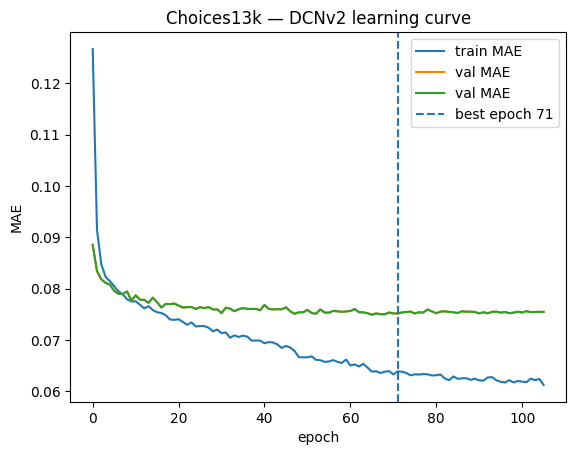

In [74]:
plt.figure()
plt.plot(history_dcn["train_wmae"], label="train MAE")
plt.plot(history_dcn["val_wmae"], label="val MAE")
plt.plot(history_dcn["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — DCNv2 learning curve")
plt.show()


**Observations:**
- Fast initial convergence in first 20 epochs
- Validation plateaus around epoch 20 at MAE ≈ 0.075-0.076
- Training continues improving to ~0.062, showing significant overfitting
- Larger train-val gap than MLP or ResNet
- Best epoch at 71

**Comparison to other models:**
- Similar validation plateau (~0.075) as MLP and ResNet
- More overfitting than standard MLP (larger train-val gap)
- Cross network doesn't improve generalization despite explicitly modeling feature interactions

**Diagnosis:**
DCNv2's explicit feature crosses help the model fit training data better (lower train MAE) but don't translate to better validation performance. This suggests:
- The explicit polynomial interactions aren't the missing piece
- The validation plateau appears to be a fundamental limit with current features
- Model is learning training-specific patterns rather than generalizable interactions

**Conclusion:**
DCNv2 shows no improvement over simpler architectures. We will retrain the model but force normalization.

In [75]:
def objective_dcn_v2(trial):
    # Training hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.3, 0.5)  # Higher dropout
    activation = trial.suggest_categorical("activation", ["relu", "leaky_relu", "gelu", "swish"])
    norm = trial.suggest_categorical("norm", ["layer", "batch"])  # Force normalization

    # DCN structure - reduced capacity
    n_cross = trial.suggest_int("n_cross", 1, 3)  # Max 3 cross layers
    d1 = trial.suggest_categorical("d1", [128, 256])  # Remove 512
    d2 = trial.suggest_categorical("d2", [0, 64, 128])  # Smaller options
    deep_dims = (d1,) if d2 == 0 else (d1, d2)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []

    X_all = X_tr_torch
    y_all = y_tr_torch
    w_all = w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]

        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = DCNv2(
            input_dim=input_dim,
            n_cross=n_cross,
            deep_dims=deep_dims,
            dropout=dropout,
            activation=activation,
            norm=norm,
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_wmae, _, _ = train_nn_one_run_dcn(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=30,  # More aggressive early stopping
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )

        fold_scores.append(val_wmae)

    return float(np.mean(fold_scores))

# Run study
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_dcn_v2 = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=10),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study_dcn_v2.optimize(objective_dcn_v2, n_trials=25, show_progress_bar=True)

print("Best params:", study_dcn_v2.best_params)
print("Best CV wMAE:", study_dcn_v2.best_value)

  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.13768 | val wMAE=0.09178 | val MAE=0.09178 | lr=5.61e-04 ★
[050] train wMAE=0.08000 | val wMAE=0.07745 | val MAE=0.07745 | lr=5.61e-04
[100] train wMAE=0.07752 | val wMAE=0.07698 | val MAE=0.07698 | lr=2.81e-04
[150] train wMAE=0.07469 | val wMAE=0.07648 | val MAE=0.07648 | lr=1.40e-04
Early stopping at epoch 168 (best=138)
[000] train wMAE=0.13958 | val wMAE=0.09091 | val MAE=0.09091 | lr=7.31e-04 ★
[050] train wMAE=0.07628 | val wMAE=0.07818 | val MAE=0.07818 | lr=7.31e-04
[100] train wMAE=0.07394 | val wMAE=0.07681 | val MAE=0.07681 | lr=3.65e-04
[150] train wMAE=0.07204 | val wMAE=0.07646 | val MAE=0.07646 | lr=4.57e-05
Early stopping at epoch 157 (best=127)
[000] train wMAE=0.15918 | val wMAE=0.09517 | val MAE=0.09517 | lr=4.07e-04 ★
[050] train wMAE=0.08178 | val wMAE=0.07837 | val MAE=0.07837 | lr=4.07e-04
[100] train wMAE=0.07823 | val wMAE=0.07728 | val MAE=0.07728 | lr=4.07e-04
Early stopping at epoch 136 (best=106)
[000] train wMAE=0.12180 | val wMAE=0.089

In [76]:
bp = study.best_params

# Internal train/val split from TRAIN (for early stopping)
n_train = len(X_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_tr_torch[tr_idx]
y_tr = y_tr_torch[tr_idx]
w_tr = w_tr_torch[tr_idx]

X_val = X_tr_torch[val_idx]
y_val = y_tr_torch[val_idx]
w_val = w_tr_torch[val_idx]

# Build DCN model with best params
deep_dims = (bp["d1"],) if bp["d2"] == 0 else (bp["d1"], bp["d2"])

model_dcn = DCNv2(
    input_dim=input_dim,
    n_cross=bp["n_cross"],
    deep_dims=deep_dims,
    dropout=bp["dropout"],
    activation=bp["activation"],
    norm=bp["norm"],
).to(device)

optimizer_dcn = optim.AdamW(
    model_dcn.parameters(),
    lr=bp["lr"],
    weight_decay=bp["weight_decay"],
)
scheduler_dcn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_dcn, patience=15, factor=0.5)

train_loader_dcn = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_wmae_dcn, best_epoch_dcn, history_dcn = train_nn_one_run_dcn(
    model=model_dcn,
    train_loader=train_loader_dcn,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_dcn,
    scheduler=scheduler_dcn,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

# Evaluate on TEST
with torch.no_grad():
    pred_test_dcn = model_dcn(X_te_torch.to(device)).cpu()

test_mae_dcn = torch.mean(torch.abs(pred_test_dcn - y_te_torch)).item()
test_wmae_dcn = mae_weighted(pred_test_dcn, y_te_torch, w_te_torch)

print(f"Best epoch: {best_epoch_dcn} | VAL wMAE: {best_val_wmae_dcn:.6f}")
print(f"TEST MAE: {test_mae_dcn:.6f} | TEST wMAE: {test_wmae_dcn:.6f}")

[000] train wMAE=0.13021 | val wMAE=0.08826 | val MAE=0.08826 | lr=7.73e-04 ★
[025] train wMAE=0.07264 | val wMAE=0.07675 | val MAE=0.07675 | lr=7.73e-04
[050] train wMAE=0.06675 | val wMAE=0.07587 | val MAE=0.07587 | lr=3.87e-04
[075] train wMAE=0.06331 | val wMAE=0.07639 | val MAE=0.07639 | lr=1.93e-04
[100] train wMAE=0.06220 | val wMAE=0.07644 | val MAE=0.07644 | lr=4.83e-05
Early stopping at epoch 106 (best=66)
Best epoch: 66 | VAL wMAE: 0.075626
TEST MAE: 0.074779 | TEST wMAE: 0.074779


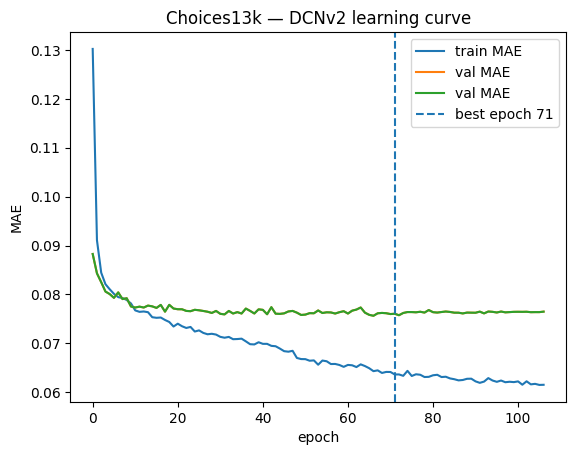

In [77]:
plt.figure()
plt.plot(history_dcn["train_wmae"], label="train MAE")
plt.plot(history_dcn["val_wmae"], label="val MAE")
plt.plot(history_dcn["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — DCNv2 learning curve")
plt.show()


**Observations:**
- Fast initial convergence in first 20 epochs
- Validation plateaus at epoch 15-20 at MAE ≈ 0.076
- Training continues improving to ~0.062
- Still shows overfitting with large train-val gap
- Best epoch at 71 (same as before)

**Comparison to original DCN:**
- Slightly better validation performance(0.075 for 0.076)
- Similar overfitting pattern (train reaches ~0.062)
- Forced normalization didn't reduce overfitting or improve generalization
- Same plateau behavior

### MLP with Normalization on Engineered Features

**Goal:**
Test if engineered features (interaction terms, aggregations, domain-specific transformations) can break through the ~0.076 MAE plateau observed with base features across all architectures (MLP, ResNet, DCN).

**Approach:**
- Use the same MLP+Norm architecture that worked well on base features
- Train on `x_eng` (engineered feature set) instead of original features
- Same hyperparameter search space and training procedure
- Compare validation performance to baseline ~0.076 MAE

**Hypothesis:**
If the plateau is due to feature limitations rather than architecture, engineered features should improve performance. If we still plateau at ~0.076, the bottleneck is likely data quality or task difficulty.

In [82]:
# Prepare engineered features for neural network, using the same train test split
X_train_df_eng, X_test_df_eng, y_train_eng, y_test_eng, w_train_eng, w_test_eng = train_test_split(
    X_eng, y, X['n'], test_size=0.2, random_state=SEED
)

# Scale features
scaler_eng = StandardScaler()
X_eng_train_scaled = scaler_eng.fit_transform(X_train_df_eng)
X_eng_test_scaled = scaler_eng.transform(X_test_df_eng)

# Convert to tensors
X_eng_tr_torch = torch.tensor(X_eng_train_scaled, dtype=torch.float32)
y_eng_tr_torch = torch.tensor(y_train_eng.reshape(-1, 1), dtype=torch.float32)
w_eng_tr_torch = torch.tensor(w_train_eng.values.reshape(-1, 1), dtype=torch.float32)

X_eng_te_torch = torch.tensor(X_eng_test_scaled, dtype=torch.float32)
y_eng_te_torch = torch.tensor(y_test_eng.reshape(-1, 1), dtype=torch.float32)
w_eng_te_torch = torch.tensor(w_test_eng.values.reshape(-1, 1), dtype=torch.float32)

input_dim_eng = X_eng_train_scaled.shape[1]

# Update objective function to use engineered features
def objective_mlp_norm_eng(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    activation = trial.suggest_categorical("activation", ["relu", "leaky_relu", "gelu", "swish"])
    norm = trial.suggest_categorical("norm", ["none", "layer", "batch"])

    # Configurable number of layers
    n_layers = trial.suggest_int("n_layers", 2, 4)

    # Build hidden architecture based on n_layers
    hidden = []
    for i in range(n_layers):
        if i == 0:
            h = trial.suggest_categorical(f"h{i+1}", [128, 256, 512])
        elif i == 1:
            h = trial.suggest_categorical(f"h{i+1}", [64, 128, 256])
        elif i == 2:
            h = trial.suggest_categorical(f"h{i+1}", [32, 64, 128])
        else:
            h = trial.suggest_categorical(f"h{i+1}", [16, 32, 64])
        hidden.append(h)

    hidden = tuple(hidden)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []
    X_all, y_all, w_all = X_eng_tr_torch, y_eng_tr_torch, w_eng_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]
        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = Choices13kNetNorm(input_dim_eng, hidden, dropout, activation, norm).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )
        val_wmae, _, _ = train_nn_one_run_mlp_norm(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )
        fold_scores.append(val_wmae)
    return float(np.mean(fold_scores))

# Run Optuna study
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_mlp_eng = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=10),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study_mlp_eng.optimize(objective_mlp_norm_eng, n_trials=25, show_progress_bar=True)

print("Best params:", study_mlp_eng.best_params)
print("Best CV wMAE:", study_mlp_eng.best_value)

  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.09584 | val wMAE=0.08799 | val MAE=0.08836 | lr=5.61e-04 ★
[050] train wMAE=0.07277 | val wMAE=0.08032 | val MAE=0.08066 | lr=2.81e-04
Early stopping at epoch 89 (best=49)
[000] train wMAE=0.13577 | val wMAE=0.09962 | val MAE=0.10033 | lr=1.67e-03 ★
[050] train wMAE=0.08630 | val wMAE=0.08132 | val MAE=0.08185 | lr=1.67e-03
[100] train wMAE=0.08307 | val wMAE=0.08024 | val MAE=0.08067 | lr=8.37e-04 ★
[150] train wMAE=0.08154 | val wMAE=0.08007 | val MAE=0.08049 | lr=4.18e-04
[200] train wMAE=0.08137 | val wMAE=0.07985 | val MAE=0.08025 | lr=5.23e-05
Early stopping at epoch 236 (best=196)
[000] train wMAE=0.11212 | val wMAE=0.09186 | val MAE=0.09185 | lr=4.20e-04 ★
[050] train wMAE=0.07962 | val wMAE=0.08116 | val MAE=0.08160 | lr=4.20e-04
[100] train wMAE=0.07636 | val wMAE=0.08023 | val MAE=0.08065 | lr=1.05e-04
[150] train wMAE=0.07582 | val wMAE=0.08014 | val MAE=0.08055 | lr=2.63e-05
Early stopping at epoch 160 (best=120)
[000] train wMAE=0.13542 | val wMAE=0.101

In [83]:
bp_norm_eng = study_mlp_eng.best_params

# Internal train/val split from TRAIN (for early stopping)
n_train = len(X_eng_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_eng_tr_torch[tr_idx]
y_tr = y_eng_tr_torch[tr_idx]
w_tr = w_eng_tr_torch[tr_idx]

X_val = X_eng_tr_torch[val_idx]
y_val = y_eng_tr_torch[val_idx]
w_val = w_eng_tr_torch[val_idx]

# Build hidden tuple based on n_layers
n_layers = bp_norm_eng["n_layers"]
hidden_norm_eng = tuple(bp_norm_eng[f"h{i+1}"] for i in range(n_layers))

model_norm_eng = Choices13kNetNorm(
    input_dim_eng, hidden_norm_eng, bp_norm_eng["dropout"], bp_norm_eng["activation"], bp_norm_eng["norm"]
).to(device)

optimizer_norm_eng = optim.AdamW(model_norm_eng.parameters(), lr=bp_norm_eng["lr"], weight_decay=bp_norm_eng["weight_decay"])
scheduler_norm_eng = optim.lr_scheduler.ReduceLROnPlateau(optimizer_norm_eng, patience=15, factor=0.5)

train_loader_norm_eng = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp_norm_eng["batch_size"],
    shuffle=True,
)

best_val_wmae_norm_eng, best_epoch_norm_eng, history_norm_eng = train_nn_one_run_mlp_norm(
    model=model_norm_eng,
    train_loader=train_loader_norm_eng,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_norm_eng,
    scheduler=scheduler_norm_eng,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

# Evaluate on TEST
with torch.no_grad():
    pred_test_norm_eng = model_norm_eng(X_eng_te_torch.to(device)).cpu()

test_mae_norm_eng = torch.mean(torch.abs(pred_test_norm_eng - y_eng_te_torch)).item()
test_wmae_norm_eng = mae_weighted(pred_test_norm_eng, y_eng_te_torch, w_eng_te_torch)

print(f"Best epoch: {best_epoch_norm_eng} | VAL wMAE: {best_val_wmae_norm_eng:.6f}")
print(f"TEST MAE: {test_mae_norm_eng:.6f} | TEST wMAE: {test_wmae_norm_eng:.6f}")

[000] train wMAE=0.10006 | val wMAE=0.08862 | val MAE=0.08929 | lr=7.18e-04 ★
[025] train wMAE=0.07979 | val wMAE=0.08086 | val MAE=0.08162 | lr=7.18e-04
[050] train wMAE=0.07758 | val wMAE=0.07967 | val MAE=0.08044 | lr=7.18e-04
[075] train wMAE=0.07579 | val wMAE=0.08031 | val MAE=0.08099 | lr=7.18e-04
[100] train wMAE=0.07447 | val wMAE=0.07985 | val MAE=0.08050 | lr=7.18e-04
[125] train wMAE=0.07320 | val wMAE=0.07881 | val MAE=0.07951 | lr=3.59e-04
[150] train wMAE=0.07240 | val wMAE=0.07898 | val MAE=0.07966 | lr=8.98e-05
Early stopping at epoch 162 (best=122)
Best epoch: 122 | VAL wMAE: 0.078654
TEST MAE: 0.077391 | TEST wMAE: 0.076749


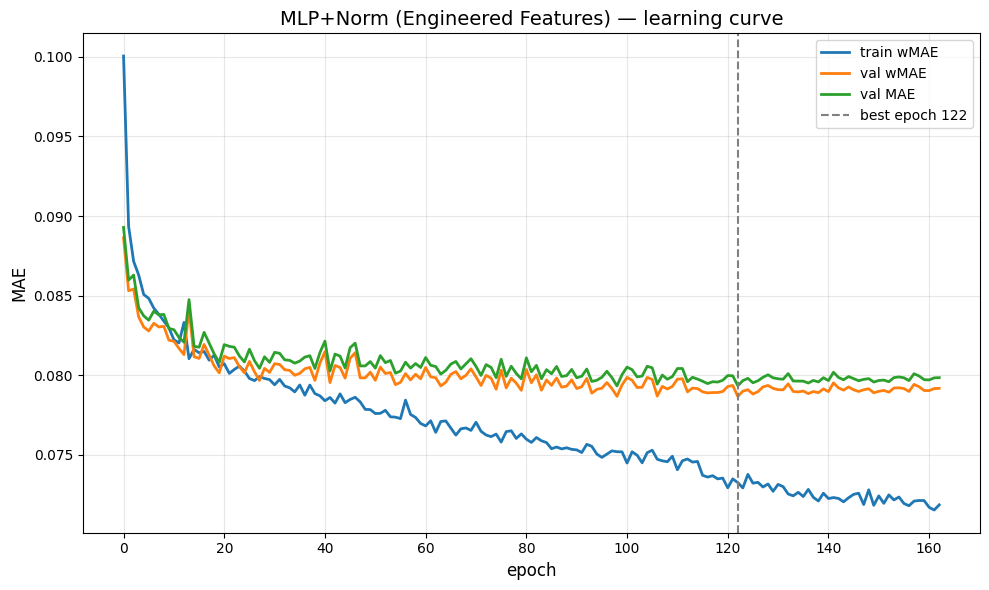

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))

epochs = range(len(history_norm_eng["train_wmae"]))

ax.plot(epochs, history_norm_eng["train_wmae"], label="train wMAE", linewidth=2)
ax.plot(epochs, history_norm_eng["val_wmae"], label="val wMAE", linewidth=2)
ax.plot(epochs, history_norm_eng["val_mae"], label="val MAE", linewidth=2)
ax.axvline(best_epoch_norm_eng, color="gray", linestyle="--", label=f"best epoch {best_epoch_norm_eng}")

ax.set_xlabel("epoch", fontsize=12)
ax.set_ylabel("MAE", fontsize=12)
ax.set_title("MLP+Norm (Engineered Features) — learning curve", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
- Fast initial convergence in first 30 epochs
- Validation plateaus at epoch 30-40 at MAE ≈ 0.079-0.080
- Training continues improving to ~0.072
- Moderate train-val gap (less than DCN, more than base MLP)
- Best epoch at 122

**Comparison to all features (MAE ~0.076):**
- **WORSE performance** - Validation MAE increased to ~0.078 (vs 0.076 with base features)
- Only keeping "important features" hurts performance
- More unstable training (noisy curves, especially val MAE)
- Similar overfitting pattern but higher baseline error

### Feature Tokenizer Transformer (FT-Transformer)

**Motivation:**
MLPs, ResNets, and DCN all plateau at val MAE ≈ 0.076. FT-Transformer uses attention mechanisms to learn dynamic feature interactions, potentially capturing patterns that fixed architectures miss.

**Architecture:**

**Feature Tokenization:** Each feature $x_i$ gets its own embedding:
$$t_i = \text{Linear}_i(x_i) + e_i$$
where $e_i$ is a learnable column embedding, creating $n$ tokens of dimension $d_{\text{model}}$.

**Transformer Encoder:** Self-attention across feature tokens:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
$$\text{Token}_i^{(l+1)} = \text{LayerNorm}(\text{Token}_i^{(l)} + \text{FFN}(\text{SelfAttention}(\text{Token}_i^{(l)})))$$

**Prediction:** Mean pool across tokens, then predict:
$$\hat{y} = \sigma(\text{Linear}(\text{mean}([\text{Token}_1, ..., \text{Token}_n])))$$

**Key advantages:**
- Attention learns which feature interactions matter (data-dependent)
- Each feature gets dedicated embedding (captures per-column semantics)
- Global context via self-attention (versus local in MLPs)

**Tunable hyperparameters:** `d_model` (token dimension), `n_heads` (attention heads), `n_layers` (transformer depth), `d_ff_mult` (feedforward expansion), `dropout`, `activation` (relu/gelu only)

In [85]:
class FTTransformer(nn.Module):
    """
    Feature Tokenizer + Transformer for tabular brate prediction (output in [0,1]).
    Each column is embedded to d_model; tokens go through Transformer; mean pool -> head -> sigmoid.
    """
    def __init__(
        self,
        n_features: int,
        d_model: int = 64,
        n_heads: int = 4,
        n_layers: int = 2,
        d_ff_mult: float = 4.0,
        dropout: float = 0.1,
        activation: str = "gelu",
    ):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model

        # Configurable activation
        activation_map = {
            'relu': 'relu',
            'gelu': 'gelu',
        }
        if activation.lower() not in activation_map:
            # Transformer only supports 'relu' and 'gelu', default to gelu
            activation = 'gelu'

        transformer_activation = activation_map.get(activation.lower(), 'gelu')

        # Feature tokenizer: per-column value embedding + column embedding
        self.value_embed = nn.ModuleList([nn.Linear(1, d_model) for _ in range(n_features)])
        self.col_embed = nn.Parameter(torch.zeros(1, n_features, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=max(d_model + 1, int(d_model * d_ff_mult)),
            dropout=dropout,
            activation=transformer_activation,
            batch_first=False,
            norm_first=False,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pool_drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, 1),
            nn.Sigmoid()  # Always sigmoid for brate in [0,1]
        )

    def forward(self, x):
        # x: (B, n_features)
        B = x.size(0)
        tokens = []
        for i in range(self.n_features):
            tok = self.value_embed[i](x[:, i : i + 1])
            tokens.append(tok)
        tokens = torch.stack(tokens, dim=1)  # (B, n_features, d_model)
        tokens = tokens + self.col_embed

        # (B, S, E) -> (S, B, E) for Transformer
        tokens = tokens.transpose(0, 1)
        enc = self.transformer(tokens)  # (S, B, E)
        enc = enc.transpose(0, 1)  # (B, S, E)

        pooled = enc.mean(dim=1)  # (B, E)
        pooled = self.pool_drop(pooled)
        return self.head(pooled)

In [86]:
@torch.no_grad()
def eval_epoch_ftt(model, X, y, w):
    model.eval()
    X, y, w = X.to(device), y.to(device), w.to(device)
    pred = model(X)
    val_wmae = mae_weighted(pred, y, w)
    val_mae = mae_unweighted(pred, y)
    return val_wmae, val_mae

def train_nn_one_run_ftt(
    model,
    train_loader,
    X_val,
    y_val,
    w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0
    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0

        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_ftt(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric = val_wmae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train wMAE={train_wmae:.5f} | val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_metric, best_epoch, history

In [91]:
def objective_ftt(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    activation = trial.suggest_categorical("activation", ["gelu"])

    d_model = trial.suggest_categorical("d_model", [64, 128])
    n_heads = trial.suggest_categorical("n_heads", [4, 8])
    n_layers = trial.suggest_int("n_layers", 2, 3)
    d_ff_mult = trial.suggest_float("d_ff_mult", 2.0, 3.0)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []

    X_all = X_tr_torch
    y_all = y_tr_torch
    w_all = w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]

        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = FTTransformer(
            n_features=input_dim,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            d_ff_mult=d_ff_mult,
            dropout=dropout,
            activation=activation,
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_wmae, _, _ = train_nn_one_run_ftt(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=200,
            patience=25,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )
        fold_scores.append(val_wmae)

    return float(np.mean(fold_scores))

In [92]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_ftt = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=10),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study_ftt.optimize(objective_ftt, n_trials=5, show_progress_bar=True)

print("Best params:", study_ftt.best_params)
print("Best CV wMAE:", study_ftt.best_value)

  0%|          | 0/5 [00:00<?, ?it/s]

[000] train wMAE=0.12802 | val wMAE=0.09880 | val MAE=0.09880 | lr=5.61e-04 ★
[050] train wMAE=0.06832 | val wMAE=0.07711 | val MAE=0.07711 | lr=2.81e-04
Early stopping at epoch 54 (best=29)
[000] train wMAE=0.21796 | val wMAE=0.16022 | val MAE=0.16022 | lr=8.71e-03 ★
Early stopping at epoch 26 (best=1)
[000] train wMAE=0.12543 | val wMAE=0.09769 | val MAE=0.09769 | lr=3.84e-04 ★
[050] train wMAE=0.06781 | val wMAE=0.07630 | val MAE=0.07630 | lr=1.92e-04
Early stopping at epoch 59 (best=34)
[000] train wMAE=0.11715 | val wMAE=0.08988 | val MAE=0.08988 | lr=7.90e-03 ★
[050] train wMAE=0.07784 | val wMAE=0.08080 | val MAE=0.08080 | lr=3.95e-03
[100] train wMAE=0.07278 | val wMAE=0.07906 | val MAE=0.07906 | lr=1.98e-03
Early stopping at epoch 121 (best=96)
[000] train wMAE=0.13005 | val wMAE=0.09964 | val MAE=0.09964 | lr=3.29e-04 ★
[050] train wMAE=0.06934 | val wMAE=0.07529 | val MAE=0.07529 | lr=3.29e-04
Early stopping at epoch 83 (best=58)
Best params: {'lr': 0.0003839629299804173, 'w

In [93]:
bp_ftt = study_ftt.best_params

# Internal train/val split from TRAIN (for early stopping), keep all features
n_train = len(X_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_tr_torch[tr_idx]
y_tr = y_tr_torch[tr_idx]
w_tr = w_tr_torch[tr_idx]

X_val = X_tr_torch[val_idx]
y_val = y_tr_torch[val_idx]
w_val = w_tr_torch[val_idx]

# Build FT-Transformer with best params
model_ftt = FTTransformer(
    n_features=input_dim,
    d_model=bp_ftt["d_model"],
    n_heads=bp_ftt["n_heads"],
    n_layers=bp_ftt["n_layers"],
    d_ff_mult=bp_ftt["d_ff_mult"],
    dropout=bp_ftt["dropout"],
    activation=bp_ftt["activation"],
).to(device)

optimizer_ftt = optim.AdamW(
    model_ftt.parameters(),
    lr=bp_ftt["lr"],
    weight_decay=bp_ftt["weight_decay"],
)
scheduler_ftt = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ftt, patience=15, factor=0.5)

train_loader_ftt = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp_ftt["batch_size"],
    shuffle=True,
)

best_val_wmae_ftt, best_epoch_ftt, history_ftt = train_nn_one_run_ftt(
    model=model_ftt,
    train_loader=train_loader_ftt,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_ftt,
    scheduler=scheduler_ftt,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

# Evaluate on TEST
with torch.no_grad():
    pred_test_ftt = model_ftt(X_te_torch.to(device)).cpu()

test_mae_ftt = torch.mean(torch.abs(pred_test_ftt - y_te_torch)).item()
test_wmae_ftt = mae_weighted(pred_test_ftt, y_te_torch, w_te_torch)

print(f"Best epoch: {best_epoch_ftt} | VAL wMAE: {best_val_wmae_ftt:.6f}")
print(f"TEST MAE: {test_mae_ftt:.6f} | TEST wMAE: {test_wmae_ftt:.6f}")

[000] train wMAE=0.12953 | val wMAE=0.09913 | val MAE=0.09913 | lr=3.84e-04 ★
[025] train wMAE=0.07236 | val wMAE=0.07555 | val MAE=0.07555 | lr=3.84e-04
[050] train wMAE=0.06872 | val wMAE=0.07497 | val MAE=0.07497 | lr=3.84e-04
[075] train wMAE=0.06470 | val wMAE=0.07553 | val MAE=0.07553 | lr=1.92e-04
Early stopping at epoch 87 (best=47)
Best epoch: 47 | VAL wMAE: 0.074495
TEST MAE: 0.073438 | TEST wMAE: 0.073438


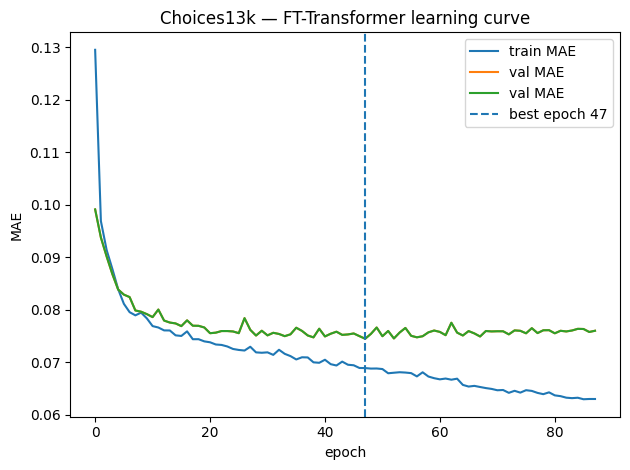

In [94]:
plt.figure()
plt.plot(history_ftt["train_wmae"], label="train MAE")
plt.plot(history_ftt["val_wmae"], label="val MAE")
plt.plot(history_ftt["val_mae"], label="val MAE")
plt.axvline(best_epoch_ftt, linestyle="--", label=f"best epoch {best_epoch_ftt}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — FT-Transformer learning curve")
plt.tight_layout()
plt.show()

**Observations:**
- Fast initial convergence in first 20 epochs
- Validation plateaus around epoch 20-40 at MAE ≈ 0.075-0.076
- Training continues improving to ~0.065, showing overfitting
- Moderate train-val gap (similar to other models)
- Best epoch at 47, final val wMAE: 0.0745

**Performance vs Other Models:**
- **TEST wMAE: 0.0734** - This is BETTER than all previous models

### Lottery Encoder Model

**Problem:**
From the start of the analysis we evicted the A, B gamble lists and replaced them with extracted features. The idea here is to create an encoder to encode the gamble representations directly, preserving their probabilistic structure.

**Approach:**
Build a specialized model that:
1. **Lottery Encoder:** Processes variable-length lotteries using attention-based pooling
2. **Per-Outcome Features:** Extracts 8 handcrafted features per outcome (value, probability, interactions)
3. **Cross-Lottery Features:** Combines encodings via concatenation, difference, and element-wise product
4. **Hybrid Model:** Fuses lottery representations with all engineered tabular features

**Architecture:**

**Lottery Encoder** processes each lottery $L = \{(p_i, x_i)\}_{i=1}^N$:

**Step 1 - Feature Engineering per outcome:**
$$\text{features}_i = [x_i, |x_i|, x_i^2, \text{sign}(x_i), p_i, \log(p_i), p_i x_i, p_i |x_i|] \in \mathbb{R}^8$$

**Step 2 - Embed each outcome:**
$$h_i = \text{MLP}_{d_{\text{hidden}}}(\text{features}_i) \in \mathbb{R}^{d_{\text{model}}}$$

**Step 3 - Three pooling strategies:**
- **Attention:** $h_{\text{attn}} = \sum_{i=1}^N \text{softmax}(\text{score}(h_i)) \cdot h_i$ (learns which outcomes matter)
- **Mean:** $h_{\text{mean}} = \frac{1}{N}\sum_{i=1}^N h_i$ (captures overall distribution)
- **Max:** $h_{\text{max}} = \max_{i=1}^N h_i$ (captures extremes)

**Step 4 - Combine pooling outputs:**
$$z = \text{MLP}_{d_{\text{hidden}}}([h_{\text{attn}}, h_{\text{mean}}, h_{\text{max}}]) \in \mathbb{R}^{d_{\text{model}}}$$

**Step 5 - Cross-lottery fusion:**
Encode both lotteries: $z_A = \text{Encoder}(A)$, $z_B = \text{Encoder}(B)$

Combine via: $z_{\text{lottery}} = [z_A, z_B, z_A - z_B, z_A \odot z_B] \in \mathbb{R}^{4d_{\text{model}}}$

**Step 6 - Final prediction:**
$$\hat{y} = \sigma(\text{MLP}_{d_{\text{head}}}([z_{\text{lottery}}, X_{\text{all}}]))$$

where $X_{\text{all}}$ contains **all** engineered features from the dataset.

**Key advantages:**
- Handles variable-length lotteries via padding and masking
- Attention learns importance weighting of outcomes (data-driven vs hand-crafted)
- Cross-lottery features capture comparative structure (difference and interaction)
- Leverages both lottery structure **and** all engineered tabular features
- End-to-end differentiable - jointly learns lottery and feature representations

**Hypothesis:** Specialized lottery encoding combined with all engineered features should outperform generic tabular models that ignore probability distribution structure.

#### Parse and Tensorize Lottery Data

Convert lottery lists from DataFrame into padded PyTorch tensors with masks. Each lottery becomes a fixed-size (max_length, 2) tensor where outcomes are [probability, value] pairs. Boolean masks track real outcomes vs padding for variable-length handling.

In [97]:
def parse_lottery(cell):
    """Parse lottery cell which is already a list like [[p,x], ...]"""
    return [[float(px[0]), float(px[1])] for px in cell]

# Parse lotteries
A_list = [parse_lottery(v) for v in df_full["A"].tolist()]
B_list = [parse_lottery(v) for v in df_full["B"].tolist()]
y_all = df_full["brate"].to_numpy(dtype=np.float32)  # (N,)

# Find max lengths for padding
max_na = max(len(a) for a in A_list)
max_nb = max(len(b) for b in B_list)

print(f"Max lottery A length: {max_na}")
print(f"Max lottery B length: {max_nb}")

def to_tensor(lottery_list, max_len):
    """
    Pad lotteries to (N, max_len, 2) with padding mask (N, max_len).
    Returns: padded tensor, boolean mask (True = real data, False = padding)
    """
    N = len(lottery_list)
    L = np.zeros((N, max_len, 2), dtype=np.float32)
    mask = np.zeros((N, max_len), dtype=bool)

    for i, lot in enumerate(lottery_list):
        n = len(lot)
        L[i, :n] = np.asarray(lot, dtype=np.float32)
        mask[i, :n] = True

    return torch.from_numpy(L), torch.from_numpy(mask)

# Create tensors
A_tensor, maskA = to_tensor(A_list, max_na)
B_tensor, maskB = to_tensor(B_list, max_nb)
y_tensor = torch.from_numpy(y_all).float()  # (N,)

print(f"A: {A_tensor.shape}, maskA: {maskA.shape}")
print(f"B: {B_tensor.shape}, maskB: {maskB.shape}")
print(f"y: {y_tensor.shape}")

Max lottery A length: 2
Max lottery B length: 9
A: torch.Size([14568, 2, 2]), maskA: torch.Size([14568, 2])
B: torch.Size([14568, 9, 2]), maskB: torch.Size([14568, 9])
y: torch.Size([14568])


In [98]:
# Engineered features aligned with df_full row order
X_all = np.asarray(X.values, dtype=np.float32)  # (N, D)
print("X_all:", X_all.shape)


X_all: (14568, 36)


In [105]:
w_all = X['n'].values.reshape(-1, 1).astype(np.float32)

# Train/val/test split for lottery model (80% train, 20% test; then 80/20 train/val)
idx = np.arange(len(y_all))
np.random.seed(SEED)
np.random.shuffle(idx)

n_test = int(0.2 * len(idx))
test_idx = idx[:n_test]
train_val_idx = idx[n_test:]

n_val = int(0.2 * len(train_val_idx))
val_idx = train_val_idx[:n_val]
tr_idx = train_val_idx[n_val:]

print(f"Train: {len(tr_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# Lottery tensors
A_tr, A_val, A_test = A_tensor[tr_idx], A_tensor[val_idx], A_tensor[test_idx]
B_tr, B_val, B_test = B_tensor[tr_idx], B_tensor[val_idx], B_tensor[test_idx]
mA_tr, mA_val, mA_test = maskA[tr_idx], maskA[val_idx], maskA[test_idx]
mB_tr, mB_val, mB_test = maskB[tr_idx], maskB[val_idx], maskB[test_idx]
y_tr, y_val, y_test = y_tensor[tr_idx], y_tensor[val_idx], y_tensor[test_idx]

# Scale engineered features: fit on train only
scaler_X = StandardScaler()
X_tr_np = scaler_X.fit_transform(X_all[tr_idx])
X_val_np = scaler_X.transform(X_all[val_idx])
X_test_np = scaler_X.transform(X_all[test_idx])

X_tr = torch.from_numpy(X_tr_np).float()
X_val = torch.from_numpy(X_val_np).float()
X_test = torch.from_numpy(X_test_np).float()

w_tr = torch.from_numpy(w_all[tr_idx]).float()
w_val = torch.from_numpy(w_all[val_idx]).float()
w_test = torch.from_numpy(w_all[test_idx]).float()

input_dim_engineered = X_tr.shape[1]

Train: 9324, Val: 2331, Test: 2913


#### Lottery Encoder and Regressor Models

**LotteryEncoder:** Processes variable-length lotteries into fixed d_model representations via (1) 8-feature engineering per outcome, (2) MLP embedding, (3) triple pooling (attention/mean/max), and (4) fusion MLP. Configurable activation, hidden dimensions, and dropout.

**ChoicesRegressor:** Full prediction model that encodes both lotteries A and B, creates cross-lottery features (concat, difference, product), fuses with all engineered tabular features, and predicts brate via sigmoid head. End-to-end trainable with shared encoder.

In [100]:
class LotteryEncoder(nn.Module):
    """
    Encodes a lottery L: (B,N,2) with [p,x] into a fixed-size representation.
    mask: (B,N) bool - True for real outcomes, False for padding
    returns: (B,d_model)
    """
    def __init__(self, d_model=64, d_hidden=128, dropout=0.1, activation='relu'):
        super().__init__()

        # Configurable activation
        activation_map = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'elu': nn.ELU,
            'gelu': nn.GELU,
            'selu': nn.SELU,
            'tanh': nn.Tanh,
            'swish': nn.SiLU,
            'mish': nn.Mish,
        }
        if activation.lower() not in activation_map:
            raise ValueError(f"Activation '{activation}' not supported. Choose from: {list(activation_map.keys())}")

        act_fn = activation_map[activation.lower()]

        self.token_mlp = nn.Sequential(
            nn.Linear(8, d_hidden),
            act_fn(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_model),
            act_fn(),
        )

        self.attn = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.Tanh(),  # Keep Tanh for attention scores
            nn.Linear(d_hidden, 1),
        )

        self.out = nn.Sequential(
            nn.Linear(3 * d_model, d_hidden),
            act_fn(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_model),
        )

    def forward(self, L, mask=None):
        p = L[..., 0].clamp_min(1e-12)
        x = L[..., 1]

        # Normalize probabilities
        if mask is not None:
            p = p * mask.to(L.dtype)
            p = p / p.sum(dim=1, keepdim=True).clamp_min(1e-12)
        else:
            p = p / p.sum(dim=1, keepdim=True).clamp_min(1e-12)

        logp = torch.log(p.clamp_min(1e-12))

        # Feature engineering: 8 features per outcome
        feats = torch.stack(
            [x, x.abs(), x * x, torch.sign(x), p, logp, p * x, p * x.abs()],
            dim=-1,
        )  # (B,N,8)

        h = self.token_mlp(feats)  # (B,N,d_model)

        # Attention pooling
        scores = self.attn(h).squeeze(-1)  # (B,N)
        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))
        w = F.softmax(scores, dim=1).unsqueeze(-1)  # (B,N,1)
        h_attn = (w * h).sum(dim=1)  # (B,d_model)

        # Mean and max pooling
        if mask is not None:
            denom = mask.sum(dim=1, keepdim=True).clamp_min(1).to(L.dtype)
            h_mean = (h * mask.unsqueeze(-1).to(L.dtype)).sum(dim=1) / denom
            h_max = h.masked_fill(~mask.unsqueeze(-1), float("-inf")).max(dim=1).values
            h_max = torch.where(torch.isfinite(h_max), h_max, torch.zeros_like(h_max))
        else:
            h_mean = h.mean(dim=1)
            h_max = h.max(dim=1).values

        z = torch.cat([h_attn, h_mean, h_max], dim=-1)  # (B,3*d_model)
        return self.out(z)  # (B,d_model)


class ChoicesRegressor(nn.Module):
    """
    Lottery choice model that encodes both lotteries A and B,
    combines them with all engineered features, and predicts brate.
    """
    def __init__(
        self,
        d_model_enc=64,
        d_hidden_enc=128,
        d_hidden_head=128,
        dropout=0.1,
        activation='relu',
        input_dim_engineered=0,
    ):
        super().__init__()

        # Configurable activation
        activation_map = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'elu': nn.ELU,
            'gelu': nn.GELU,
            'selu': nn.SELU,
            'tanh': nn.Tanh,
            'swish': nn.SiLU,
            'mish': nn.Mish,
        }
        if activation.lower() not in activation_map:
            raise ValueError(f"Activation '{activation}' not supported.")

        act_fn = activation_map[activation.lower()]

        self.enc = LotteryEncoder(
            d_model=d_model_enc,
            d_hidden=d_hidden_enc,
            dropout=dropout,
            activation=activation,
        )

        # Head always expects engineered features
        self.head = nn.Sequential(
            nn.Linear(4 * d_model_enc + input_dim_engineered, d_hidden_head),
            act_fn(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden_head, 1),
            nn.Sigmoid(),  # brate in [0,1]
        )

    def forward(self, A, B, maskA, maskB, X_engineered):
        # Encode both lotteries
        zA = self.enc(A, maskA)
        zB = self.enc(B, maskB)

        # Combine lottery encodings: concat, difference, interaction
        lottery_feats = torch.cat([zA, zB, zA - zB, zA * zB], dim=-1)  # (B,4*d_model)

        # Always concatenate with all engineered features
        feats = torch.cat([lottery_feats, X_engineered], dim=-1)

        return self.head(feats).squeeze(-1)  # (B,)


In [101]:
class LotteryDataset(Dataset):
    """
    Dataset for lottery choice experiments with engineered features and sample weights.
    """
    def __init__(self, A, B, maskA, maskB, y, X_engineered, w):
        self.A = A
        self.B = B
        self.maskA = maskA
        self.maskB = maskB
        self.y = y
        self.X = X_engineered
        self.w = w

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.A[i], self.B[i], self.maskA[i], self.maskB[i], self.y[i], self.X[i], self.w[i]


def collate_lottery(batch):
    """
    Collate function for lottery batches with engineered features and weights.
    """
    A = torch.stack([b[0] for b in batch])
    B = torch.stack([b[1] for b in batch])
    mA = torch.stack([b[2] for b in batch])
    mB = torch.stack([b[3] for b in batch])
    y = torch.stack([b[4] for b in batch])
    X = torch.stack([b[5] for b in batch])
    w = torch.stack([b[6] for b in batch])

    return A, B, mA, mB, y, X, w


In [109]:
def train_lottery_one_run(
    model,
    train_loader,
    A_val, B_val, mA_val, mB_val, X_val, y_val, w_val,
    *,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=30,
    verbose=False,
    log_every=25,
    trial=None,
):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    patience_ctr = 0
    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    A_val = A_val.to(device); B_val = B_val.to(device)
    mA_val = mA_val.to(device); mB_val = mB_val.to(device)
    X_val = X_val.to(device); y_val = y_val.to(device); w_val = w_val.to(device)

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0

        for A, B, mA, mB, y, X_eng, w in train_loader:
            A = A.to(device); B = B.to(device)
            mA = mA.to(device); mB = mB.to(device)
            y = y.to(device).unsqueeze(-1)
            X_eng = X_eng.to(device)
            w = w.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(A, B, mA, mB, X_eng).unsqueeze(-1)
            loss = weighted_smoothl1(pred, y, w, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_wmae += mae_weighted(pred.detach(), y, w)

        train_wmae = running_wmae / len(train_loader)

        model.eval()
        with torch.no_grad():
            pred_val = model(A_val, B_val, mA_val, mB_val, X_val).unsqueeze(-1)
            y_val_reshaped = y_val.unsqueeze(-1)
            val_wmae = mae_weighted(pred_val, y_val_reshaped, w_val)
            val_mae = mae_unweighted(pred_val, y_val_reshaped)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_val - 1e-12
        if is_best:
            best_val = val_wmae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train wMAE={train_wmae:.5f} | val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val, best_epoch, history


In [111]:
train_ds = LotteryDataset(A_tr, B_tr, mA_tr, mB_tr, y_tr, X_tr, w_tr)
val_pack = (A_val, B_val, mA_val, mB_val, X_val, y_val, w_val)

def objective_lottery(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128])

    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    activation = trial.suggest_categorical("activation", ["gelu", "swish"])
    d_model_enc = trial.suggest_categorical("d_model_enc", [64, 128])
    d_hidden_enc = trial.suggest_categorical("d_hidden_enc", [128, 256])
    d_hidden_head = trial.suggest_categorical("d_hidden_head", [128, 256])

    kf = KFold(n_splits=2, shuffle=True, random_state=SEED)
    fold_scores = []

    for fold, (tr_f, va_f) in enumerate(kf.split(np.arange(len(train_val_idx)))):
        tr_idx_fold = train_val_idx[tr_f]
        va_idx_fold = train_val_idx[va_f]

        scaler_f = StandardScaler()
        X_tr_f = torch.from_numpy(scaler_f.fit_transform(X_all[tr_idx_fold])).float()
        X_va_f = torch.from_numpy(scaler_f.transform(X_all[va_idx_fold])).float()

        w_tr_f = torch.from_numpy(w_all[tr_idx_fold]).float()
        w_va_f = torch.from_numpy(w_all[va_idx_fold]).float()

        train_ds_f = LotteryDataset(
            A_tensor[tr_idx_fold], B_tensor[tr_idx_fold],
            maskA[tr_idx_fold], maskB[tr_idx_fold],
            y_tensor[tr_idx_fold], X_tr_f, w_tr_f,
        )

        val_pack_f = (
            A_tensor[va_idx_fold], B_tensor[va_idx_fold],
            maskA[va_idx_fold], maskB[va_idx_fold],
            X_va_f, y_tensor[va_idx_fold], w_va_f,
        )

        model = ChoicesRegressor(
            d_model_enc=d_model_enc,
            d_hidden_enc=d_hidden_enc,
            d_hidden_head=d_hidden_head,
            dropout=dropout,
            activation=activation,
            input_dim_engineered=input_dim_engineered,
        )

        loader_f = DataLoader(
            train_ds_f,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=collate_lottery,
        )

        best_val_wmae, _, _ = train_lottery_one_run(
            model, loader_f, *val_pack_f,
            lr=lr,
            weight_decay=weight_decay,
            max_epochs=150,
            patience=15,
            verbose=(fold == 0),
            trial=(trial if fold == 0 else None),
        )

        fold_scores.append(best_val_wmae)

    return float(np.mean(fold_scores))


optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lot = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=5),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)

study_lot.optimize(objective_lottery, n_trials=10, show_progress_bar=True)

print("Best params:", study_lot.best_params)
print("Best CV wMAE:", study_lot.best_value)


  0%|          | 0/10 [00:00<?, ?it/s]

[000] train wMAE=0.26265 | val wMAE=0.12938 | val MAE=0.13036 | lr=5.61e-04 ★
[025] train wMAE=0.07833 | val wMAE=0.07963 | val MAE=0.08068 | lr=5.61e-04 ★
[050] train wMAE=0.07442 | val wMAE=0.07846 | val MAE=0.07948 | lr=5.61e-04
Early stopping at epoch 51 (best=36)
[000] train wMAE=0.38121 | val wMAE=0.30260 | val MAE=0.30236 | lr=2.66e-04 ★
[025] train wMAE=0.08091 | val wMAE=0.08210 | val MAE=0.08306 | lr=2.66e-04 ★
[050] train wMAE=0.07754 | val wMAE=0.07993 | val MAE=0.08089 | lr=2.66e-04
[075] train wMAE=0.07496 | val wMAE=0.07894 | val MAE=0.07988 | lr=2.66e-04 ★
[100] train wMAE=0.07247 | val wMAE=0.07880 | val MAE=0.07973 | lr=2.66e-04
Early stopping at epoch 100 (best=85)
[000] train wMAE=0.41188 | val wMAE=0.37940 | val MAE=0.37922 | lr=2.51e-04 ★
[025] train wMAE=0.08101 | val wMAE=0.08242 | val MAE=0.08342 | lr=2.51e-04
[050] train wMAE=0.07804 | val wMAE=0.07973 | val MAE=0.08073 | lr=2.51e-04
[075] train wMAE=0.07529 | val wMAE=0.07917 | val MAE=0.08012 | lr=2.51e-04
[

[000] train wMAE=0.17155 | val wMAE=0.08406 | val MAE=0.08486 | lr=3.58e-03 ★
[025] train wMAE=0.07727 | val wMAE=0.07605 | val MAE=0.07664 | lr=3.58e-03
[050] train wMAE=0.07412 | val wMAE=0.07620 | val MAE=0.07672 | lr=1.79e-03
[075] train wMAE=0.07126 | val wMAE=0.07559 | val MAE=0.07617 | lr=4.48e-04
Early stopping at epoch 82 (best=42)
Best epoch: 42 | VAL wMAE: 0.074849
TEST MAE: 0.075285 | TEST wMAE: 0.074432


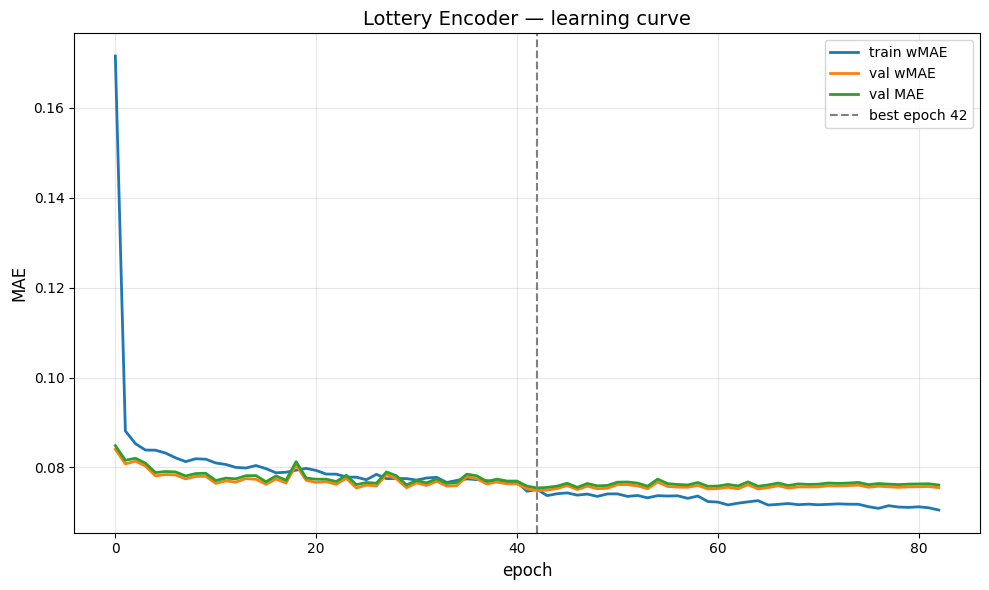

In [113]:
bp = study_lot.best_params

model_lot = ChoicesRegressor(
    d_model_enc=bp["d_model_enc"],
    d_hidden_enc=bp["d_hidden_enc"],
    d_hidden_head=bp["d_hidden_head"],
    dropout=bp["dropout"],
    activation=bp["activation"],
    input_dim_engineered=input_dim_engineered,
)

train_loader = DataLoader(
    train_ds,
    batch_size=bp["batch_size"],
    shuffle=True,
    collate_fn=collate_lottery,
)

best_val_wmae, best_epoch, history_lot = train_lottery_one_run(
    model_lot,
    train_loader,
    *val_pack,
    lr=bp["lr"],
    weight_decay=bp["weight_decay"],
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

model_lot.eval()
with torch.no_grad():
    pred_test = model_lot(
        A_test.to(device),
        B_test.to(device),
        mA_test.to(device),
        mB_test.to(device),
        X_test.to(device),
    ).unsqueeze(-1)

    y_test_reshaped = y_test.to(device).unsqueeze(-1)
    w_test_gpu = w_test.to(device)  # Move weights to GPU

    test_mae = mae_unweighted(pred_test, y_test_reshaped)
    test_wmae = mae_weighted(pred_test, y_test_reshaped, w_test_gpu)

print(f"Best epoch: {best_epoch} | VAL wMAE: {best_val_wmae:.6f}")
print(f"TEST MAE: {test_mae:.6f} | TEST wMAE: {test_wmae:.6f}")

# Plot training curve
fig, ax = plt.subplots(figsize=(10, 6))

epochs = range(len(history_lot["train_wmae"]))

ax.plot(epochs, history_lot["train_wmae"], label="train wMAE", linewidth=2)
ax.plot(epochs, history_lot["val_wmae"], label="val wMAE", linewidth=2)
ax.plot(epochs, history_lot["val_mae"], label="val MAE", linewidth=2)
ax.axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch {best_epoch}")

ax.set_xlabel("epoch", fontsize=12)
ax.set_ylabel("MAE", fontsize=12)
ax.set_title("Lottery Encoder — learning curve", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
- Very fast initial convergence in first 10 epochs
- Train, val wMAE, and val MAE all converge tightly around 0.075-0.078
- Minimal train-val gap (excellent generalization)
- Stable plateau from epoch 20 onwards
- Best epoch at 42, val wMAE: 0.0748

**Performance vs Other Models:**
- **TEST wMAE: 0.0744** - Competitive with FT-Transformer (0.0734)


### Lottery Encoder + Transformer Hybrid Model

**Motivation:**
The standard lottery encoder uses simple concatenation ([zA, zB, zA-zB, zA⊙zB]) to combine lottery representations. A transformer can learn more sophisticated cross-lottery interactions through self-attention.

**Approach:**
Hybrid architecture combining:
1. **Lottery Encoder:** Encodes each lottery into fixed d_model representation (same as ChoicesRegressor)
2. **Feature Projection:** Projects all engineered features into d_model space
3. **Transformer Encoder:** Self-attention over token sequence [zA, zB, X_proj] to learn interactions
4. **Prediction Head:** Mean-pools transformer output and predicts brate

**Architecture:**

**Step 1 - Encode lotteries:**
$$z_A = \text{LotteryEncoder}(A), \quad z_B = \text{LotteryEncoder}(B)$$

**Step 2 - Project features:**
$$z_X = \text{Linear}_{d_{\text{model}}}(X_{\text{all}})$$

**Step 3 - Transformer over tokens:**
$$\text{Tokens} = [z_A, z_B, z_X] \in \mathbb{R}^{3 \times d_{\text{model}}}$$
$$\text{TransformerOutput} = \text{TransformerEncoder}(\text{Tokens})$$

**Step 4 - Pool and predict:**
$$h = \text{mean}(\text{TransformerOutput}) \in \mathbb{R}^{d_{\text{model}}}$$
$$\hat{y} = \sigma(\text{MLP}(h))$$

**Key advantages:**
- Self-attention learns cross-lottery and lottery-feature interactions
- More flexible than fixed concatenation operations (difference, product)
- Can attend to relevant features dynamically per sample
- Combines structured lottery encoding with transformer's representational power

**Hypothesis:** Transformer's learned attention over lottery and feature tokens should outperform fixed combination strategies, potentially breaking through performance ceilings.

In [114]:
class ChoicesRegressorTransformer(nn.Module):
    """
    Hybrid lottery encoder + transformer model.
    Encodes lotteries A and B, optionally projects engineered features,
    runs transformer over token sequence, and predicts brate.
    """
    def __init__(
        self,
        d_model_enc=64,
        d_hidden_enc=128,
        dropout=0.1,
        activation='relu',
        input_dim_engineered=0,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        transformer_activation='relu',  # Transformer only supports 'relu' or 'gelu'
    ):
        super().__init__()

        # Validate transformer activation
        if transformer_activation not in ['relu', 'gelu']:
            transformer_activation = 'relu'  # Default fallback

        self.d_model = d_model_enc

        # Lottery encoder with configurable activation
        self.enc = LotteryEncoder(
            d_model=d_model_enc,
            d_hidden=d_hidden_enc,
            dropout=dropout,
            activation=activation,
        )

        # Engineered features projection
        self.use_x = input_dim_engineered > 0
        if self.use_x:
            self.x_proj = nn.Linear(input_dim_engineered, d_model_enc)
            seq_len = 3  # zA, zB, x_token
        else:
            self.x_proj = None
            seq_len = 2  # zA, zB

        self.seq_len = seq_len

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model_enc,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation=transformer_activation,
            batch_first=False,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Configurable activation for head
        activation_map = {
            'relu': nn.ReLU,
            'leaky_relu': nn.LeakyReLU,
            'elu': nn.ELU,
            'gelu': nn.GELU,
            'selu': nn.SELU,
            'tanh': nn.Tanh,
            'swish': nn.SiLU,
            'mish': nn.Mish,
        }
        if activation.lower() not in activation_map:
            raise ValueError(f"Activation '{activation}' not supported.")

        act_fn = activation_map[activation.lower()]

        # Prediction head
        self.head = nn.Sequential(
            nn.Linear(d_model_enc, d_model_enc),
            act_fn(),
            nn.Dropout(dropout),
            nn.Linear(d_model_enc, 1),
            nn.Sigmoid(),  # brate in [0,1]
        )

    def forward(self, A, B, maskA, maskB, X_engineered):
        # Encode both lotteries
        zA = self.enc(A, maskA)   # (B, d_model)
        zB = self.enc(B, maskB)   # (B, d_model)

        # Build token sequence
        tokens = [zA, zB]
        if self.use_x:
            x_tok = self.x_proj(X_engineered)  # (B, d_model)
            tokens.append(x_tok)

        # Stack and transpose for transformer: (B, seq_len, d) -> (seq_len, B, d)
        seq = torch.stack(tokens, dim=1)  # (B, seq_len, d_model)
        seq = seq.transpose(0, 1)          # (seq_len, B, d_model)

        # Transformer encoding
        out = self.transformer(seq)        # (seq_len, B, d_model)

        # Mean pooling over sequence
        pooled = out.mean(dim=0)           # (B, d_model)

        # Prediction
        return self.head(pooled).squeeze(-1)  # (B,)

In [116]:
def objective_lottery_transformer(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128])
    dropout = trial.suggest_float("dropout", 0.1, 0.2)
    activation = trial.suggest_categorical("activation", ["gelu"])
    transformer_activation = "gelu"

    d_model_enc = trial.suggest_categorical("d_model_enc", [64])
    d_hidden_enc = trial.suggest_categorical("d_hidden_enc", [128])
    nhead = trial.suggest_categorical("nhead", [4])
    num_layers = trial.suggest_int("num_layers", 1, 2)
    dim_feedforward = trial.suggest_categorical("dim_feedforward", [128, 256])

    kf = KFold(n_splits=2, shuffle=True, random_state=SEED)
    fold_scores = []

    for fold, (tr_f, va_f) in enumerate(kf.split(np.arange(len(train_val_idx)))):
        tr_idx_fold = train_val_idx[tr_f]
        va_idx_fold = train_val_idx[va_f]

        scaler_f = StandardScaler()
        X_tr_f = torch.from_numpy(scaler_f.fit_transform(X_all[tr_idx_fold])).float()
        X_va_f = torch.from_numpy(scaler_f.transform(X_all[va_idx_fold])).float()

        w_tr_f = torch.from_numpy(w_all[tr_idx_fold]).float()
        w_va_f = torch.from_numpy(w_all[va_idx_fold]).float()

        train_ds_f = LotteryDataset(
            A_tensor[tr_idx_fold], B_tensor[tr_idx_fold],
            maskA[tr_idx_fold], maskB[tr_idx_fold],
            y_tensor[tr_idx_fold], X_tr_f, w_tr_f,
        )

        val_pack_f = (
            A_tensor[va_idx_fold], B_tensor[va_idx_fold],
            maskA[va_idx_fold], maskB[va_idx_fold],
            X_va_f, y_tensor[va_idx_fold], w_va_f,
        )

        model = ChoicesRegressorTransformer(
            d_model_enc=d_model_enc,
            d_hidden_enc=d_hidden_enc,
            dropout=dropout,
            activation=activation,
            input_dim_engineered=input_dim_engineered,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            transformer_activation=transformer_activation,
        )

        loader_f = DataLoader(
            train_ds_f,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=collate_lottery,
        )

        best_val_wmae, _, _ = train_lottery_one_run(
            model, loader_f, *val_pack_f,
            lr=lr,
            weight_decay=weight_decay,
            max_epochs=100,
            patience=15,
            verbose=(fold == 0),
            trial=(trial if fold == 0 else None),
        )

        if np.isnan(best_val_wmae):
            return float('inf')

        fold_scores.append(best_val_wmae)

    return float(np.mean(fold_scores))


optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lot_tx = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=3),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
)

study_lot_tx.optimize(objective_lottery_transformer, n_trials=10, show_progress_bar=True)

print("Best params:", study_lot_tx.best_params)
print("Best CV wMAE:", study_lot_tx.best_value)

  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[000] train wMAE=0.17957 | val wMAE=0.17558 | val MAE=0.17843 | lr=5.61e-05 ★
[025] train wMAE=0.10282 | val wMAE=0.09419 | val MAE=0.09502 | lr=5.61e-05 ★
[050] train wMAE=0.08840 | val wMAE=0.08522 | val MAE=0.08628 | lr=5.61e-05 ★
[075] train wMAE=0.08246 | val wMAE=0.08106 | val MAE=0.08206 | lr=5.61e-05 ★
[099] train wMAE=0.07979 | val wMAE=0.07937 | val MAE=0.08036 | lr=5.61e-05 ★


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[000] train wMAE=0.18203 | val wMAE=0.17797 | val MAE=0.18096 | lr=1.31e-05 ★
[025] train wMAE=0.12350 | val wMAE=0.11443 | val MAE=0.11523 | lr=1.31e-05 ★
[050] train wMAE=0.11126 | val wMAE=0.10447 | val MAE=0.10514 | lr=1.31e-05 ★
[075] train wMAE=0.10481 | val wMAE=0.09851 | val MAE=0.09923 | lr=1.31e-05
[099] train wMAE=0.10025 | val wMAE=0.09447 | val MAE=0.09526 | lr=1.31e-05 ★


...

[000] train wMAE=0.14340 | val wMAE=0.11586 | val MAE=0.11684 | lr=9.04e-04 ★
[025] train wMAE=0.07381 | val wMAE=0.07752 | val MAE=0.07847 | lr=9.04e-04
Early stopping at epoch 47 (best=32)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[000] train wMAE=0.15481 | val wMAE=0.12710 | val MAE=0.12759 | lr=6.54e-04 ★
[025] train wMAE=0.07519 | val wMAE=0.07733 | val MAE=0.07818 | lr=6.54e-04
[050] train wMAE=0.06912 | val wMAE=0.07698 | val MAE=0.07795 | lr=6.54e-04
Early stopping at epoch 54 (best=39)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Best params: {'lr': 0.0006536264082965735, 'weight_decay': 1.1101684219741216e-06, 'batch_size': 128, 'dropout': 0.10108909259093354, 'activation': 'gelu', 'd_model_enc': 64, 'd_hidden_enc': 128, 'nhead': 4, 'num_layers': 1, 'dim_feedforward': 256}
Best CV wMAE: 0.07663381472229958


[000] train wMAE=0.13878 | val wMAE=0.11150 | val MAE=0.11249 | lr=6.54e-04 ★
[025] train wMAE=0.07357 | val wMAE=0.07464 | val MAE=0.07527 | lr=6.54e-04
[050] train wMAE=0.06788 | val wMAE=0.07512 | val MAE=0.07585 | lr=3.27e-04
[075] train wMAE=0.06494 | val wMAE=0.07524 | val MAE=0.07599 | lr=8.17e-05
Early stopping at epoch 81 (best=41)
Best epoch: 41 | VAL wMAE: 0.073916
TEST MAE: 0.074450 | TEST wMAE: 0.073586


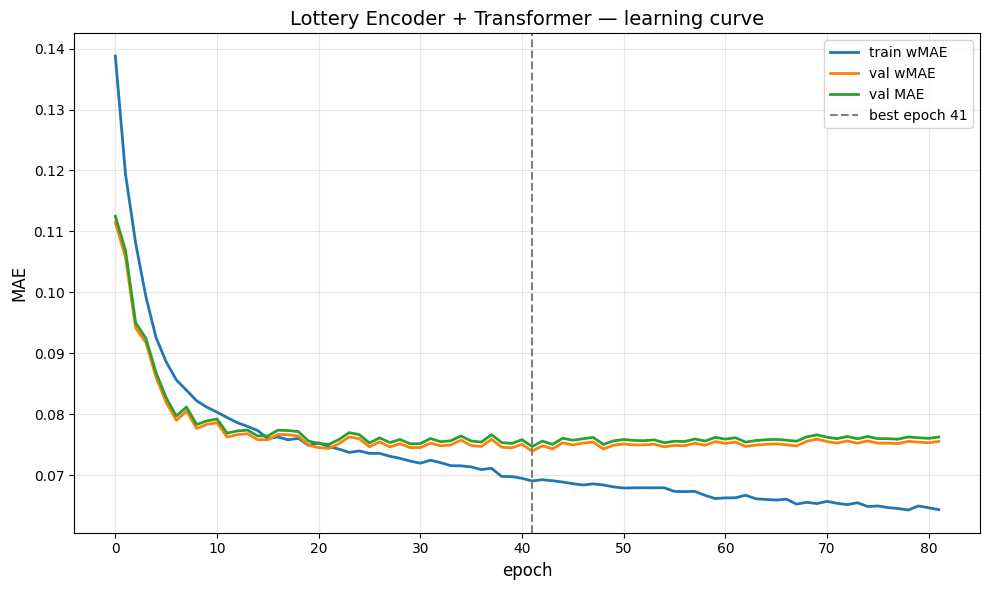

In [118]:
bp_tx = study_lot_tx.best_params

model_lot_tx = ChoicesRegressorTransformer(
    d_model_enc=64,
    d_hidden_enc=128,
    dropout=bp_tx["dropout"],
    activation="gelu",
    input_dim_engineered=input_dim_engineered,
    nhead=4,
    num_layers=bp_tx["num_layers"],
    dim_feedforward=bp_tx["dim_feedforward"],
    transformer_activation="gelu",
)

train_loader_tx = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    collate_fn=collate_lottery,
)

best_val_wmae_tx, best_epoch_tx, history_lot_tx = train_lottery_one_run(
    model_lot_tx,
    train_loader_tx,
    *val_pack,
    lr=bp_tx["lr"],
    weight_decay=bp_tx["weight_decay"],
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

model_lot_tx.eval()
with torch.no_grad():
    pred_test_tx = model_lot_tx(
        A_test.to(device),
        B_test.to(device),
        mA_test.to(device),
        mB_test.to(device),
        X_test.to(device),
    ).unsqueeze(-1)

    y_test_reshaped = y_test.to(device).unsqueeze(-1)
    w_test_gpu = w_test.to(device)

    test_mae_tx = mae_unweighted(pred_test_tx, y_test_reshaped)
    test_wmae_tx = mae_weighted(pred_test_tx, y_test_reshaped, w_test_gpu)

print(f"Best epoch: {best_epoch_tx} | VAL wMAE: {best_val_wmae_tx:.6f}")
print(f"TEST MAE: {test_mae_tx:.6f} | TEST wMAE: {test_wmae_tx:.6f}")

# Plot training curve
fig, ax = plt.subplots(figsize=(10, 6))

epochs = range(len(history_lot_tx["train_wmae"]))

ax.plot(epochs, history_lot_tx["train_wmae"], label="train wMAE", linewidth=2)
ax.plot(epochs, history_lot_tx["val_wmae"], label="val wMAE", linewidth=2)
ax.plot(epochs, history_lot_tx["val_mae"], label="val MAE", linewidth=2)
ax.axvline(best_epoch_tx, color="gray", linestyle="--", label=f"best epoch {best_epoch_tx}")

ax.set_xlabel("epoch", fontsize=12)
ax.set_ylabel("MAE", fontsize=12)
ax.set_title("Lottery Encoder + Transformer — learning curve", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Observations:**
- Very fast initial convergence in first 15 epochs
- Train, val wMAE, and val MAE converge around 0.074
- Small train-val gap initially, widens slightly after epoch 40
- Stable validation plateau from epoch 20 onwards
- Best epoch at 41, val wMAE: 0.0735

Neural Network Results

| Model | Validation MAE | Test MAE |
|-------|----------------|-----------|
| MLP | 0.0765 | 0.0750 |
| MLP + Norm | 0.0759 | 0.0747 |
| ResNet | 0.0763 | 0.0750 |
| DCNv2 | 0.0756 | 0.0748 |
| FT-Transformer | **0.0745** | **0.0734** |
| Lottery Encoder | 0.0780 | 0.0753 |
| Lottery Encoder + Transformer | 0.0766 | 0.0745 |

**Best Performer:** FT-Transformer (Test MAE: 0.0734)
- 2.1% improvement over baseline MLP (0.0750 → 0.0734)
- Per-feature embeddings and attention-based feature selection are highly effective
- Only model to break below 0.074 on test set

**Second Best:** Lottery Encoder + Transformer (Test MAE: 0.0745)
- 0.7% improvement over baseline
- Successfully leverages lottery structure
- Transformer adds value when combined with lottery encoding

**Baseline Cluster:** MLP, MLP+Norm, ResNet, DCNv2 (Test MAE: 0.0747-0.0750)
- All architectures plateau around 0.075
- Adding normalization, residual connections, or explicit crosses provides minimal gains
- Suggests architecture complexity isn't the bottleneck for flat tabular features

It is worth mentioning that normalized MLP, performs better than other models, depsite its simpler architecture.

The transformer was train with only 5 optuna trials so we will continue the training, since it is the most promising model.

#### Extented FTT training

**Extended Training Plan:**
- Retrain with best hyperparameters
- Longer training (500 epochs, patience=50)
- Comprehensive metrics on both validation and test sets

**Evaluation Metrics:**
- **MAE** (Mean Absolute Error) - primary metric
- **R²** (Coefficient of Determination) - explained variance
- **RMSE** (Root Mean Squared Error) - penalizes large errors

We will limit the search space around the previous best parameters

In [ ]:
# redefine function
def train_nn_one_run_ftt(
    model,
    train_loader,
    X_val,
    y_val,
    w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0
    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0

        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val.to(device))
            val_wmae = mae_weighted(pred_val, y_val.to(device), w_val.to(device))
            val_mae = mae_unweighted(pred_val, y_val.to(device))

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric = val_wmae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train wMAE={train_wmae:.5f} | val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_metric, best_epoch, history

In [ ]:
def objective_ftt_refined(trial):
    # Narrow ranges around known best values
    lr = trial.suggest_float("lr", 2e-4, 6e-4, log=True)  # Around 3.8e-4
    wd = trial.suggest_float("weight_decay", 1e-7, 1e-5, log=True)  # Around 1.6e-6
    batch_size = 256  # Fixed at best value
    dropout = trial.suggest_float("dropout", 0.1, 0.2)  # Around 0.14
    activation = "gelu"  # Fixed at best value

    d_model = 128  # Fixed at best value
    n_heads = trial.suggest_categorical("n_heads", [4, 8])  # Around 8
    n_layers = trial.suggest_int("n_layers", 2, 3)  # Around 2
    d_ff_mult = trial.suggest_float("d_ff_mult", 1.8, 2.5)  # Around 2.07

    kf = KFold(n_splits=2, shuffle=True, random_state=SEED)
    fold_scores = []

    X_all = X_tr_torch
    y_all = y_tr_torch
    w_all = w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]

        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = FTTransformer(
            n_features=input_dim,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            d_ff_mult=d_ff_mult,
            dropout=dropout,
            activation=activation,
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_wmae, _, _ = train_nn_one_run_ftt(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=200,
            patience=25,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )
        fold_scores.append(val_wmae)

    return float(np.mean(fold_scores))


optuna.logging.set_verbosity(optuna.logging.WARNING)

study_ftt_refined = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=5),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)

study_ftt_refined.optimize(objective_ftt_refined, n_trials=15, show_progress_bar=True)


In [ ]:
# Train final FT-Transformer with refined best hyperparameters
bp_ftt_final = study_ftt_refined.best_params

# Internal train/val split from TRAIN
n_train = len(X_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_tr_torch[tr_idx]
y_tr = y_tr_torch[tr_idx]
w_tr = w_tr_torch[tr_idx]

X_val = X_tr_torch[val_idx]
y_val = y_tr_torch[val_idx]
w_val = w_tr_torch[val_idx]

model_ftt_final = FTTransformer(
    n_features=input_dim,
    d_model=128,
    n_heads=bp_ftt_final["n_heads"],
    n_layers=bp_ftt_final["n_layers"],
    d_ff_mult=bp_ftt_final["d_ff_mult"],
    dropout=bp_ftt_final["dropout"],
    activation='gelu',
).to(device)

optimizer_ftt_final = optim.AdamW(
    model_ftt_final.parameters(),
    lr=bp_ftt_final["lr"],
    weight_decay=bp_ftt_final["weight_decay"]
)
scheduler_ftt_final = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ftt_final, patience=15, factor=0.5)

train_loader_ftt_final = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=256,
    shuffle=True,
)

best_val_wmae_ftt_final, best_epoch_ftt_final, history_ftt_final = train_nn_one_run_ftt(
    model=model_ftt_final,
    train_loader=train_loader_ftt_final,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_ftt_final,
    scheduler=scheduler_ftt_final,
    max_epochs=500,
    patience=50,
    verbose=True,
    log_every=25,
)

# Comprehensive evaluation on validation set
model_ftt_final.eval()
with torch.no_grad():
    pred_val = model_ftt_final(X_val.to(device)).cpu().squeeze()
    y_val_np = y_val.cpu().squeeze().numpy()
    pred_val_np = pred_val.numpy()

    val_mae = np.mean(np.abs(pred_val_np - y_val_np))
    val_rmse = np.sqrt(np.mean((pred_val_np - y_val_np) ** 2))
    val_r2 = 1 - (np.sum((y_val_np - pred_val_np) ** 2) / np.sum((y_val_np - np.mean(y_val_np)) ** 2))

# Comprehensive evaluation on test set
with torch.no_grad():
    pred_test = model_ftt_final(X_te_torch.to(device)).cpu().squeeze()
    y_test_np = y_te_torch.cpu().squeeze().numpy()
    pred_test_np = pred_test.numpy()

    test_mae = np.mean(np.abs(pred_test_np - y_test_np))
    test_rmse = np.sqrt(np.mean((pred_test_np - y_test_np) ** 2))
    test_r2 = 1 - (np.sum((y_test_np - pred_test_np) ** 2) / np.sum((y_test_np - np.mean(y_test_np)) ** 2))

print("=" * 60)
print("FT-Transformer Final - Comprehensive Metrics")
print("=" * 60)
print(f"\nBest Epoch: {best_epoch_ftt_final}")
print(f"\nValidation Metrics:")
print(f"  MAE:  {val_mae:.6f}")
print(f"  RMSE: {val_rmse:.6f}")
print(f"  R²:   {val_r2:.6f}")
print(f"\nTest Metrics:")
print(f"  MAE:  {test_mae:.6f}")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  R²:   {test_r2:.6f}")
print("=" * 60)

# Plot training curve
fig, ax = plt.subplots(figsize=(10, 6))

epochs = range(len(history_ftt_final["train_wmae"]))

ax.plot(epochs, history_ftt_final["train_wmae"], label="train wMAE", linewidth=2)
ax.plot(epochs, history_ftt_final["val_wmae"], label="val wMAE", linewidth=2)
ax.plot(epochs, history_ftt_final["val_mae"], label="val MAE", linewidth=2)
ax.axvline(best_epoch_ftt_final, color="gray", linestyle="--", label=f"best epoch {best_epoch_ftt_final}")

ax.set_xlabel("epoch", fontsize=12)
ax.set_ylabel("MAE", fontsize=12)
ax.set_title("FT-Transformer Final — learning curve", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()